In [1]:
import json
import math
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from datetime import datetime, timezone
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (roc_auc_score, classification_report, 
confusion_matrix, roc_curve, precision_score, recall_score, accuracy_score,
average_precision_score, balanced_accuracy_score, brier_score_loss, f1_score, precision_recall_curve)
from sklearn.model_selection import (train_test_split, cross_validate, GridSearchCV, GroupKFold, StratifiedKFold, cross_val_predict)

# Heart Disease Prediction: Multi-Dataset Risk Classification

In this notebook, we use multiple UCI heart disease datasets (Cleveland, Hungarian, Switzerland, and VA) to predict the presence of heart disease. This is a supervised binary classification task, where the target variable is derived from "num" and indicates whether heart disease is present (num > 0) or absent.

In [2]:
# loader function

def load_heart_data(file_path):
    cols = [
        "age", "sex", "cp", "trestbps", "chol", "fbs",
        "restecg", "thalach", "exang", "oldpeak",
        "slope", "ca", "thal", "num"
    ]
    
    df = pd.read_csv(
        file_path,
        names=cols,
        na_values="?"
    )
    
    return df

In [3]:
df_cleveland = load_heart_data("uci/processed.cleveland.data")
df_hungarian = load_heart_data("uci/processed.hungarian.data")
df_switzerland = load_heart_data("uci/processed.switzerland.data")
df_va = load_heart_data("uci/processed.va.data")

In [4]:
def summarize_dataset(df, name):
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nTarget distribution:")
    print((df["num"] > 0).value_counts(normalize=True))

summarize_dataset(df_cleveland, "Cleveland")
summarize_dataset(df_hungarian, "Hungarian")
summarize_dataset(df_switzerland, "Switzerland")
summarize_dataset(df_va, "VA")


===== Cleveland =====
Shape: (303, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Target distribution:
num
False    0.541254
True     0.458746
Name: proportion, dtype: float64

===== Hungarian =====
Shape: (294, 14)

Missing values:
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

Target distribution:
num
False    0.639456
True     0.360544
Name: proportion, dtype: float64

===== Switzerland =====
Shape: (123, 14)

Missing values:
age           0
sex           0
cp            0
trestbps      2
chol          0
fbs          75
restecg       1
thalach       1
exang         1
oldpeak       6
slope        17
ca          118

# EDA

## Dataset Overview and Target Distribution

In [5]:
# Dataset size comparison

summary = pd.DataFrame({
    "Dataset": ["Cleveland", "Hungarian", "Switzerland", "VA"],
    "Rows": [
        df_cleveland.shape[0],
        df_hungarian.shape[0],
        df_switzerland.shape[0],
        df_va.shape[0]
    ],
    "Columns": [
        df_cleveland.shape[1],
        df_hungarian.shape[1],
        df_switzerland.shape[1],
        df_va.shape[1]
    ]
})

summary

,Dataset,Rows,Columns
0,Cleveland,303,14
1,Hungarian,294,14
2,Switzerland,123,14
3,VA,200,14


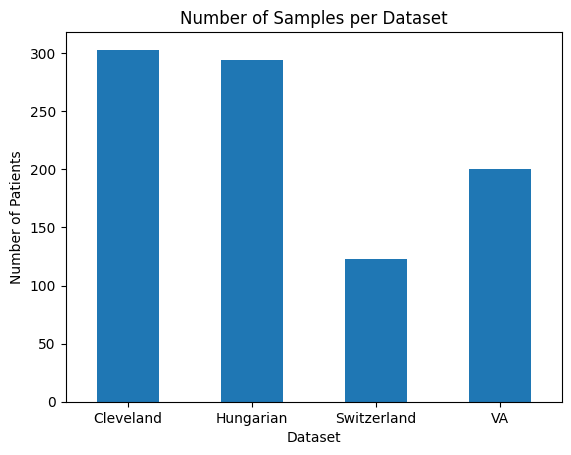

In [6]:
summary.set_index("Dataset")["Rows"].plot(kind="bar")
plt.title("Number of Samples per Dataset")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.savefig("uci_plots/eda_number_of_samples_per_dataset.png", bbox_inches="tight")
plt.show()

In [7]:
# Target Variable Distribution

def get_target_distribution(df):
    return (df["num"] > 0).value_counts(normalize=True)

target_summary = pd.DataFrame({
    "Cleveland": get_target_distribution(df_cleveland),
    "Hungarian": get_target_distribution(df_hungarian),
    "Switzerland": get_target_distribution(df_switzerland),
    "VA": get_target_distribution(df_va)
}).T

target_summary.columns = ["No Disease", "Disease"]
target_summary

,No Disease,Disease
Cleveland,0.541254,0.458746
Hungarian,0.639456,0.360544
Switzerland,0.065041,0.934959
VA,0.255000,0.745000


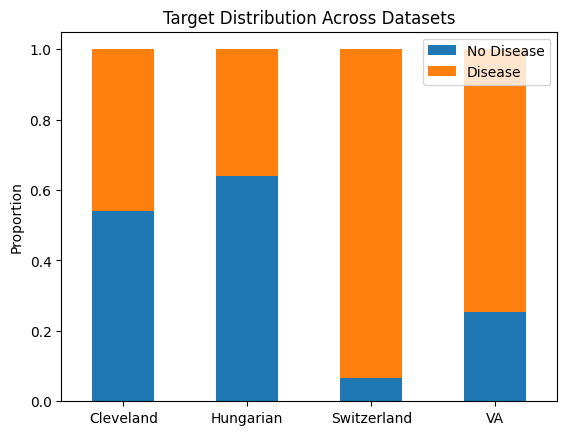

In [8]:
target_summary.plot(kind="bar", stacked=True)
plt.title("Target Distribution Across Datasets")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.savefig("uci_plots/eda_target_distribution_across_datasets.png", bbox_inches="tight")
plt.show()

### Dataset Overview and Target Distribution Summary

The four UCI heart disease datasets differ substantially in both size and class distribution, which has direct implications for model design.

The Cleveland dataset (303 samples) is the most balanced, with approximately 46% positive cases, making it the most suitable candidate for primary model training. The Hungarian dataset (294 samples) exhibits a moderate class imbalance (~36% positive), while the VA dataset (200 samples) is more skewed (~75% positive), and the Switzerland dataset (123 samples) is highly imbalanced (~93% positive).

These discrepancies indicate significant **distribution shifts across datasets**, likely reflecting differences in patient populations or data collection processes. As a result, combining datasets naively for training may lead to biased models or poor generalization.

## Feature Distribution

In [9]:
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

datasets = {
    "Cleveland": df_cleveland,
    "Hungarian": df_hungarian,
    "Switzerland": df_switzerland,
    "VA": df_va
}

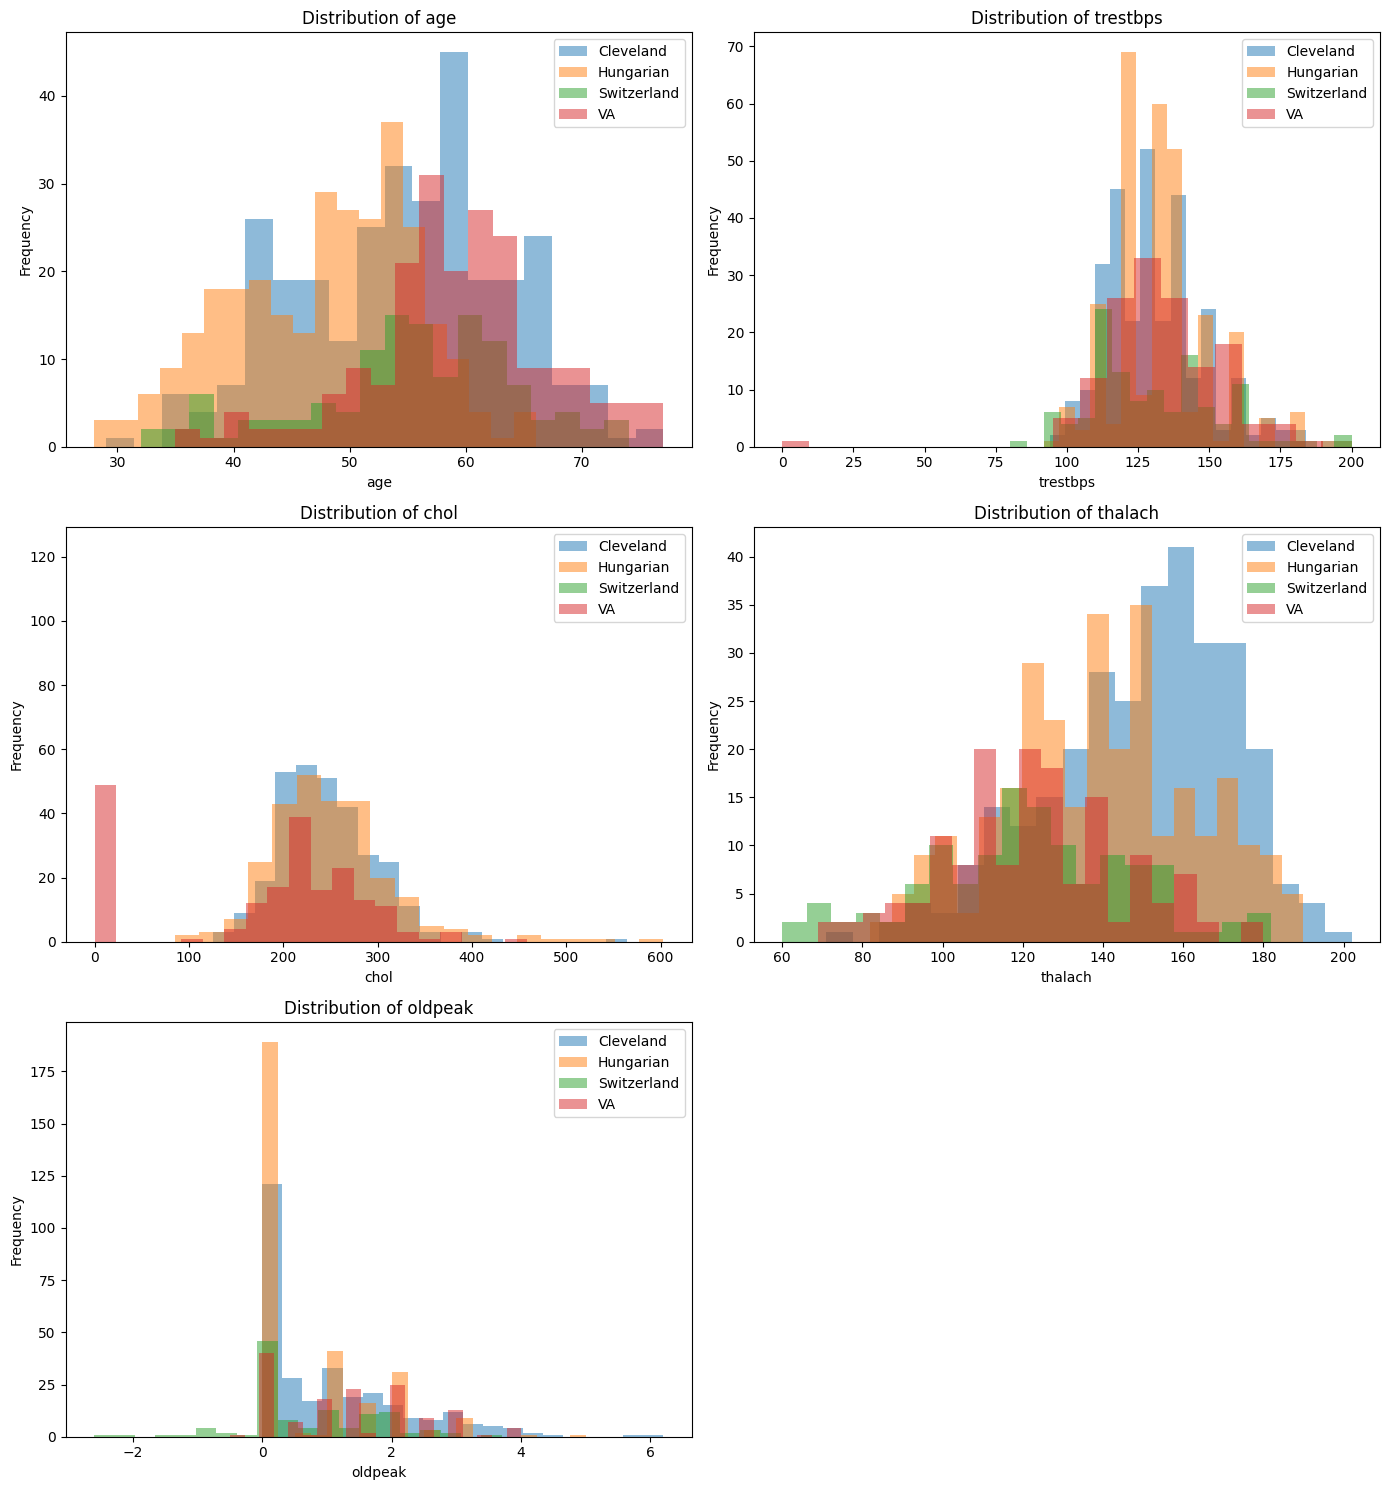

In [10]:
# Numerical Feature Distributions

n_features = 5
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    for name, df in datasets.items():
        axes[i].hist(
            df[feature].dropna(),
            bins=20,
            alpha=0.5,
            label=name
        )
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_numerical_feature_distribution.png", bbox_inches="tight")
plt.show()

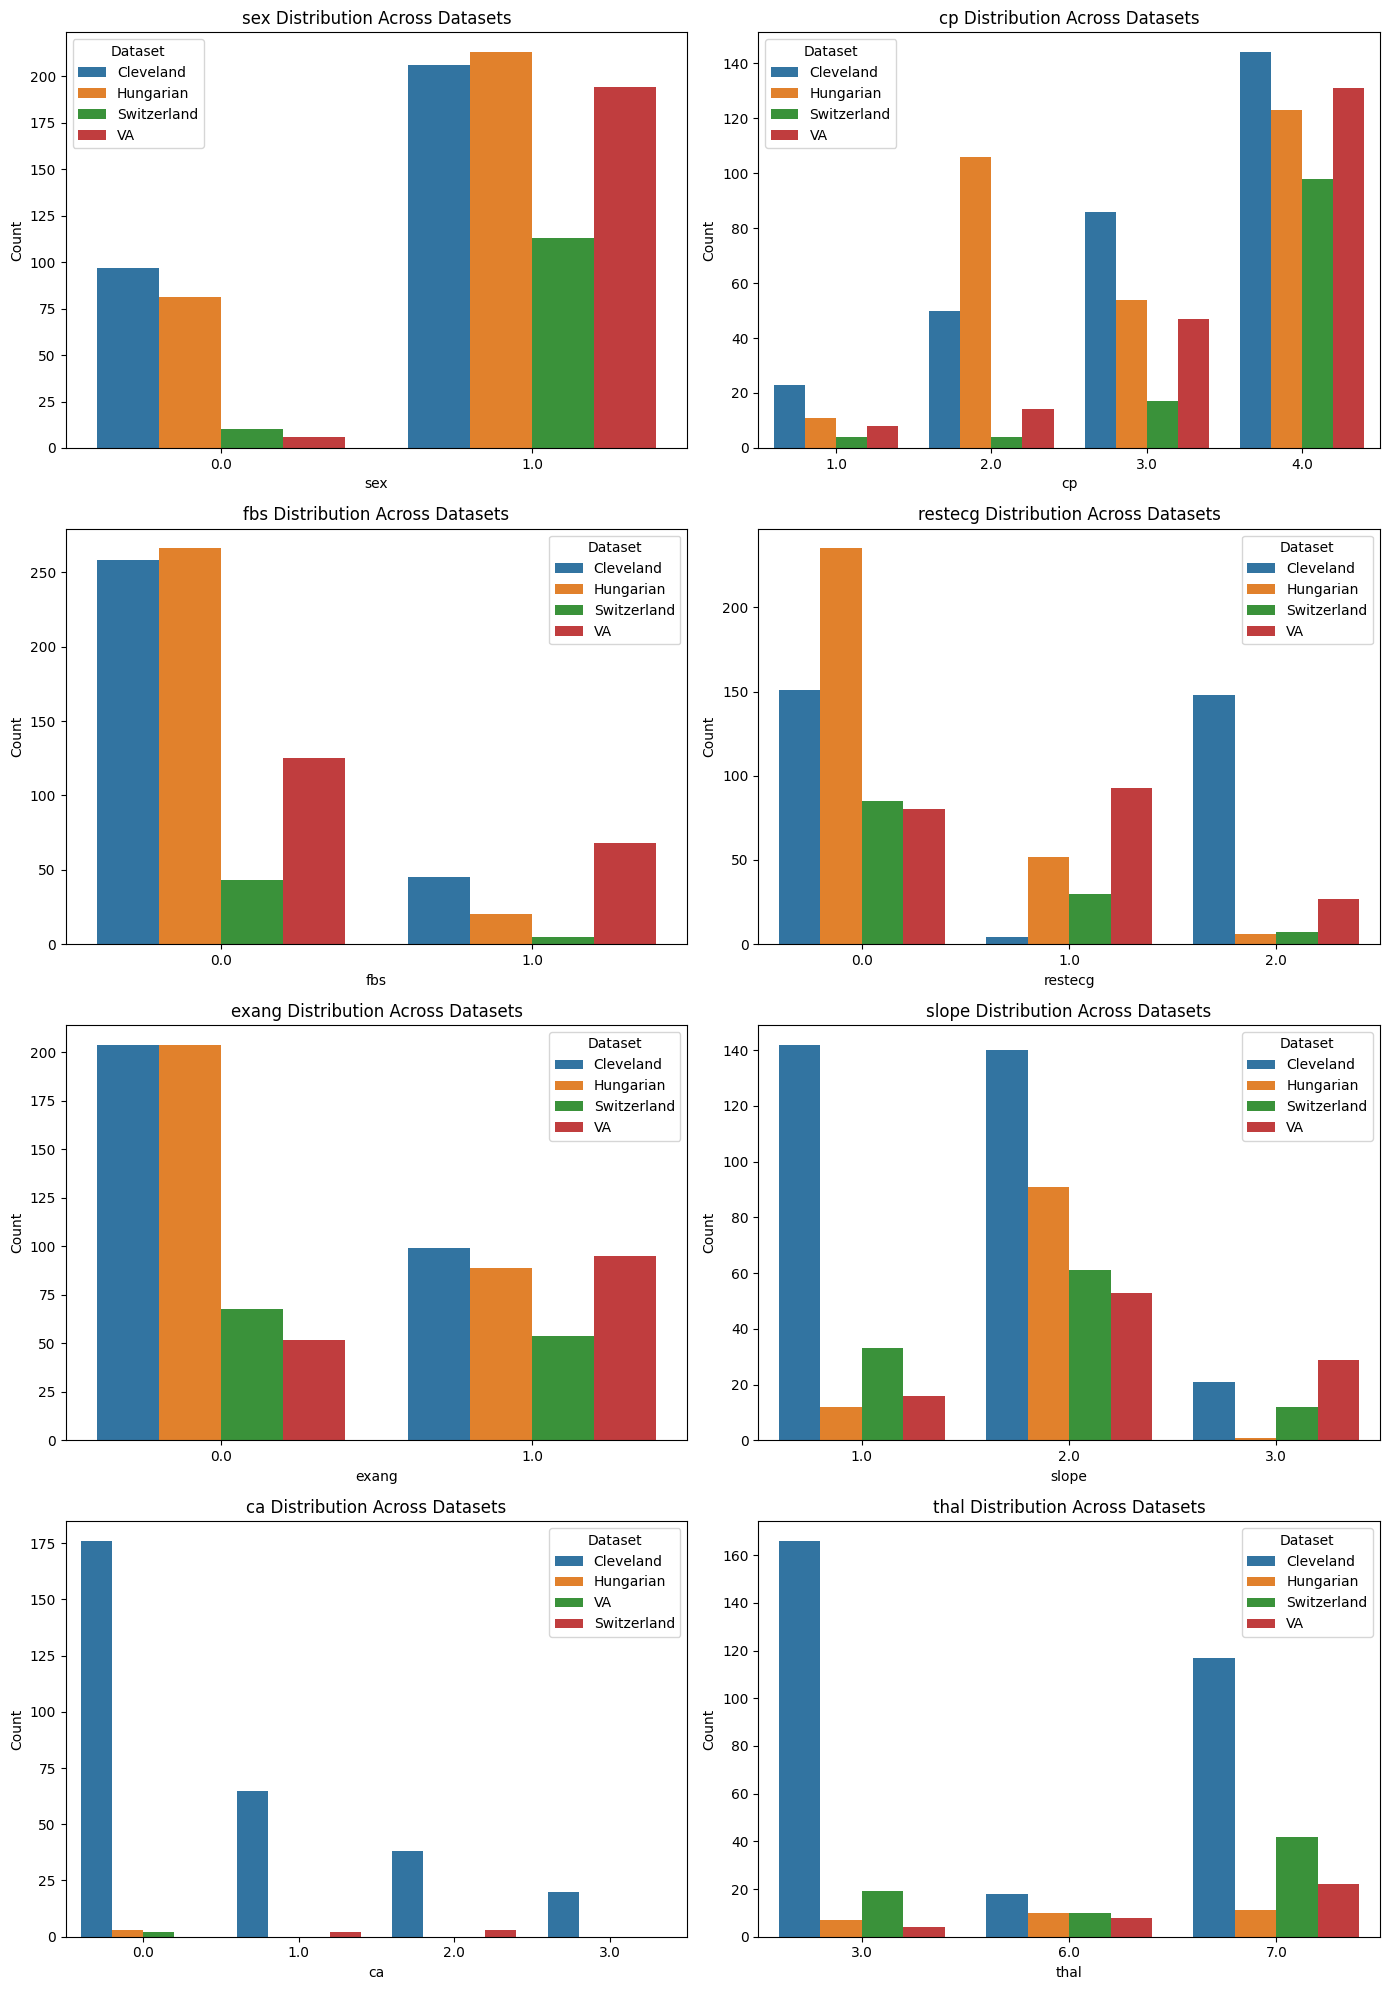

In [11]:
# Categorical Feature Distributions

n_features = len(categorical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    combined = []

    for name, df in datasets.items():
        temp = df[[feature]].copy()
        temp["Dataset"] = name
        combined.append(temp)

    combined_df = pd.concat(combined, ignore_index=True)

    sns.countplot(x=feature, hue="Dataset", data=combined_df, ax=axes[i])
    axes[i].set_title(f"{feature} Distribution Across Datasets")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_categorical_feature_distribution.png", bbox_inches="tight")
plt.show()

### Feature Distributions Summary

The analysis of feature distributions reveals both **consistency and variability across datasets**, with important implications for feature selection and model design.

Several numerical features, such as *age* and *resting blood pressure (trestbps)*, exhibit relatively stable distributions across datasets, making them reliable candidates for all model configurations. In contrast, features like *cholesterol (chol)* show inconsistencies, particularly in the VA dataset where zero values likely indicate missing or improperly encoded data. Additionally, *maximum heart rate (thalach)* and *oldpeak* display noticeable distribution shifts, suggesting potential challenges for cross-dataset generalization.

Among categorical variables, features such as *sex* and *exercise-induced angina (exang)* are relatively consistent, while others like *chest pain type (cp)* vary significantly across datasets, indicating possible population or measurement differences. Importantly, features such as *ca* and *thal* are largely unavailable outside the Cleveland dataset, limiting their use to the full-feature model.

Overall, this analysis highlights two key challenges: **feature availability constraints** and **distributional shifts across datasets**. These findings directly support the design of a tiered modeling approach, where feature sets are adapted based on both data completeness and cross-dataset consistency.

## Cross-Dataset Comparison

In [12]:
# Cross-Dataset Feature Comparison

combined = []

for name, df in datasets.items():
    temp = df.copy()
    temp["Dataset"] = name
    combined.append(temp)

combined_df = pd.concat(combined, ignore_index=True)

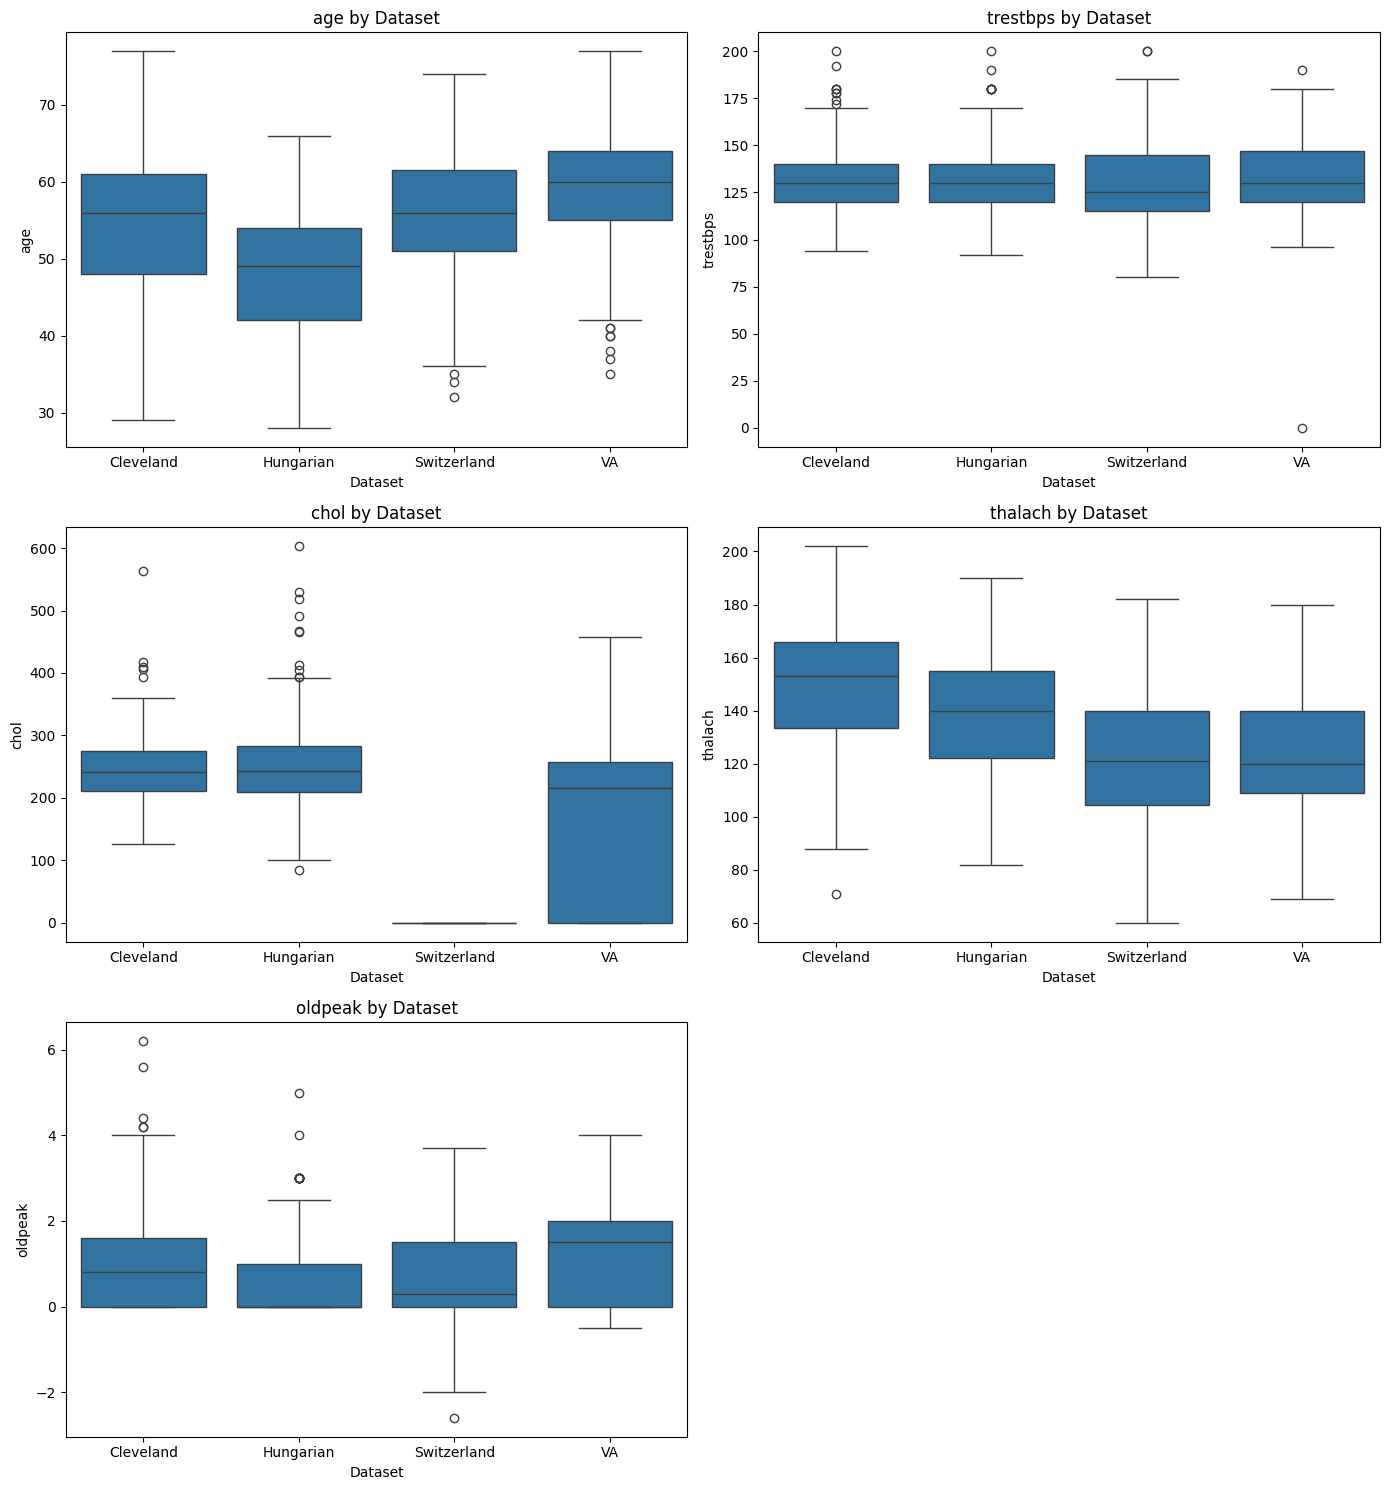

In [13]:
# Numerical Feature Comparison

n_features = len(numerical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x="Dataset", y=feature, data=combined_df, ax=axes[i])
    axes[i].set_title(f"{feature} by Dataset")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_numerical_feature_comparison.png", bbox_inches="tight")
plt.show()

Age and trestbps are relatively consistent across datasets, while thalach shows a clear downward shift outside Cleveland. Cholesterol is highly inconsistent, especially in VA where many zero values indicate data quality issues. Oldpeak shows variability but retains a general trend of higher values in VA.

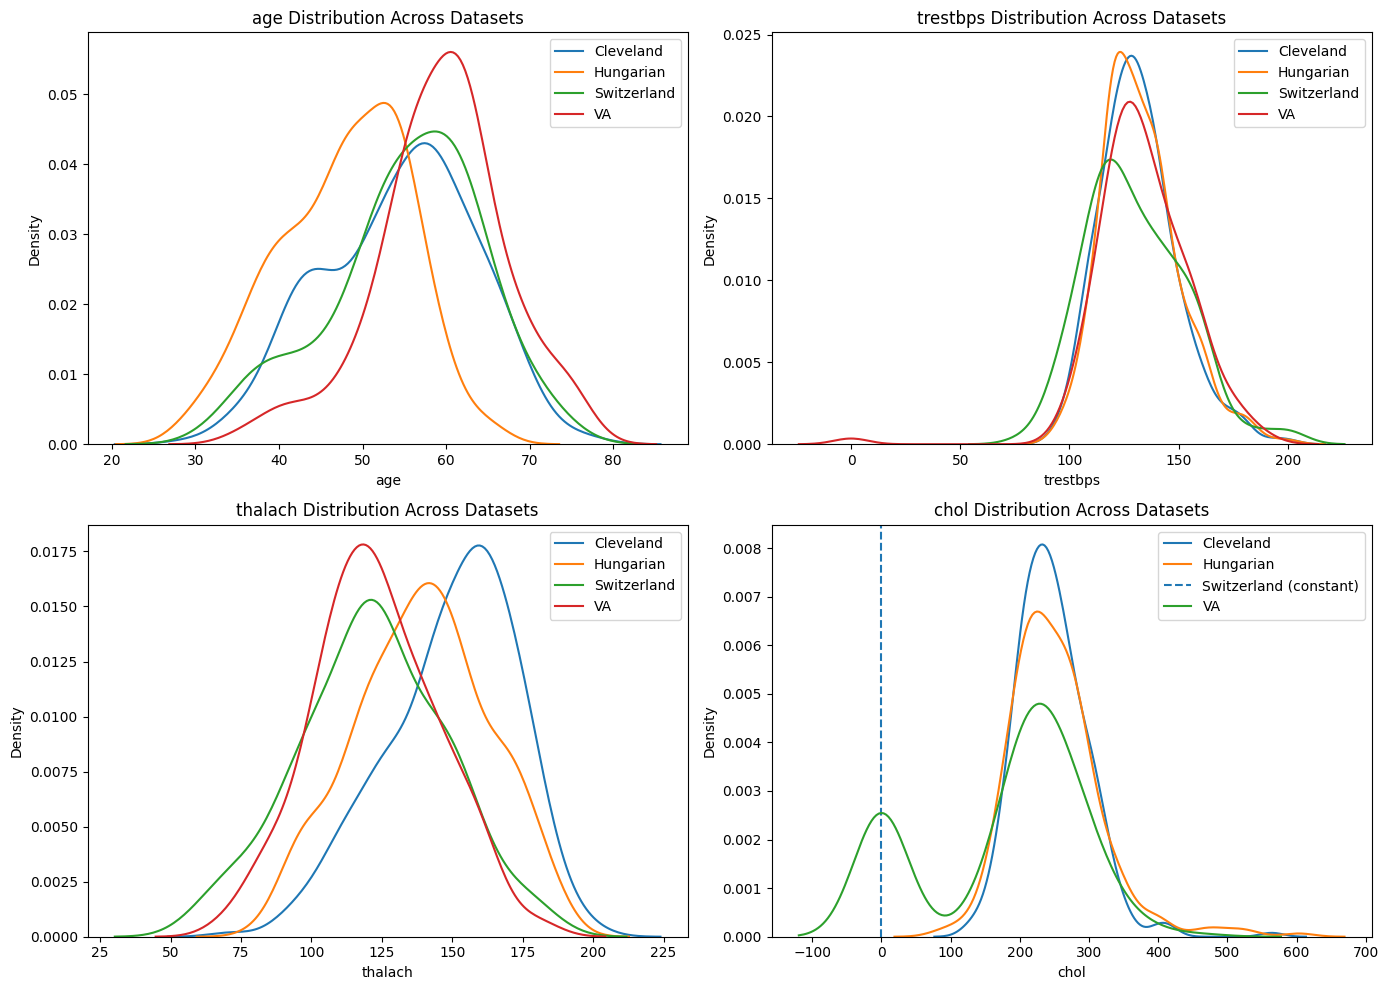

In [14]:
# Distribution Overlay (for key features only)

key_features = ["age", "trestbps", "thalach", "chol"]

n_features = len(key_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    ax = axes[i]

    for name, df in datasets.items():
        values = df[feature].dropna()

        if values.nunique() > 1:
            sns.kdeplot(values, label=name, ax=ax)
        else:
            # fallback for constant values
            ax.axvline(
                values.iloc[0],
                linestyle="--",
                label=f"{name} (constant)"
            )

    ax.set_title(f"{feature} Distribution Across Datasets")
    ax.set_xlabel(feature)
    ax.legend()

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_distribution_overlay.png", bbox_inches="tight")
plt.show()

These plots estimate the probability distribution of each feature, showing how values are spread smoothly across ranges. Overlapping curves allow direct comparison of distributions between datasets.

Age and trestbps distributions largely overlap, indicating stability across datasets. Thalach shows noticeable shifts, suggesting potential generalization challenges. Chol highlights a major issue: VA (and partly Switzerland) deviates significantly, confirming inconsistent or corrupted values.

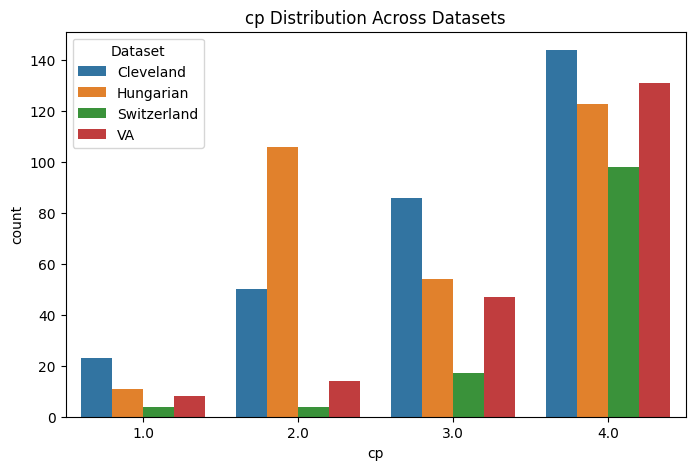

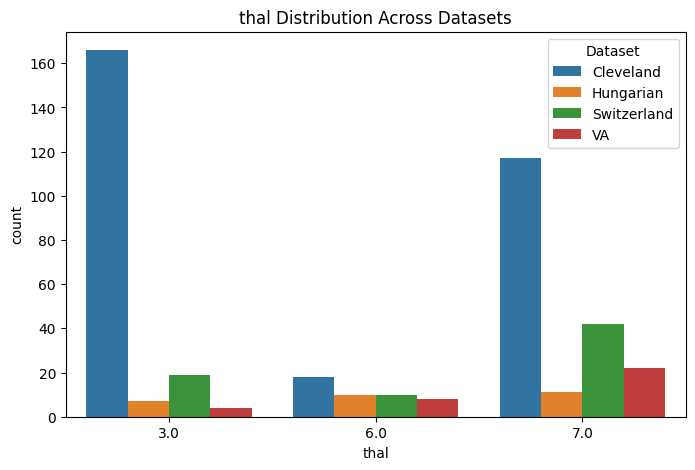

In [15]:
# Categorical Comparison

cat_features_subset = ["cp", "thal"]

for feature in cat_features_subset:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue="Dataset", data=combined_df)
    plt.title(f"{feature} Distribution Across Datasets")
    plt.show()



### Summary of Cross-Dataset Comparison

The cross-dataset comparison highlights substantial differences in feature distributions across datasets, reinforcing the presence of **dataset shift and data quality inconsistencies**.

Certain features, such as *age* and *resting blood pressure (trestbps)*, exhibit relatively stable distributions, suggesting they are reliable across datasets. In contrast, features like *maximum heart rate (thalach)* show moderate shifts, while *cholesterol (chol)* demonstrates clear inconsistencies, particularly in the VA dataset where implausible zero values indicate potential data quality issues.

These findings confirm that the datasets are not directly interchangeable and that naive merging may introduce bias or degrade model performance. Instead, feature selection and model design must account for both **distributional differences and dataset-specific artifacts**.

This analysis further supports a **tiered modeling approach**, where feature sets are carefully chosen based on their availability and stability across datasets.

## Feature-Target Relationships

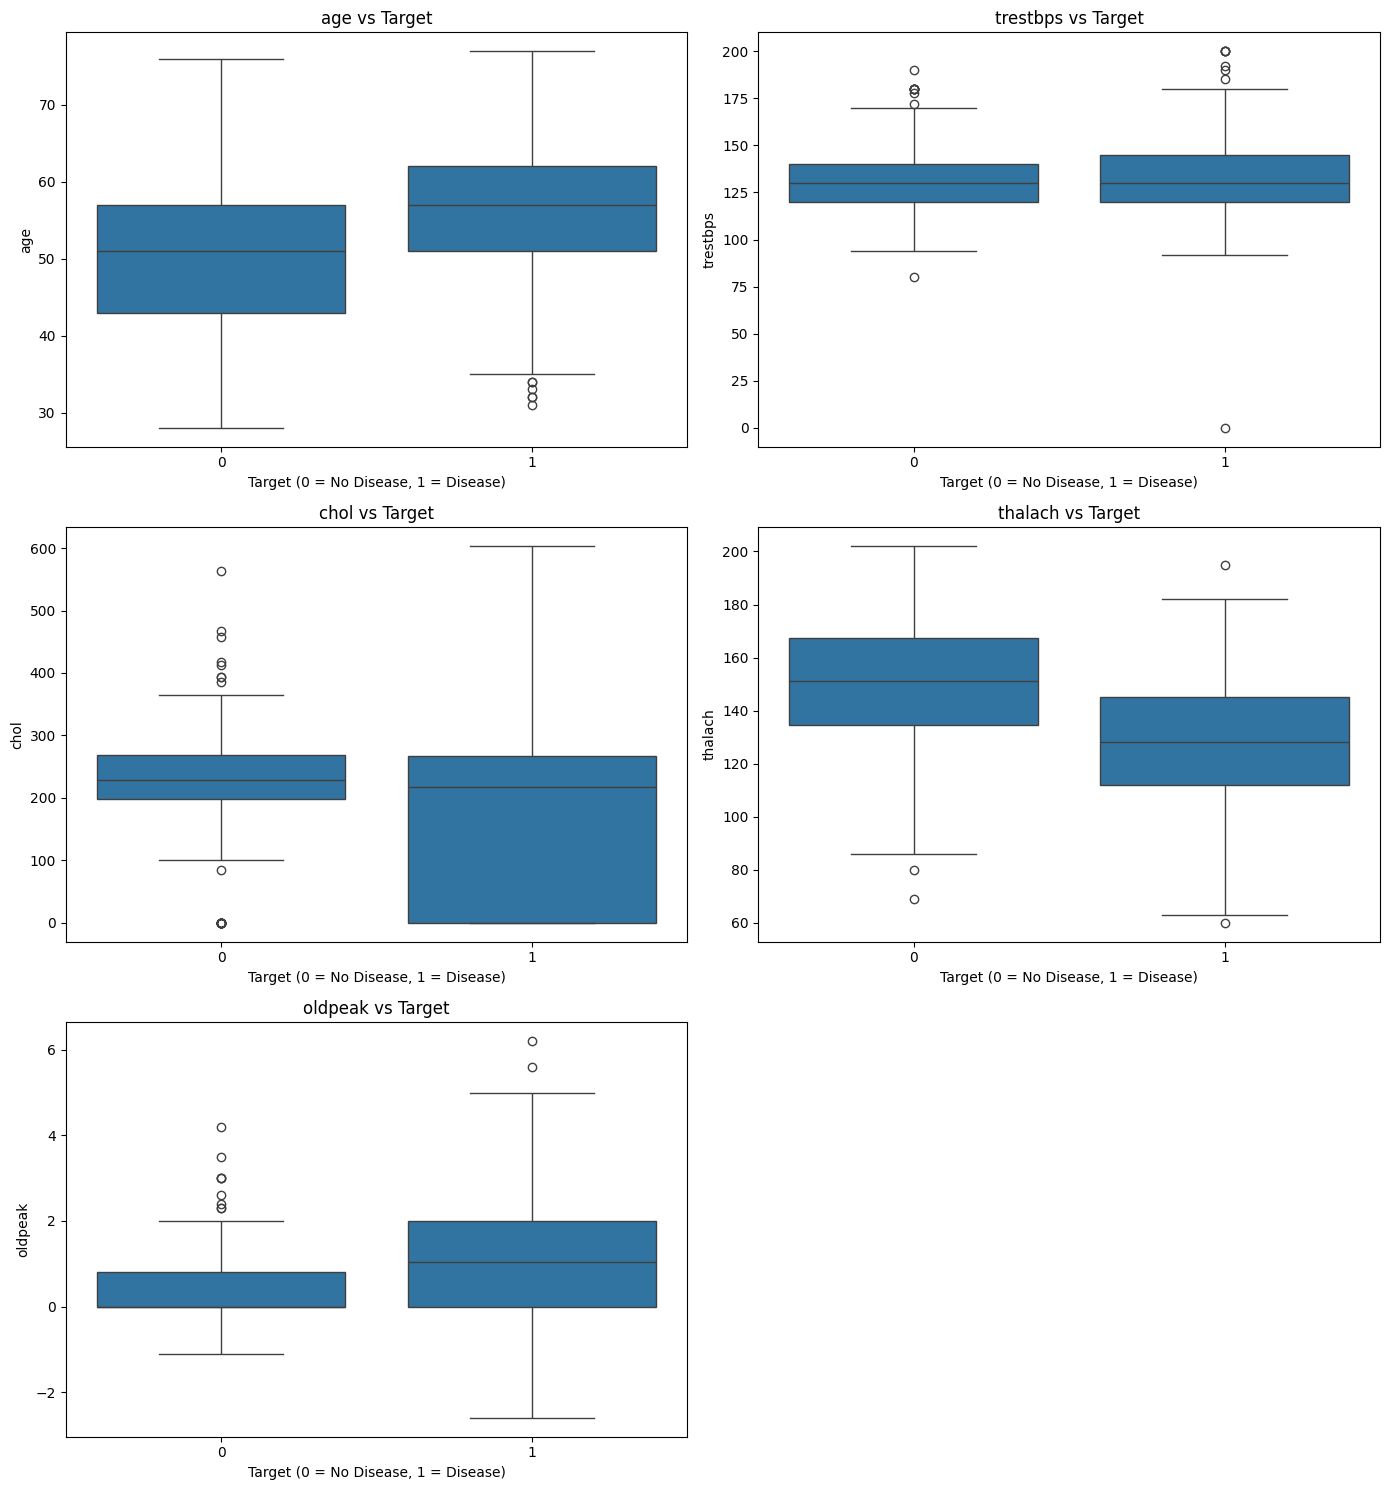

In [16]:
# Feature–Target Relationships

combined_df["target"] = (combined_df["num"] > 0).astype(int)

n_features = len(numerical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x="target", y=feature, data=combined_df, ax=axes[i])
    axes[i].set_title(f"{feature} vs Target")
    axes[i].set_xlabel("Target (0 = No Disease, 1 = Disease)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_feature-target_relationships_continuous.png", bbox_inches="tight")
plt.show()

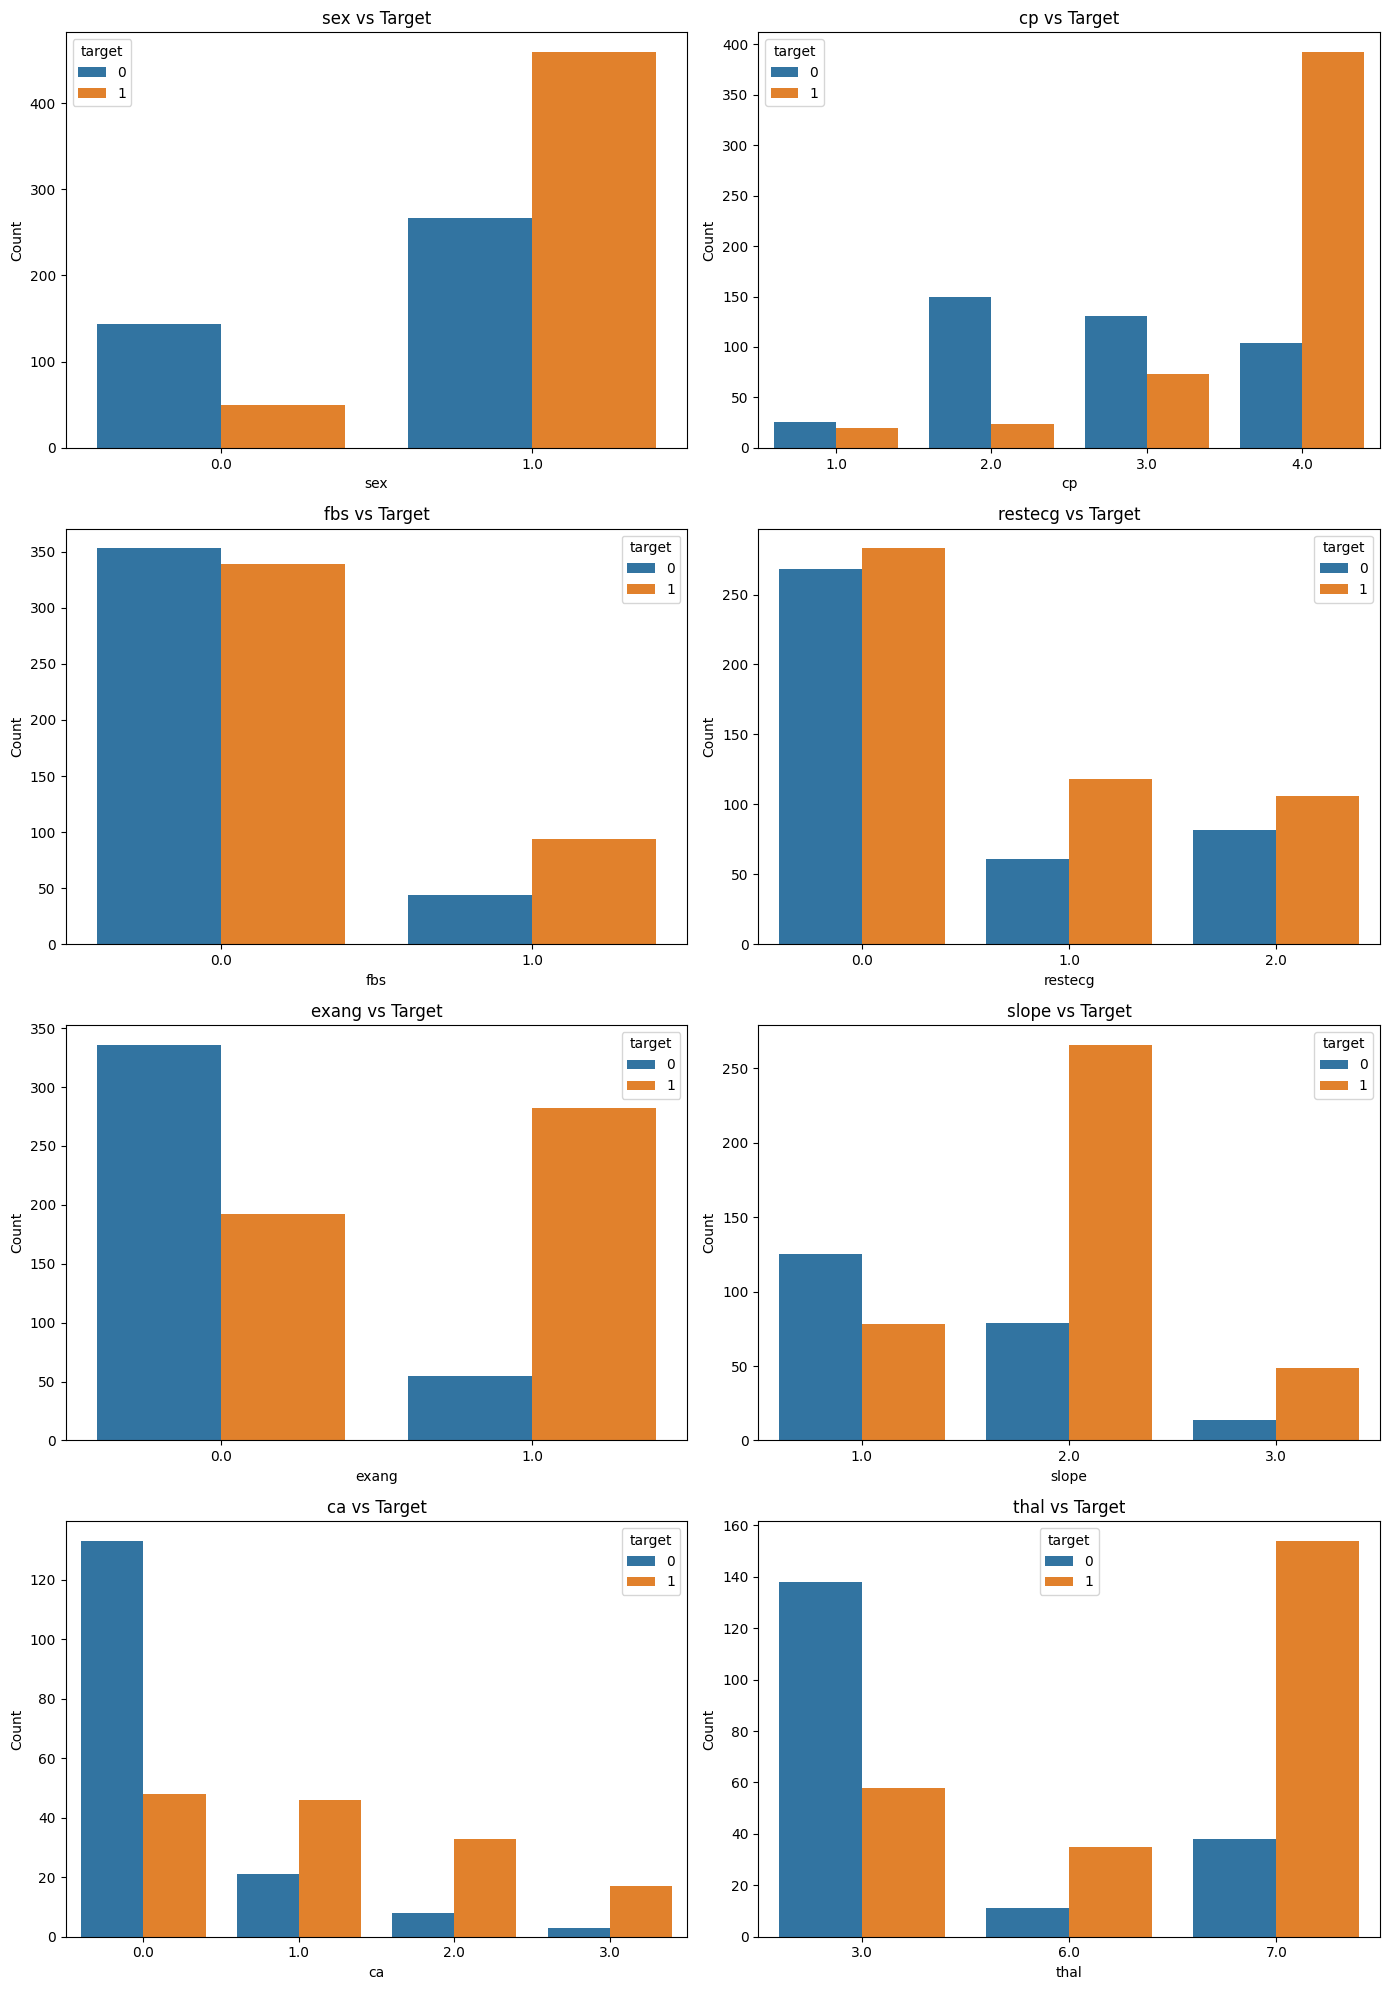

In [17]:
n_features = len(categorical_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue="target", data=combined_df, ax=axes[i])
    axes[i].set_title(f"{feature} vs Target")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("uci_plots/eda_feature-target_relationships_categorical.png", bbox_inches="tight")
plt.show()

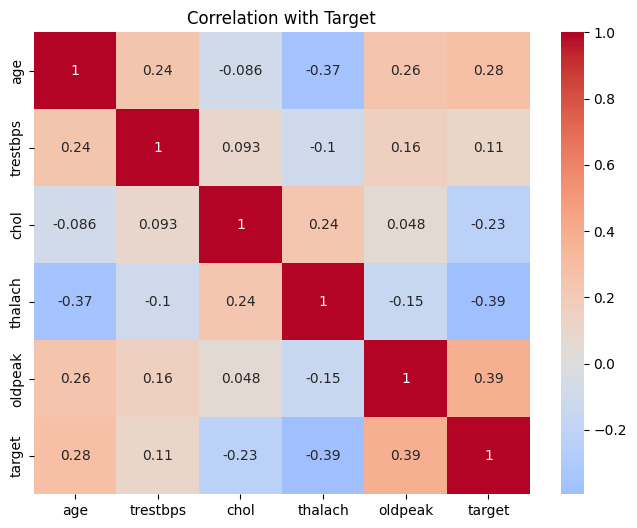

In [18]:
corr = combined_df[numerical_features + ["target"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with Target")
plt.savefig("uci_plots/eda_correlation_matrix.png", bbox_inches="tight")
plt.show()

### Summary of Feature-Target Relationships

The analysis of feature–target relationships reveals several strong predictors of heart disease, alongside features with limited or inconsistent predictive value.

Among numerical variables, *maximum heart rate (thalach)* and *oldpeak* exhibit the strongest relationships with the target. Lower thalach values and higher oldpeak values are clearly associated with increased disease risk. *Age* shows a moderate positive relationship, while *resting blood pressure (trestbps)* demonstrates only weak predictive power. *Cholesterol (chol)* does not display a consistent relationship with the target and is further affected by data quality issues in certain datasets.

For categorical features, *chest pain type (cp)*, *exercise-induced angina (exang)*, *number of vessels (ca)*, and *thalassemia (thal)* show strong separation between classes, indicating high predictive value. In contrast, *fasting blood sugar (fbs)* provides little discriminatory power.

Importantly, some of the most predictive features (e.g., *ca* and *thal*) are not consistently available across datasets, highlighting a key trade-off between predictive strength and feature availability.

## Missing Data Analysis and Feature Availability Matrix

In [19]:
missing_summary = pd.DataFrame()

for name, df in datasets.items():
    missing = df.isnull().mean() * 100  # percentage
    missing_summary[name] = missing

missing_summary = missing_summary.T
missing_summary

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
Cleveland,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.320132,0.660066,0.0
Hungarian,0.0,0.0,0.0,0.340136,7.823129,2.721088,0.340136,0.340136,0.340136,0.000000,64.625850,98.979592,90.476190,0.0
Switzerland,0.0,0.0,0.0,1.626016,0.000000,60.975610,0.813008,0.813008,0.813008,4.878049,13.821138,95.934959,42.276423,0.0
VA,0.0,0.0,0.0,28.000000,3.500000,3.500000,0.000000,26.500000,26.500000,28.000000,51.000000,99.000000,83.000000,0.0


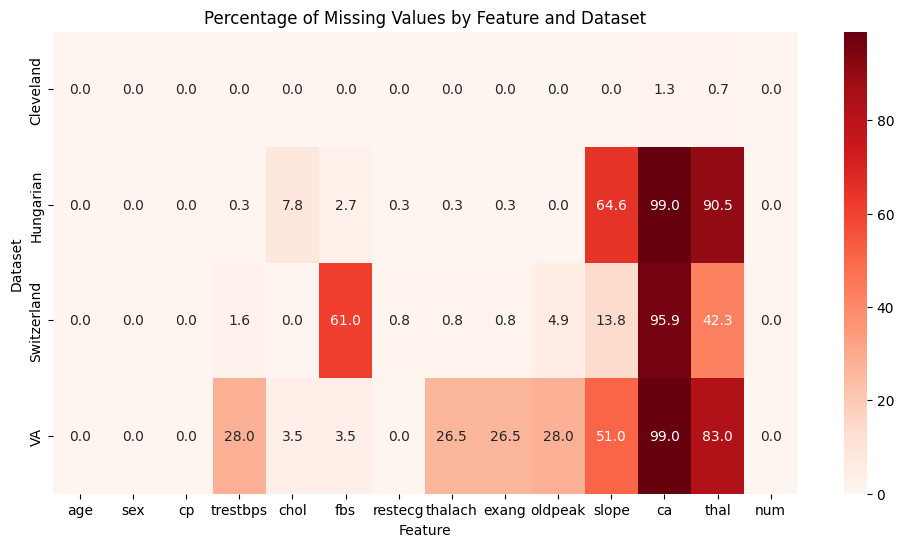

In [20]:
plt.figure(figsize=(12, 6))
sns.heatmap(missing_summary, annot=True, cmap="Reds", fmt=".1f")
plt.title("Percentage of Missing Values by Feature and Dataset")
plt.ylabel("Dataset")
plt.xlabel("Feature")
plt.savefig("uci_plots/eda_percentage_of_missing_values_by_feature_and_dataset.png", bbox_inches="tight")
plt.show()

Each cell represents the percentage of missing values for a feature in a dataset, with darker colors indicating more missing data. This provides a quick overview of where data is incomplete.

Cleveland is nearly complete, while Hungarian, Switzerland, and VA exhibit heavy missingness in key clinical features like ca, thal, and slope. Missingness is highly structured rather than random, which limits the ability to combine datasets directly. This strongly motivates separate modeling strategies.

In [21]:
# Feature Availability

availability = (missing_summary == 0).astype(int)
# availability = (missing_summary < 5).astype(int)  # allow up to 5% missing
availability

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
Cleveland,1,1,1,1,1,1,1,1,1,1,1,0,0,1
Hungarian,1,1,1,0,0,0,0,0,0,1,0,0,0,1
Switzerland,1,1,1,0,1,0,0,0,0,0,0,0,0,1
VA,1,1,1,0,0,0,1,0,0,0,0,0,0,1


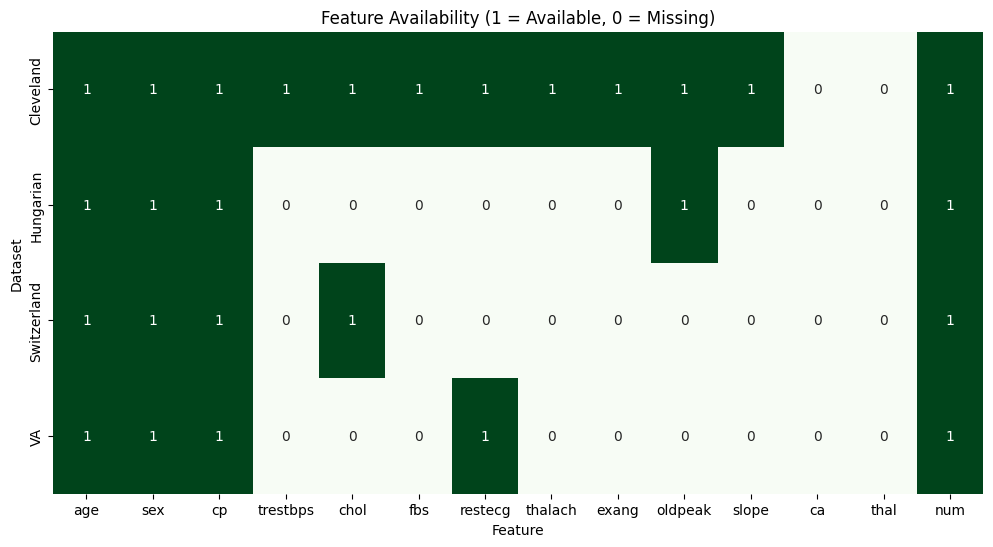

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(availability, annot=True, cmap="Greens", cbar=False)
plt.title("Feature Availability (1 = Available, 0 = Missing)")
plt.ylabel("Dataset")
plt.xlabel("Feature")
plt.savefig("uci_plots/eda_feature_availability.png", bbox_inches="tight")
plt.show()

This is a simplified version of missing data: 1 means a feature is available, 0 means it is effectively unusable. It highlights which features can realistically be used across datasets.

Only a small core set of features (age, sex, cp) is consistently available across all datasets. Many clinically important features (ca, thal, slope) are only usable in Cleveland.

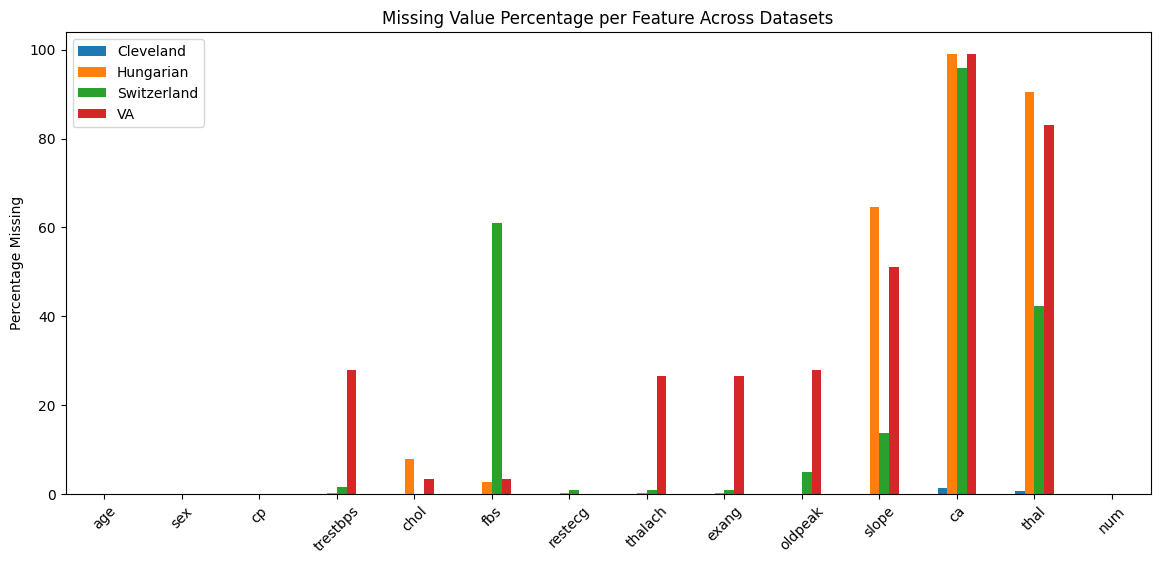

In [23]:
# Missingness Distribution

missing_summary.T.plot(kind="bar", figsize=(14, 6))
plt.title("Missing Value Percentage per Feature Across Datasets")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=45)
plt.savefig("uci_plots/eda_missingness_distribution.png", bbox_inches="tight")
plt.show()

This plot compares missing value percentages for each feature across datasets using bars, making it easier to see differences feature-by-feature.

It reinforces that missingness is concentrated in specific features rather than spread evenly. Features like ca, thal, and slope are almost entirely missing outside Cleveland, while others like trestbps and thalach are inconsistently available. This further confirms that feature selection must be dataset-aware.

---

### Summary of Missing Data and Feature Availability

The analysis of missing data reveals substantial variability in feature availability across datasets, with clear implications for model design.

The Cleveland dataset is nearly complete, with only minimal missingness in a few features, making it suitable for full-feature modeling. In contrast, the Hungarian, Switzerland, and VA datasets exhibit significant and systematic missingness, particularly for features such as *ca*, *thal*, and *slope*, which are largely unavailable outside Cleveland.

A subset of features, including *age*, *sex*, and *cp*, is consistently available across all datasets, while others such as *trestbps*, *thalach*, and *oldpeak* are partially available but exhibit varying levels of completeness.

---

## EDA Conclusion and Modeling Strategy

The exploratory analysis highlights substantial differences across the UCI heart disease datasets in terms of data quality, feature availability, and class distribution.

The Cleveland dataset is nearly complete and relatively balanced, making it the most suitable source for model training. In contrast, the Hungarian dataset exhibits moderate missingness, while the Switzerland and VA datasets show extensive missing data and strong class imbalance, limiting their usefulness for training.

Missingness is highly structured rather than random. Features such as *ca*, *thal*, and *slope* are largely unavailable outside Cleveland, while others (*trestbps*, *thalach*, *oldpeak*) are inconsistently present. In addition, several features display distributional differences across datasets, and some (e.g., *chol* in VA) contain clear data quality issues.

Feature–target analysis indicates that *cp*, *thalach*, *oldpeak*, *exang*, *ca*, and *thal* are the most informative predictors, while *trestbps*, *fbs*, and *chol* provide limited or unreliable signal. Importantly, the most predictive features are not consistently available across datasets, creating a trade-off between predictive performance and applicability.

---

### Modeling Approach

To address these constraints, a tiered modeling strategy will be adopted:

#### Model 1 - Full Clinical Model

* **Dataset:** Cleveland
* **Features:** All available features
* **Objective:** Maximize predictive performance using complete clinical information

#### Model 2 - Reduced Clinical Model

* **Dataset:** Cleveland (primary), optionally Hungarian
* **Features:** Excludes *ca*, *thal*, and *slope*
* **Objective:** Balance performance and feature availability

#### Model 3 - Minimal Model

* **Dataset:** All datasets (primarily for evaluation)
* **Features:** Core set (*age*, *sex*, *cp*, *trestbps*, *thalach*)
* **Objective:** Maximize robustness and usability under limited input

---

### Dataset Usage

* **Cleveland:** Primary training dataset
* **Hungarian:** Supplementary validation for reduced model
* **Switzerland, VA:** Limited use for robustness evaluation due to missingness and imbalance

# Model 1: Full Clinical Model (Cleveland)

## Preprocessing

In [24]:
def build_preprocessor(numerical_features, categorical_features):
    """
    Build a consistent preprocessing pipeline for tabular heart disease models.

    Parameters
    ----------
    numerical_features : list[str]
        Continuous/numeric columns to impute and scale.
    categorical_features : list[str]
        Categorical columns to impute and one-hot encode.

    Returns
    -------
    ColumnTransformer
        A sklearn column transformer ready to plug into a full model pipeline.
    """
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor

In [25]:
# Preprocessing

df_model1 = df_cleveland.copy()

# Binary target: presence of heart disease
df_model1["target"] = (df_model1["num"] > 0).astype(int)

# Drop original multiclass label
df_model1 = df_model1.drop(columns=["num"])

# Feature groups
numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# Inputs / target
X = df_model1[numerical_features + categorical_features]
y = df_model1["target"]

print("Shape of X:", X.shape)
print("\nTarget distribution:")
print(y.value_counts(normalize=True).rename("proportion"))

Shape of X: (303, 13)

Target distribution:
target
0    0.541254
1    0.458746
Name: proportion, dtype: float64


In [26]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))


Training set shape: (242, 13)
Test set shape: (61, 13)

Train target distribution:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test target distribution:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [27]:
# Missingness check

def summarize_missingness(df, name="dataset"):
    missing_counts = df.isna().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if missing_counts.empty:
        print(f"\n{name}: no missing values.")
        return

    missing_pct = (missing_counts / len(df) * 100).round(2)
    summary = (
        missing_counts.to_frame("missing_count")
        .assign(missing_pct=missing_pct)
    )

    print(f"\n{name} missingness summary:")
    display(summary)


summarize_missingness(X_train, "X_train")
summarize_missingness(X_test, "X_test")


X_train missingness summary:


,missing_count,missing_pct
ca,1,0.41
thal,1,0.41



X_test missingness summary:


,missing_count,missing_pct
ca,3,4.92
thal,1,1.64


In [28]:
preprocessor_model1 = build_preprocessor(
    numerical_features=numerical_features,
    categorical_features=categorical_features
)

## Logistic Regression

In [29]:
# Logistic regression pipeline + CV tuning

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_model1),
    ("classifier", LogisticRegression(
        l1_ratio=0,
        solver="liblinear",
        max_iter=1000
    ))
])

param_grid_logreg = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [30]:
grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

grid_logreg.fit(X_train, y_train)

best_logreg = grid_logreg.best_estimator_

print("Best parameters:", grid_logreg.best_params_)
print(f"Best CV ROC-AUC: {grid_logreg.best_score_:.4f}")

Best parameters: {'classifier__C': 1}
Best CV ROC-AUC: 0.9025


In [31]:
# Test predictions
y_pred_logreg = best_logreg.predict(X_test)
y_proba_logreg = best_logreg.predict_proba(X_test)[:, 1]

In [32]:
def evaluate_classifier(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = recall_score(y_true, y_pred)

    metrics = {
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Sensitivity)": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "Brier Score": brier_score_loss(y_true, y_proba)
    }

    return pd.DataFrame(
        {"Metric": list(metrics.keys()), "Value": list(metrics.values())}
    ).round(4)

logreg_results = evaluate_classifier(y_test, y_pred_logreg, y_proba_logreg)
logreg_results

,Metric,Value
0,ROC-AUC,0.9665
1,PR-AUC,0.9634
2,Accuracy,0.8852
3,Balanced Accuracy,0.8885
4,Precision,0.8387
5,Recall (Sensitivity),0.9286
6,Specificity,0.8485
7,F1 Score,0.8814
8,Brier Score,0.0797


In [33]:
# Classification report + confusion matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred_logreg, digits=4))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:\n")
print(cm_logreg)

Classification Report:

              precision    recall  f1-score   support

           0     0.9333    0.8485    0.8889        33
           1     0.8387    0.9286    0.8814        28

    accuracy                         0.8852        61
   macro avg     0.8860    0.8885    0.8851        61
weighted avg     0.8899    0.8852    0.8854        61

Confusion Matrix:

[[28  5]
 [ 2 26]]


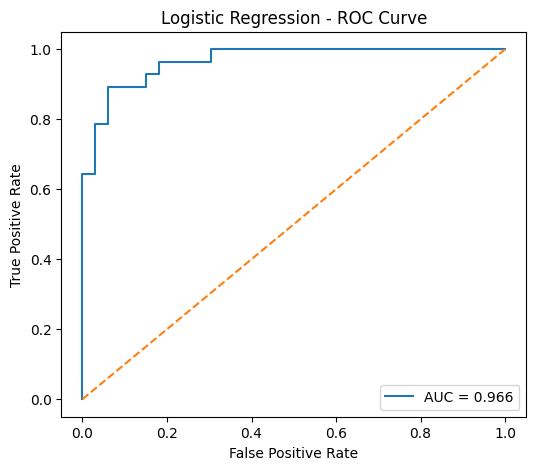

In [34]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_proba_logreg)
roc_auc = roc_auc_score(y_test, y_proba_logreg)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend(loc="lower right")
plt.savefig("uci_plots/model1_logistic_regression_roc.png", bbox_inches="tight")
plt.show()

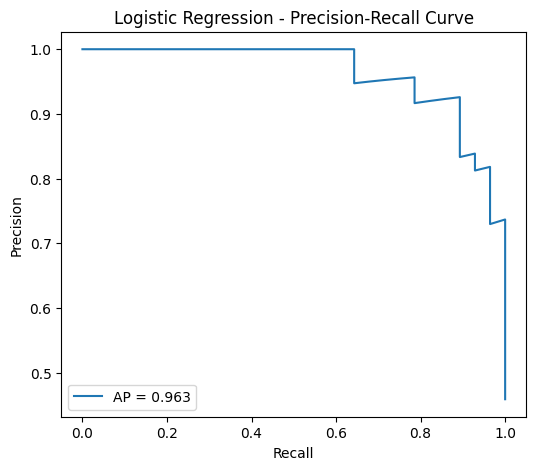

In [35]:
# precision recall curve

precision, recall, _ = precision_recall_curve(y_test, y_proba_logreg)
pr_auc = average_precision_score(y_test, y_proba_logreg)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression - Precision-Recall Curve")
plt.legend(loc="lower left")
plt.savefig("uci_plots/model1_logistic_regression_pr.png", bbox_inches="tight")
plt.show()

In [36]:
# Threshold analysis

def threshold_analysis(y_true, y_proba, thresholds):
    rows = []

    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision = precision_score(y_true, y_pred_t, zero_division=0)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)
        positive_rate = y_pred_t.mean()

        rows.append({
            "threshold": t,
            "precision": precision,
            "recall_sensitivity": sensitivity,
            "specificity": specificity,
            "f1_score": f1,
            "predicted_positive_rate": positive_rate
        })

    return pd.DataFrame(rows).round(4)

thresholds_to_test = np.arange(0.2, 0.81, 0.1)
threshold_results_logreg = threshold_analysis(y_test, y_proba_logreg, thresholds_to_test)
threshold_results_logreg

,threshold,precision,recall_sensitivity,specificity,f1_score,predicted_positive_rate
0,0.2,0.7000,1.0000,0.6364,0.8235,0.6557
1,0.3,0.7297,0.9643,0.6970,0.8308,0.6066
2,0.4,0.8182,0.9643,0.8182,0.8852,0.5410
3,0.5,0.8387,0.9286,0.8485,0.8814,0.5082
4,0.6,0.8621,0.8929,0.8788,0.8772,0.4754
5,0.7,0.9231,0.8571,0.9394,0.8889,0.4262
6,0.8,0.9545,0.7500,0.9697,0.8400,0.3607


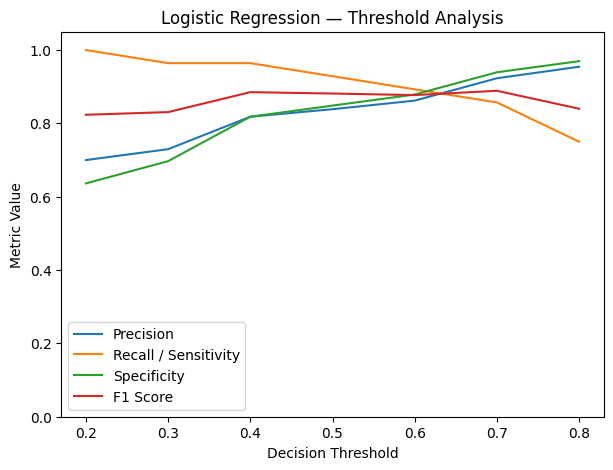

In [37]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_results_logreg["threshold"], threshold_results_logreg["precision"], label="Precision")
plt.plot(threshold_results_logreg["threshold"], threshold_results_logreg["recall_sensitivity"], label="Recall / Sensitivity")
plt.plot(threshold_results_logreg["threshold"], threshold_results_logreg["specificity"], label="Specificity")
plt.plot(threshold_results_logreg["threshold"], threshold_results_logreg["f1_score"], label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Logistic Regression — Threshold Analysis")
plt.ylim(0, 1.05)
plt.legend()
plt.savefig("uci_plots/model1_logistic_regression_threshold_analysis.png", bbox_inches="tight")
plt.show()

Logistic regression performs very strongly on the Cleveland dataset, with a best cross-validated ROC-AUC of 0.90 (C = 1) and test ROC-AUC close to 0.97. Performance is well balanced, with high sensitivity and good specificity.

Threshold analysis shows the expected trade-off: lower thresholds increase recall at the cost of more false positives, while higher thresholds improve precision and specificity but miss more true cases. The most stable region is between 0.4 and 0.6, where overall performance (F1 and balanced accuracy) is highest.

We will keep the default threshold of 0.5, which provides a good balance (≈0.93 sensitivity, ≈0.85 specificity) without overfitting the decision rule to a small test set. More task-specific threshold tuning will be addressed in later models.

## Random Forest

In [38]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_model1),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [39]:
# Evaluate with the same metric table

rf_results = evaluate_classifier(y_test, y_pred_rf, y_proba_rf)
rf_results

,Metric,Value
0,ROC-AUC,0.9491
1,PR-AUC,0.9347
2,Accuracy,0.8689
3,Balanced Accuracy,0.8734
4,Precision,0.8125
5,Recall (Sensitivity),0.9286
6,Specificity,0.8182
7,F1 Score,0.8667
8,Brier Score,0.0992


In [40]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred_rf, digits=4))

Classification Report:

              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61



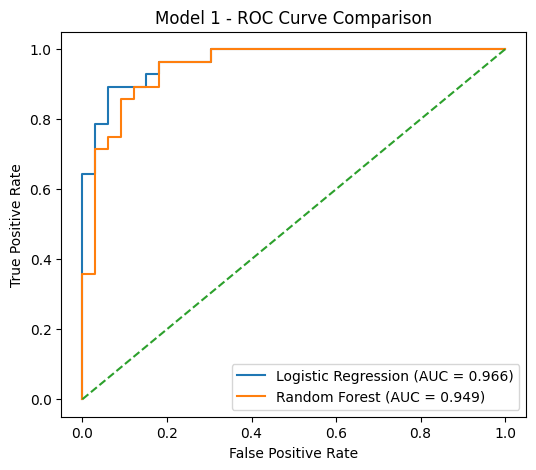

In [41]:
# ROC comparison plot

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

roc_auc_logreg = roc_auc_score(y_test, y_proba_logreg)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {roc_auc_logreg:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model 1 - ROC Curve Comparison")
plt.legend(loc="lower right")
plt.savefig("uci_plots/model1_rf_roc.png", bbox_inches="tight")
plt.show()

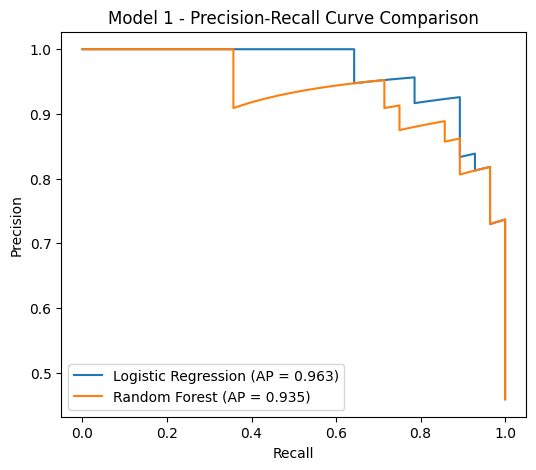

In [42]:
# Precision-recall comparison plot

precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_proba_logreg)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)

pr_auc_logreg = average_precision_score(y_test, y_proba_logreg)
pr_auc_rf = average_precision_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(recall_logreg, precision_logreg, label=f"Logistic Regression (AP = {pr_auc_logreg:.3f})")
plt.plot(recall_rf, precision_rf, label=f"Random Forest (AP = {pr_auc_rf:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Model 1 - Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.savefig("uci_plots/model1_rf_pr_comparison.png", bbox_inches="tight")
plt.show()

Random Forest was evaluated to test whether a non-linear model improves performance over logistic regression. In practice, it does not: ROC-AUC (0.95 vs 0.97) and PR-AUC (0.93 vs 0.96) are slightly lower, and overall classification metrics are comparable but not better.

The ROC and precision-recall curves confirm that logistic regression consistently dominates or matches Random Forest across most operating regions. Given no meaningful performance gain and reduced interpretability, logistic regression remains the preferred model for Model 1.

## Understanding Model1 Behavior

In [43]:
# Logistic regression coefficients and odds ratios

# Use the selected logistic model
logreg_clf = best_logreg.named_steps["classifier"]
logreg_feature_names = best_logreg.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_clf.coef_[0]
})

# Clean feature names
coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Convert coefficients to odds ratios
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort for inspection
coef_df = coef_df.sort_values(by="coefficient", ascending=False)

coef_df.head(15)

,feature,coefficient,odds_ratio,abs_coefficient
10,cp_4.0,1.029376,2.799318,1.029376
27,thal_7.0,0.816355,2.262238,0.816355
6,sex_1.0,0.687775,1.989284,0.687775
23,ca_2.0,0.641969,1.900219,0.641969
19,slope_2.0,0.602045,1.825850,0.602045
24,ca_3.0,0.492857,1.636986,0.492857
22,ca_1.0,0.350673,1.420023,0.350673
1,trestbps,0.340511,1.405666,0.340511
4,oldpeak,0.260193,1.297180,0.260193
17,exang_1.0,0.258041,1.294391,0.258041


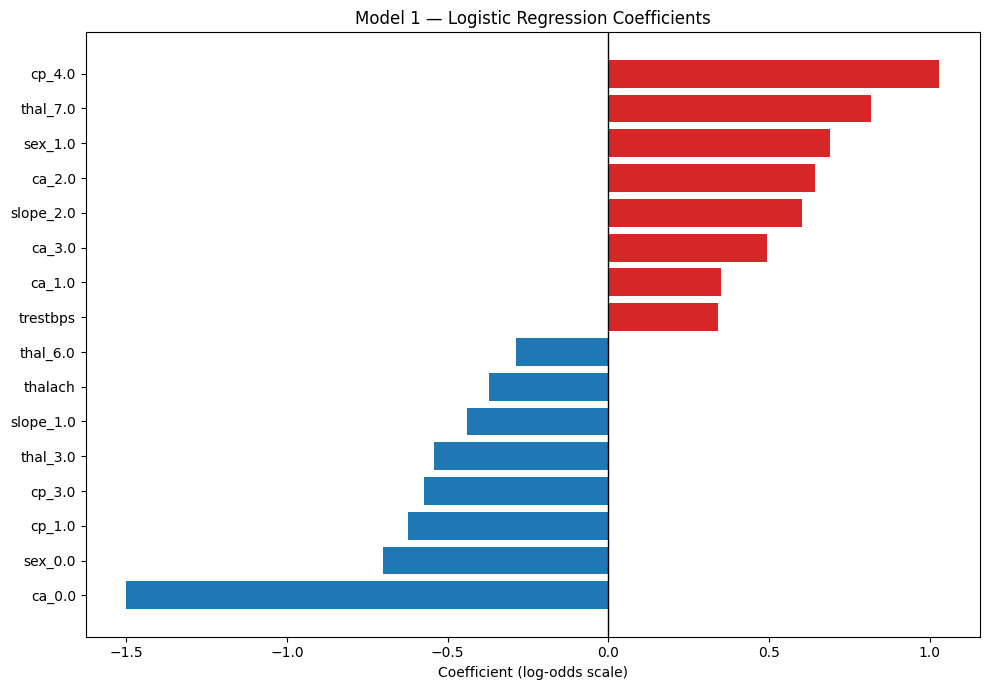

In [44]:
# Plot strongest risk-increasing and risk-decreasing features

top_n = 8

top_pos = coef_df.sort_values(by="coefficient", ascending=False).head(top_n)
top_neg = coef_df.sort_values(by="coefficient", ascending=True).head(top_n)

plot_df = pd.concat([top_pos, top_neg]).drop_duplicates()
plot_df = plot_df.sort_values(by="coefficient")

colors = ["#1f77b4" if x < 0 else "#d62728" for x in plot_df["coefficient"]]

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Model 1 — Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.savefig("uci_plots/model1_top_features.png", bbox_inches="tight")
plt.show()

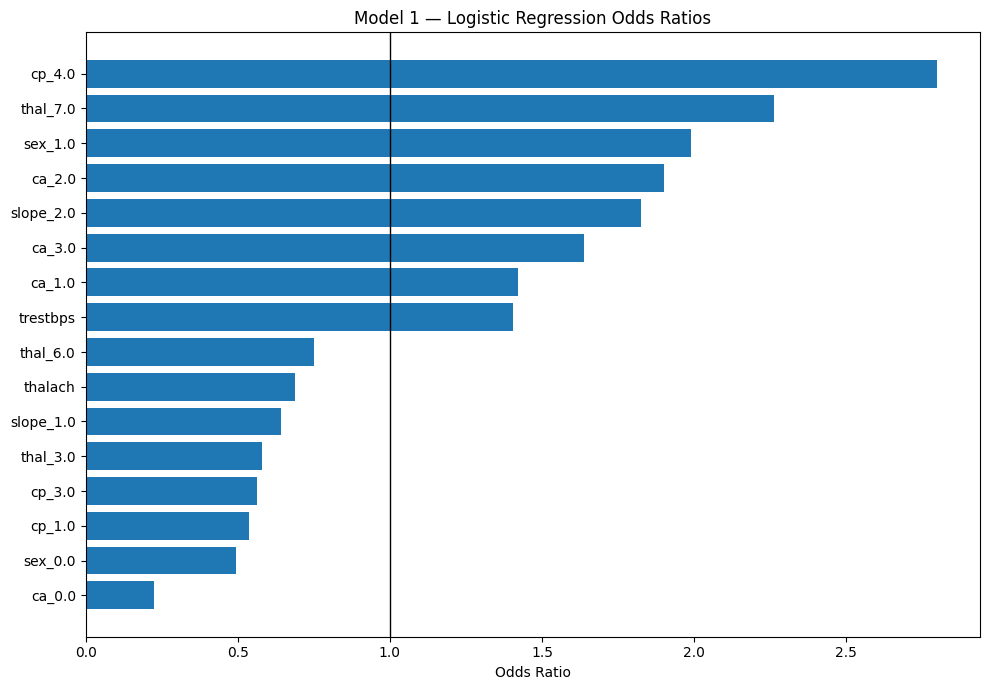

In [45]:
plot_df_or = pd.concat([top_pos, top_neg]).drop_duplicates()
plot_df_or = plot_df_or.sort_values(by="odds_ratio")

plt.figure(figsize=(10, 7))
plt.barh(plot_df_or["feature"], plot_df_or["odds_ratio"])
plt.axvline(1, color="black", linewidth=1)

plt.title("Model 1 — Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.tight_layout()
plt.savefig("uci_plots/model1_logistic_regression_odds_ratios.png", bbox_inches="tight")
plt.show()

In [46]:
# A compact interpretation table

interpretation_table = coef_df.copy()
interpretation_table["direction"] = np.where(
    interpretation_table["coefficient"] > 0,
    "Higher predicted risk",
    "Lower predicted risk"
)

interpretation_table = interpretation_table[
    ["feature", "coefficient", "odds_ratio", "direction"]
].sort_values(by="coefficient", ascending=False)

interpretation_table.head(15)

,feature,coefficient,odds_ratio,direction
10,cp_4.0,1.029376,2.799318,Higher predicted risk
27,thal_7.0,0.816355,2.262238,Higher predicted risk
6,sex_1.0,0.687775,1.989284,Higher predicted risk
23,ca_2.0,0.641969,1.900219,Higher predicted risk
19,slope_2.0,0.602045,1.825850,Higher predicted risk
24,ca_3.0,0.492857,1.636986,Higher predicted risk
22,ca_1.0,0.350673,1.420023,Higher predicted risk
1,trestbps,0.340511,1.405666,Higher predicted risk
4,oldpeak,0.260193,1.297180,Higher predicted risk
17,exang_1.0,0.258041,1.294391,Higher predicted risk


In [47]:
# Random Forest feature importance

rf_clf = rf_pipeline.named_steps["classifier"]
rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

rf_importance_df = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_clf.feature_importances_
})

rf_importance_df["feature"] = (
    rf_importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

rf_importance_df = rf_importance_df.sort_values(by="importance", ascending=False)

rf_importance_df.head(15)

,feature,importance
25,thal_3.0,0.107736
27,thal_7.0,0.090685
21,ca_0.0,0.090365
10,cp_4.0,0.081543
3,thalach,0.079659
4,oldpeak,0.075000
0,age,0.063828
2,chol,0.061374
1,trestbps,0.048583
16,exang_0.0,0.040067


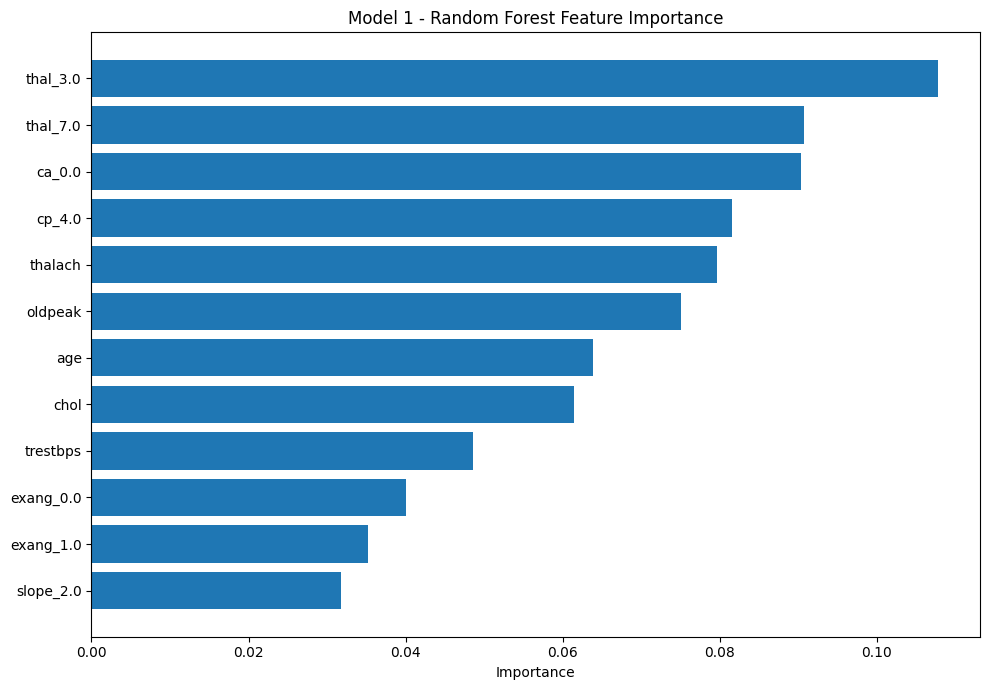

In [48]:
top_n = 12
plot_rf = rf_importance_df.head(top_n).sort_values(by="importance")

plt.figure(figsize=(10, 7))
plt.barh(plot_rf["feature"], plot_rf["importance"])

plt.title("Model 1 - Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("uci_plots/model1_rf_feature_importance.png", bbox_inches="tight")
plt.show()

In [49]:
# Short consistency check table

top_logreg_features = set(
    coef_df.sort_values(by="abs_coefficient", ascending=False).head(12)["feature"]
)

top_rf_features = set(
    rf_importance_df.head(12)["feature"]
)

shared_features = sorted(top_logreg_features.intersection(top_rf_features))

consistency_df = pd.DataFrame({
    "shared_top_features": shared_features
})

consistency_df

,shared_top_features
0,ca_0.0
1,cp_4.0
2,slope_2.0
3,thal_3.0
4,thal_7.0


The model is primarily driven by **diagnostic and stress-test related features**, rather than general risk factors. The strongest positive effects come from specific chest pain (`cp_4.0`), abnormal thallium findings (`thal_7.0`), vessel involvement (`ca > 0`), and exercise-related signals (`slope_2.0`, `exang_1`, `oldpeak`), all of which are clinically consistent indicators of ischemia.

A particularly clear pattern is the role of `ca`: the absence of affected vessels (`ca_0.0`) strongly reduces predicted risk, while any increase shifts predictions upward, making it one of the most stable and interpretable drivers.

Interestingly, classic risk factors like **age play a secondary and less stable role**. Age even appears slightly negative in logistic regression, while remaining important in Random Forest. The same pattern was observed in the Framingham model, suggesting that age carries meaningful signal, but in a **non-linear or interaction-driven way** that linear models do not fully capture.

Random Forest highlights a very similar set of top features overall, confirming that both models rely on the same core signals. This reinforces that the predictive power here comes mainly from **direct cardiac measurements**, which explains why logistic regression already performs near optimally.

---

## Model 1 - Summary

Logistic Regression achieved strong performance on the Cleveland dataset (ROC-AUC ≈ 0.97) with balanced precision and recall, and stable behavior across thresholds. Hyperparameter tuning did not yield meaningful improvements, indicating that the baseline configuration is sufficient.

Random Forest was evaluated as a non-linear alternative and achieved slightly lower performance (ROC-AUC ≈ 0.94), with comparable recall but a marginally higher false positive rate. The lack of improvement suggests that the underlying relationships in the data are largely linear.

Given its superior performance, simplicity, and interpretability, Logistic Regression is selected as the primary model for the full-feature clinical setting, while Random Forest serves as a supporting benchmark confirming model choice.

---

## Export Model 1

In this section, we save Model 1 using the same export structure that will later be used for all models in the current heart disease screening project.

The goal is to separate the files by purpose:

- the `.joblib` file stores the runtime artifact needed for prediction, including the fitted pipeline, threshold, feature order, and basic model identifiers;
- the `.metadata.json` file stores documentation and evaluation information, such as the model role, validation strategy, performance metrics, selected hyperparameters, limitations, and intended use;
- the `.schema.json` file stores the expected input schema, which will later help with API validation and frontend documentation.

This structure makes the model easier to load in a generic API, easier to document, and easier to compare with the reduced and minimal-input models. It also reduces the chance that each model is exported in a slightly different format.

In [50]:
# Imports and shared export helper

def make_json_safe(obj):
    """
    Recursively convert common NumPy / pandas objects into JSON-serializable Python objects.
    """
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient="records")
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except Exception:
            pass
    return obj


def export_model_artifacts(
    model_id,
    model_display_name,
    model_role,
    pipeline,
    threshold,
    threshold_policy,
    feature_order,
    numerical_features,
    categorical_features,
    metadata,
    schema,
    artifact_dir="artifacts",
    artifact_version="1.0.0",
):
    """
    Export a model in a standardized API-ready format.

    Creates:
      - {model_id}.joblib
      - {model_id}.metadata.json
      - {model_id}.schema.json
    """
    artifact_dir = Path(artifact_dir)
    artifact_dir.mkdir(parents=True, exist_ok=True)

    artifact_path = artifact_dir / f"{model_id}.joblib"
    metadata_path = artifact_dir / f"{model_id}.metadata.json"
    schema_path = artifact_dir / f"{model_id}.schema.json"

    created_at = datetime.now(timezone.utc).isoformat()

    artifact = {
        "model_id": model_id,
        "model_display_name": model_display_name,
        "model_family": "current_heart_disease_screening",
        "model_role": model_role,

        "pipeline": pipeline,
        "threshold": float(threshold),
        "threshold_policy": threshold_policy,

        "feature_order": list(feature_order),
        "numerical_features": list(numerical_features),
        "categorical_features": list(categorical_features),

        "target_name": "num",
        "target_definition": "target = 1 if num > 0 else 0",
        "positive_class": 1,

        "schema_file": schema_path.name,
        "metadata_file": metadata_path.name,

        "artifact_version": artifact_version,
        "created_at": created_at,
    }

    metadata = {
        **metadata,
        "model_id": model_id,
        "model_display_name": model_display_name,
        "model_family": "current_heart_disease_screening",
        "model_role": model_role,
        "artifact_file": artifact_path.name,
        "schema_file": schema_path.name,
        "metadata_file": metadata_path.name,
        "artifact_version": artifact_version,
        "created_at": created_at,
    }

    schema = {
        **schema,
        "model_id": model_id,
        "model_display_name": model_display_name,
        "feature_order": list(feature_order),
    }

    joblib.dump(artifact, artifact_path)

    with open(metadata_path, "w") as f:
        json.dump(make_json_safe(metadata), f, indent=4)

    with open(schema_path, "w") as f:
        json.dump(make_json_safe(schema), f, indent=4)

    return {
        "artifact_path": str(artifact_path),
        "metadata_path": str(metadata_path),
        "schema_path": str(schema_path),
    }

In [51]:
# Model 1 schema

model1_schema = {
    "schema_version": "1.0.0",
    "description": (
        "Input schema for Model 1, the full clinical current heart disease "
        "diagnostic-support model."
    ),
    "features": {
        "age": {
            "type": "number",
            "required": True,
            "minimum": 18,
            "maximum": 100,
            "unit": "years",
            "description": "Age in years."
        },
        "trestbps": {
            "type": "number",
            "required": True,
            "minimum": 70,
            "maximum": 250,
            "unit": "mm Hg",
            "description": "Resting blood pressure."
        },
        "chol": {
            "type": "number",
            "required": True,
            "minimum": 80,
            "maximum": 700,
            "unit": "mg/dL",
            "description": "Serum cholesterol."
        },
        "thalach": {
            "type": "number",
            "required": True,
            "minimum": 60,
            "maximum": 230,
            "description": "Maximum heart rate achieved."
        },
        "oldpeak": {
            "type": "number",
            "required": True,
            "minimum": 0,
            "maximum": 10,
            "description": "ST depression induced by exercise relative to rest."
        },
        "sex": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "female",
                "1": "male"
            },
            "description": "Biological sex as encoded in the UCI dataset."
        },
        "cp": {
            "type": "integer",
            "required": True,
            "allowed_values": [1, 2, 3, 4],
            "value_mapping": {
                "1": "typical angina",
                "2": "atypical angina",
                "3": "non-anginal pain",
                "4": "asymptomatic"
            },
            "description": "Chest pain type."
        },
        "fbs": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "fasting blood sugar <= 120 mg/dL",
                "1": "fasting blood sugar > 120 mg/dL"
            },
            "description": "Fasting blood sugar indicator."
        },
        "restecg": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1, 2],
            "value_mapping": {
                "0": "normal",
                "1": "ST-T wave abnormality",
                "2": "probable or definite left ventricular hypertrophy"
            },
            "description": "Resting electrocardiographic results."
        },
        "exang": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "no exercise-induced angina",
                "1": "exercise-induced angina"
            },
            "description": "Exercise-induced angina."
        },
        "slope": {
            "type": "integer",
            "required": True,
            "allowed_values": [1, 2, 3],
            "value_mapping": {
                "1": "upsloping",
                "2": "flat",
                "3": "downsloping"
            },
            "description": "Slope of the peak exercise ST segment."
        },
        "ca": {
            "type": "number",
            "required": True,
            "minimum": 0,
            "maximum": 3,
            "description": "Number of major vessels colored by fluoroscopy."
        },
        "thal": {
            "type": "integer",
            "required": True,
            "allowed_values": [3, 6, 7],
            "value_mapping": {
                "3": "normal",
                "6": "fixed defect",
                "7": "reversible defect"
            },
            "description": "Thalassemia / stress-test defect category."
        }
    },
    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },
    "notes": [
        "This model uses the full clinical feature set.",
        "Several features, especially ca, thal, and slope, may not be available in all datasets or real-world screening contexts.",
        "This model predicts current heart disease pattern, not 10-year CHD risk."
    ]
}

In [52]:
# Convert Model 1 performance table to JSON-safe dictionary

performance_dict_model1 = {
    row["Metric"].lower()
    .replace(" ", "_")
    .replace("-", "_")
    .replace("(", "")
    .replace(")", "")
    .replace("/", "_"): float(row["Value"])
    for _, row in logreg_results.iterrows()
}

model1_metadata = {
    "algorithm": "LogisticRegression",

    "intended_use": (
        "Full-feature current heart disease diagnostic-support model using "
        "clinical, electrocardiographic, exercise-test, fluoroscopy, and thalassemia-related inputs."
    ),

    "not_for": [
        "10-year CHD risk estimation",
        "standalone clinical diagnosis",
        "emergency decision-making"
    ],

    "training_dataset": "Cleveland",
    "external_validation_datasets": [],

    "validation_strategy": {
        "summary": "Internal stratified train/test split on the Cleveland dataset.",
        "threshold_selection": "Default threshold of 0.5 retained for balanced performance.",
        "primary_metric_context": "Internal test-set evaluation."
    },

    "features": {
        "all": list(numerical_features + categorical_features),
        "numerical": list(numerical_features),
        "categorical": list(categorical_features)
    },

    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },

    "selected_hyperparameters": {
        "C": grid_logreg.best_params_["classifier__C"]
    },

    "thresholding": {
        "selected_threshold": 0.5,
        "threshold_policy": "Default 0.5 retained for balanced performance in Model 1."
    },

    "performance": {
        "internal_test": performance_dict_model1
    },

    "limitations": [
        "This model was validated using an internal Cleveland train/test split.",
        "It depends on richer clinical variables that may be unavailable in lightweight screening settings.",
        "Features such as ca, thal, and slope have substantial missingness in some UCI heart disease datasets.",
        "The predicted score should not be interpreted as a calibrated real-world diagnostic probability without further validation."
    ]
}

In [53]:
# Export Model 1

MODEL1_ID = "model1_full_clinical_v1"

MODEL1_DISPLAY_NAME = "Model 1 - Full Clinical Logistic Regression"

MODEL1_ROLE = "full-feature current heart disease diagnostic-support model"

MODEL1_THRESHOLD = 0.5

MODEL1_THRESHOLD_POLICY = "Default 0.5 threshold retained for balanced performance in Model 1."

MODEL1_FEATURE_ORDER = numerical_features + categorical_features


model1_export_paths = export_model_artifacts(
    model_id=MODEL1_ID,
    model_display_name=MODEL1_DISPLAY_NAME,
    model_role=MODEL1_ROLE,
    pipeline=best_logreg,
    threshold=MODEL1_THRESHOLD,
    threshold_policy=MODEL1_THRESHOLD_POLICY,
    feature_order=MODEL1_FEATURE_ORDER,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    metadata=model1_metadata,
    schema=model1_schema,
    artifact_dir="artifacts",
    artifact_version="1.0.0",
)

model1_export_paths

{'artifact_path': 'artifacts/model1_full_clinical_v1.joblib',
 'metadata_path': 'artifacts/model1_full_clinical_v1.metadata.json',
 'schema_path': 'artifacts/model1_full_clinical_v1.schema.json'}

In [54]:
# Verification step

# Load standardized Model 1 artifact
loaded_artifact = joblib.load("artifacts/model1_full_clinical_v1.joblib")

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]
loaded_feature_order = loaded_artifact["feature_order"]

# Verify feature order
sample_input = X_test[loaded_feature_order].iloc[:5]

sample_proba = loaded_pipeline.predict_proba(sample_input)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

print("Model ID:", loaded_artifact["model_id"])
print("Display name:", loaded_artifact["model_display_name"])
print("Threshold:", loaded_threshold)
print("Feature order matches input:", list(sample_input.columns) == loaded_feature_order)
print("Probabilities:", sample_proba)
print("Predictions:", sample_pred)

Model ID: model1_full_clinical_v1
Display name: Model 1 - Full Clinical Logistic Regression
Threshold: 0.5
Feature order matches input: True
Probabilities: [0.20913283 0.60237053 0.02152432 0.0333146  0.31222695]
Predictions: [0 1 0 0 0]


# Model 2: Reduced feature list

## Model 2A: Baseline external validation

In [55]:
# Reduced feature set

model2_features = [
    "age", "sex", "cp", "trestbps", "chol",
    "restecg", "thalach", "exang", "oldpeak"
]

model2_numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
model2_categorical_features = ["sex", "cp", "restecg", "exang"]

In [56]:
# Helper to prepare binary target

def prepare_binary_dataset(df, features, target_col="num"):
    df = df.copy()
    df[target_col] = (df[target_col] > 0).astype(int)
    X = df[features]
    y = df[target_col]
    return X, y

In [57]:
# Prepare Cleveland training split

X_cleveland, y_cleveland = prepare_binary_dataset(
    df_cleveland,
    model2_features,
    target_col="num"
)

X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_cleveland,
    y_cleveland,
    test_size=0.20,
    random_state=42,
    stratify=y_cleveland
)

print("Cleveland train shape:", X_train_m2.shape)
print("Cleveland test shape:", X_test_m2.shape)

print("\nTrain target distribution:")
print(y_train_m2.value_counts(normalize=True).rename("proportion"))

print("\nTest target distribution:")
print(y_test_m2.value_counts(normalize=True).rename("proportion"))

Cleveland train shape: (242, 9)
Cleveland test shape: (61, 9)

Train target distribution:
num
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Test target distribution:
num
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [58]:
# Build baseline pipeline

preprocessor_model2_baseline = build_preprocessor(
    numerical_features=model2_numerical_features,
    categorical_features=model2_categorical_features
)

logreg_model2_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor_model2_baseline),
    ("classifier", LogisticRegression(
        C=1.0,
        l1_ratio=0,
        solver="liblinear",
        max_iter=1000
    ))
])

logreg_model2_baseline.fit(X_train_m2, y_train_m2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [59]:
# Dataset evaluation helper

def evaluate_on_dataset(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "dataset": dataset_name,
        "n": len(y),
        "positive_rate": y.mean(),
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y, y_pred, zero_division=0),
        "brier_score": brier_score_loss(y, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [60]:
# Evaluate on Cleveland hold-out + external datasets

baseline_results = []

# Cleveland hold-out
baseline_results.append(
    evaluate_on_dataset(
        logreg_model2_baseline,
        X_test_m2,
        y_test_m2,
        "Cleveland (hold-out)"
    )
)

# External datasets
external_datasets = {
    "Hungarian": df_hungarian,
    "Switzerland": df_switzerland,
    "VA": df_va
}

for dataset_name, df_ext in external_datasets.items():
    X_ext, y_ext = prepare_binary_dataset(df_ext, model2_features, target_col="num")
    baseline_results.append(
        evaluate_on_dataset(
            logreg_model2_baseline,
            X_ext,
            y_ext,
            dataset_name
        )
    )

baseline_results_df = pd.DataFrame(baseline_results).round(4)
baseline_results_df

,dataset,n,positive_rate,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,brier_score,tn,fp,fn,tp
0,Cleveland (hold-out),61,0.4590,0.9567,0.9377,0.9016,0.9010,0.8929,0.8929,0.9091,0.8929,0.0935,30,3,3,25
1,Hungarian,294,0.3605,0.8773,0.8379,0.8163,0.8091,0.7281,0.7830,0.8351,0.7545,0.1326,157,31,23,83
2,Switzerland,123,0.9350,0.7533,0.9786,0.5447,0.5821,0.9538,0.5391,0.6250,0.6889,0.3026,5,3,53,62
3,VA,200,0.7450,0.7239,0.8721,0.6900,0.6436,0.8271,0.7383,0.5490,0.7801,0.1973,28,23,39,110


### Baseline Summary

The reduced-feature logistic regression model demonstrates strong performance on the Cleveland dataset (ROC-AUC ≈ 0.96), confirming that the selected feature subset retains most of the predictive signal.

When evaluated on external datasets, performance varies significantly:

* The model generalizes well to the Hungarian dataset (ROC-AUC ≈ 0.88), suggesting similar feature–target relationships.
* However, performance drops substantially on the Switzerland (ROC-AUC ≈ 0.75) and VA (ROC-AUC ≈ 0.72) datasets.

This degradation highlights the presence of **dataset shift**, likely driven by:

* differences in class distribution,
* variations in feature distributions,
* and inconsistencies in data collection across cohorts.

In particular, the model shows a tendency to overpredict the positive class in the Switzerland and VA datasets, indicating poor probability calibration under distribution shift.

These findings suggest that while the reduced feature set is robust, **training on a single dataset is insufficient for generalizable risk prediction**.

---

## Model 2B: Pooled reduced-feature logistic regression

To improve transportability beyond the Cleveland-only baseline, we train the reduced-feature logistic regression model on pooled data from all four cohorts and evaluate it using GroupKFold, where each fold holds out one dataset entirely. This provides a stricter estimate of cross-site generalization.

In [61]:
# Group-aware cross-dataset validation

model2_features = [
    "age", "sex", "cp", "trestbps", "chol",
    "restecg", "thalach", "exang", "oldpeak"
]

model2_numerical_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
model2_categorical_features = ["sex", "cp", "restecg", "exang"]


def prepare_grouped_dataset(df, source_name, features, target_col="num"):
    df = df.copy()
    df[target_col] = (df[target_col] > 0).astype(int)
    df["dataset_source"] = source_name
    return df[features + [target_col, "dataset_source"]]


cleveland_prepared = prepare_grouped_dataset(df_cleveland, "Cleveland", model2_features)
hungarian_prepared = prepare_grouped_dataset(df_hungarian, "Hungarian", model2_features)
switzerland_prepared = prepare_grouped_dataset(df_switzerland, "Switzerland", model2_features)
va_prepared = prepare_grouped_dataset(df_va, "VA", model2_features)

combined_df_model2 = pd.concat(
    [
        cleveland_prepared,
        hungarian_prepared,
        switzerland_prepared,
        va_prepared
    ],
    axis=0,
    ignore_index=True
)

X_model2 = combined_df_model2[model2_features]
y_model2 = combined_df_model2["num"]
groups_model2 = combined_df_model2["dataset_source"]

print("Combined dataset shape:", combined_df_model2.shape)
print("\nSamples by dataset:")
print(groups_model2.value_counts())

print("\nPositive rate by dataset:")
print(
    combined_df_model2.groupby("dataset_source")["num"]
    .mean()
    .sort_values(ascending=False)
    .rename("positive_rate")
)

Combined dataset shape: (920, 11)

Samples by dataset:
dataset_source
Cleveland      303
Hungarian      294
VA             200
Switzerland    123
Name: count, dtype: int64

Positive rate by dataset:
dataset_source
Switzerland    0.934959
VA             0.745000
Cleveland      0.458746
Hungarian      0.360544
Name: positive_rate, dtype: float64


In [62]:
# Build balanced logistic pipeline

preprocessor_model2 = build_preprocessor(
    numerical_features=model2_numerical_features,
    categorical_features=model2_categorical_features
)

logreg_model2_grouped = Pipeline(steps=[
    ("preprocessor", preprocessor_model2),
    ("classifier", LogisticRegression(
        C=0.1,
        l1_ratio=0,
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [63]:
# GroupKFold evaluation helper

def evaluate_group_fold(y_true, y_pred, y_proba, dataset_name, fold_number):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "fold": fold_number,
        "test_dataset": dataset_name,
        "n": len(y_true),
        "positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean(),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "brier_score": brier_score_loss(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [64]:
# Run GroupKFold by dataset source

gkf_model2 = GroupKFold(n_splits=4)

grouped_results_model2 = []

for fold, (train_idx, test_idx) in enumerate(
    gkf_model2.split(X_model2, y_model2, groups=groups_model2),
    start=1
):
    X_train_fold = X_model2.iloc[train_idx]
    X_test_fold = X_model2.iloc[test_idx]
    y_train_fold = y_model2.iloc[train_idx]
    y_test_fold = y_model2.iloc[test_idx]

    train_groups = groups_model2.iloc[train_idx].unique()
    test_groups = groups_model2.iloc[test_idx].unique()

    assert len(test_groups) == 1, "Each test fold should contain exactly one dataset."
    test_dataset = test_groups[0]

    logreg_model2_grouped.fit(X_train_fold, y_train_fold)

    y_pred_fold = logreg_model2_grouped.predict(X_test_fold)
    y_proba_fold = logreg_model2_grouped.predict_proba(X_test_fold)[:, 1]

    grouped_results_model2.append(
        evaluate_group_fold(
            y_true=y_test_fold,
            y_pred=y_pred_fold,
            y_proba=y_proba_fold,
            dataset_name=test_dataset,
            fold_number=fold
        )
    )

grouped_results_model2_df = pd.DataFrame(grouped_results_model2).round(4)

grouped_results_model2_df = grouped_results_model2_df[
    [
        "fold", "test_dataset", "n", "positive_rate", "predicted_positive_rate",
        "roc_auc", "pr_auc",
        "accuracy", "balanced_accuracy",
        "precision", "recall_sensitivity", "specificity", "f1_score",
        "brier_score",
        "tn", "fp", "fn", "tp"
    ]
].sort_values(by="roc_auc", ascending=False)

grouped_results_model2_df

,fold,test_dataset,n,positive_rate,predicted_positive_rate,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,brier_score,tn,fp,fn,tp
1,2,Hungarian,294,0.3605,0.3095,0.8726,0.8246,0.8129,0.7817,0.7802,0.6698,0.8936,0.7208,0.1329,168,20,35,71
0,1,Cleveland,303,0.4587,0.4257,0.8692,0.8594,0.8020,0.7979,0.8062,0.7482,0.8476,0.7761,0.1470,139,25,35,104
2,3,VA,200,0.7450,0.7750,0.7271,0.8753,0.7500,0.6517,0.8194,0.8523,0.4510,0.8355,0.1775,23,28,22,127
3,4,Switzerland,123,0.9350,0.6829,0.7239,0.9704,0.6992,0.6647,0.9643,0.7043,0.6250,0.8141,0.1995,5,3,34,81


In [65]:
# Add a compact cross-dataset summary

summary_model2_grouped = pd.DataFrame({
    "Metric": [
        "Mean ROC-AUC",
        "Mean PR-AUC",
        "Mean Accuracy",
        "Mean Balanced Accuracy",
        "Mean Precision",
        "Mean Recall (Sensitivity)",
        "Mean Specificity",
        "Mean F1 Score",
        "Mean Brier Score"
    ],
    "Value": [
        grouped_results_model2_df["roc_auc"].mean(),
        grouped_results_model2_df["pr_auc"].mean(),
        grouped_results_model2_df["accuracy"].mean(),
        grouped_results_model2_df["balanced_accuracy"].mean(),
        grouped_results_model2_df["precision"].mean(),
        grouped_results_model2_df["recall_sensitivity"].mean(),
        grouped_results_model2_df["specificity"].mean(),
        grouped_results_model2_df["f1_score"].mean(),
        grouped_results_model2_df["brier_score"].mean()
    ]
}).round(4)

summary_model2_grouped

,Metric,Value
0,Mean ROC-AUC,0.7982
1,Mean PR-AUC,0.8824
2,Mean Accuracy,0.7660
3,Mean Balanced Accuracy,0.7240
4,Mean Precision,0.8425
5,Mean Recall (Sensitivity),0.7436
6,Mean Specificity,0.7043
7,Mean F1 Score,0.7866
8,Mean Brier Score,0.1642


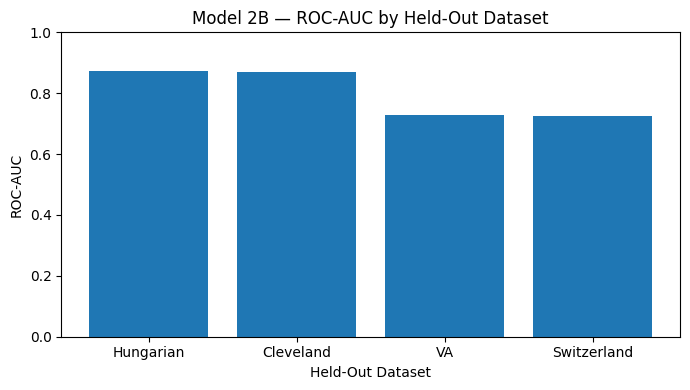

In [66]:
"""Visualisations"""

# ROC-AUC by held-out dataset

plt.figure(figsize=(7, 4))
plt.bar(grouped_results_model2_df["test_dataset"], grouped_results_model2_df["roc_auc"])
plt.title("Model 2B — ROC-AUC by Held-Out Dataset")
plt.xlabel("Held-Out Dataset")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("uci_plots/model2_model2b_roc-auc.png", bbox_inches="tight")
plt.show()

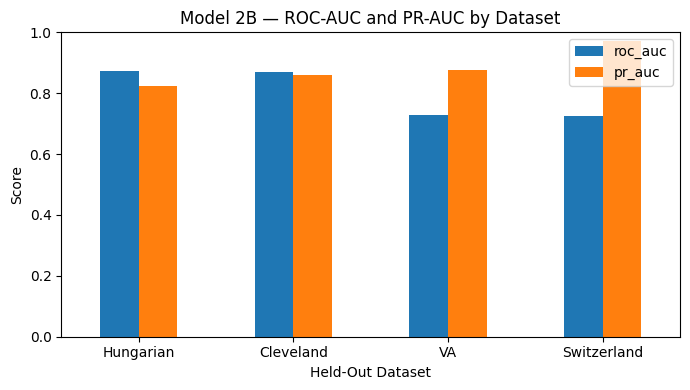

In [67]:
# ROC-AUC and PR-AUC together

plot_df = grouped_results_model2_df[["test_dataset", "roc_auc", "pr_auc"]].set_index("test_dataset")

plot_df.plot(kind="bar", figsize=(7, 4))
plt.title("Model 2B — ROC-AUC and PR-AUC by Dataset")
plt.xlabel("Held-Out Dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("uci_plots/model2_model2b_roc-auc_and_pr-auc_by_dataset.png", bbox_inches="tight")
plt.show()

Model 2B demonstrates stable cross-dataset performance, with consistent ROC-AUC and PR-AUC across held-out datasets, indicating good generalization under dataset shift. However, when compared to Model 2A, its performance is broadly similar and in some cases slightly lower, particularly on external datasets where calibration and class balance effects become more pronounced.

At this stage, Model 2B does not clearly outperform Model 2A, but it remains a viable candidate due to its pooled training strategy and conceptual robustness.

The final decision between Model 2A and Model 2B will be made in the next section, where both models are evaluated in a realistic deployment scenario against the baseline fallback strategy — using Model 1 with imputed missing features.

---

## Reduced model as a fallback strategy

In deployment, patients may not always have the full set of diagnostic variables required by Model 1. A common fallback is to impute missing values and still use the richer model. Here, we compare that strategy against a dedicated reduced-feature model trained specifically for lower-information settings.

In [68]:
# Load saved Model 1 artifact

loaded_model1_artifact = joblib.load("artifacts/model1_full_clinical_v1.joblib")

model1_loaded_pipeline = loaded_model1_artifact["pipeline"]
model1_loaded_threshold = loaded_model1_artifact["threshold"]
model1_loaded_feature_order = loaded_model1_artifact["feature_order"]

print("Loaded model:", loaded_model1_artifact["model_id"])
print("Threshold:", model1_loaded_threshold)
print("Feature order:", model1_loaded_feature_order)

Loaded model: model1_full_clinical_v1
Threshold: 0.5
Feature order: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [69]:
# Build helper for full-model fallback input

model2_available_features = [
    "age", "sex", "cp", "trestbps", "chol",
    "restecg", "thalach", "exang", "oldpeak"
]

model1_richer_only_features = ["fbs", "slope", "ca", "thal"]


def prepare_model1_fallback_input(df, full_feature_order, available_features, masked_features):
    """
    Prepare input for the saved full model when only reduced-feature data are available.
    Features outside the reduced set are explicitly set to NaN and then imputed by the pipeline.
    """
    df = df.copy()

    # Start from the full expected feature set
    X_full = df[full_feature_order].copy()

    # Mask richer-only variables to simulate unavailable inputs
    for col in masked_features:
        X_full[col] = np.nan

    # Keep feature order exactly as expected by the saved artifact
    X_full = X_full[full_feature_order]

    return X_full

In [70]:
# Evaluation helper

def evaluate_fallback_strategy(y_true, y_pred, y_proba, dataset_name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "dataset": dataset_name,
        "n": len(y_true),
        "positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean(),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "brier_score": brier_score_loss(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [71]:
# Run the saved full model on each dataset under reduced-input simulation

full_datasets_for_fallback = {
    "Cleveland": df_cleveland,
    "Hungarian": df_hungarian,
    "Switzerland": df_switzerland,
    "VA": df_va
}

fallback_results_model1 = []

for dataset_name, df_raw in full_datasets_for_fallback.items():
    df_eval = df_raw.copy()
    df_eval["num"] = (df_eval["num"] > 0).astype(int)

    y_true = df_eval["num"]

    X_fallback = prepare_model1_fallback_input(
        df=df_eval,
        full_feature_order=model1_loaded_feature_order,
        available_features=model2_available_features,
        masked_features=model1_richer_only_features
    )

    y_proba = model1_loaded_pipeline.predict_proba(X_fallback)[:, 1]
    y_pred = (y_proba >= model1_loaded_threshold).astype(int)

    fallback_results_model1.append(
        evaluate_fallback_strategy(
            y_true=y_true,
            y_pred=y_pred,
            y_proba=y_proba,
            dataset_name=dataset_name
        )
    )

fallback_results_model1_df = pd.DataFrame(fallback_results_model1).round(4)
fallback_results_model1_df

,dataset,n,positive_rate,predicted_positive_rate,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,brier_score,tn,fp,fn,tp
0,Cleveland,303,0.4587,0.1485,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,0.9878,0.4674,0.2261,162,2,96,43
1,Hungarian,294,0.3605,0.1463,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,0.9840,0.5369,0.1659,185,3,66,40
2,Switzerland,123,0.9350,0.0244,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,1.0000,0.0508,0.6104,8,0,112,3
3,VA,200,0.7450,0.2000,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,0.9216,0.3810,0.3891,47,4,113,36


### Compare with Model 2A

In [72]:
# Evaluate Model 2A (reduced model) on same datasets

model2a_results = []

for dataset_name, df_raw in full_datasets_for_fallback.items():
    df_eval = df_raw.copy()
    df_eval["num"] = (df_eval["num"] > 0).astype(int)

    X = df_eval[model2_available_features]
    y_true = df_eval["num"]

    y_proba = logreg_model2_baseline.predict_proba(X)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    model2a_results.append(
        evaluate_fallback_strategy(
            y_true=y_true,
            y_pred=y_pred,
            y_proba=y_proba,
            dataset_name=dataset_name
        )
    )

model2a_results_df = pd.DataFrame(model2a_results).round(4)

In [73]:
# Merge Model 1 vs Model 2A

comparison_2a_df = fallback_results_model1_df.merge(
    model2a_results_df,
    on="dataset",
    suffixes=("_model1_imputed", "_model2a")
)

comparison_2a_df

,dataset,n_model1_imputed,positive_rate_model1_imputed,predicted_positive_rate_model1_imputed,roc_auc_model1_imputed,pr_auc_model1_imputed,accuracy_model1_imputed,balanced_accuracy_model1_imputed,precision_model1_imputed,recall_sensitivity_model1_imputed,...,balanced_accuracy_model2a,precision_model2a,recall_sensitivity_model2a,specificity_model2a,f1_score_model2a,brier_score_model2a,tn_model2a,fp_model2a,fn_model2a,tp_model2a
0,Cleveland,303,0.4587,0.1485,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,...,0.8112,0.8217,0.7626,0.8598,0.7910,0.1292,141,23,33,106
1,Hungarian,294,0.3605,0.1463,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,...,0.8091,0.7281,0.7830,0.8351,0.7545,0.1326,157,31,23,83
2,Switzerland,123,0.9350,0.0244,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,...,0.5821,0.9538,0.5391,0.6250,0.6889,0.3026,5,3,53,62
3,VA,200,0.7450,0.2000,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,...,0.6436,0.8271,0.7383,0.5490,0.7801,0.1973,28,23,39,110


In [74]:
# Keep only key metrics for clarity

metrics = [
    "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
    "precision", "recall_sensitivity", "specificity",
    "f1_score", "brier_score"
]

comparison_clean_2a = comparison_2a_df[
    ["dataset"] +
    [f"{m}_model1_imputed" for m in metrics] +
    [f"{m}_model2a" for m in metrics]
]

comparison_clean_2a

,dataset,roc_auc_model1_imputed,pr_auc_model1_imputed,accuracy_model1_imputed,balanced_accuracy_model1_imputed,precision_model1_imputed,recall_sensitivity_model1_imputed,specificity_model1_imputed,f1_score_model1_imputed,brier_score_model1_imputed,roc_auc_model2a,pr_auc_model2a,accuracy_model2a,balanced_accuracy_model2a,precision_model2a,recall_sensitivity_model2a,specificity_model2a,f1_score_model2a,brier_score_model2a
0,Cleveland,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,0.9878,0.4674,0.2261,0.8992,0.8882,0.8152,0.8112,0.8217,0.7626,0.8598,0.7910,0.1292
1,Hungarian,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,0.9840,0.5369,0.1659,0.8773,0.8379,0.8163,0.8091,0.7281,0.7830,0.8351,0.7545,0.1326
2,Switzerland,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,1.0000,0.0508,0.6104,0.7533,0.9786,0.5447,0.5821,0.9538,0.5391,0.6250,0.6889,0.3026
3,VA,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,0.9216,0.3810,0.3891,0.7239,0.8721,0.6900,0.6436,0.8271,0.7383,0.5490,0.7801,0.1973


In [75]:
# Add performance deltas (Model 2A - Model 1)

for m in metrics:
    comparison_clean_2a[f"{m}_delta"] = (
        comparison_clean_2a[f"{m}_model2a"] -
        comparison_clean_2a[f"{m}_model1_imputed"]
    )

comparison_clean_2a

,dataset,roc_auc_model1_imputed,pr_auc_model1_imputed,accuracy_model1_imputed,balanced_accuracy_model1_imputed,precision_model1_imputed,recall_sensitivity_model1_imputed,specificity_model1_imputed,f1_score_model1_imputed,brier_score_model1_imputed,...,brier_score_model2a,roc_auc_delta,pr_auc_delta,accuracy_delta,balanced_accuracy_delta,precision_delta,recall_sensitivity_delta,specificity_delta,f1_score_delta,brier_score_delta
0,Cleveland,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,0.9878,0.4674,0.2261,...,0.1292,0.0137,0.0125,0.1386,0.1626,-0.1339,0.4532,-0.1280,0.3236,-0.0969
1,Hungarian,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,0.9840,0.5369,0.1659,...,0.1326,0.0219,0.0193,0.0510,0.1284,-0.2021,0.4056,-0.1489,0.2176,-0.0333
2,Switzerland,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,1.0000,0.0508,0.6104,...,0.3026,-0.0434,-0.0052,0.4553,0.0691,-0.0462,0.5130,-0.3750,0.6381,-0.3078
3,VA,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,0.9216,0.3810,0.3891,...,0.1973,0.0308,0.0103,0.2750,0.0620,-0.0729,0.4967,-0.3726,0.3991,-0.1918


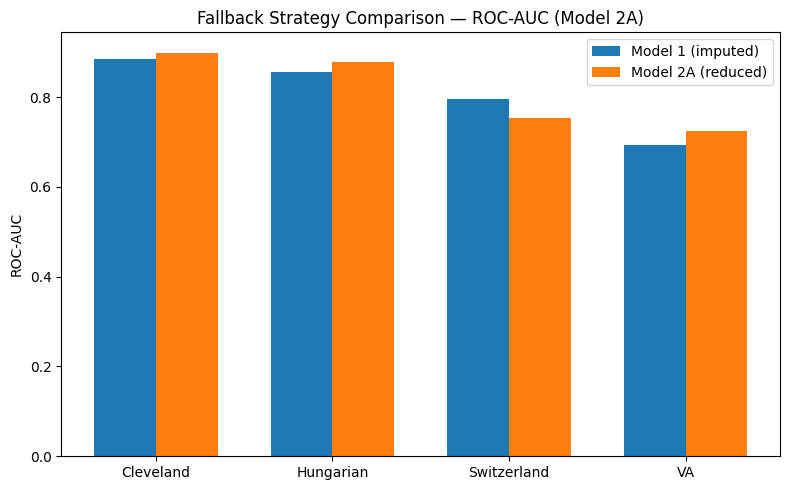

In [76]:
# Visualization: ROC-AUC comparison

plt.figure(figsize=(8, 5))

x = np.arange(len(comparison_clean_2a["dataset"]))
width = 0.35

plt.bar(x - width/2, comparison_clean_2a["roc_auc_model1_imputed"], width, label="Model 1 (imputed)")
plt.bar(x + width/2, comparison_clean_2a["roc_auc_model2a"], width, label="Model 2A (reduced)")

plt.xticks(x, comparison_clean_2a["dataset"])
plt.ylabel("ROC-AUC")
plt.title("Fallback Strategy Comparison — ROC-AUC (Model 2A)")
plt.legend()

plt.tight_layout()
plt.savefig("uci_plots/model2_fallback_comparison_roc-auc.png", bbox_inches="tight")
plt.show()

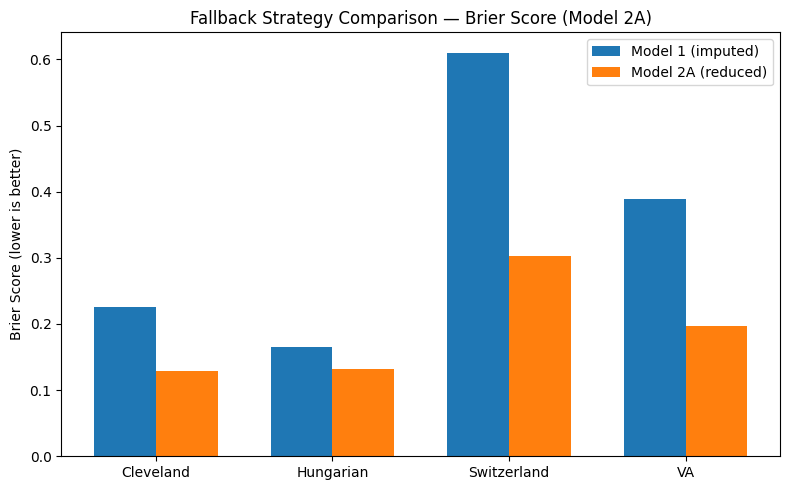

In [77]:
# Brier score comparison

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, comparison_clean_2a["brier_score_model1_imputed"], width, label="Model 1 (imputed)")
plt.bar(x + width/2, comparison_clean_2a["brier_score_model2a"], width, label="Model 2A (reduced)")

plt.xticks(x, comparison_clean_2a["dataset"])
plt.ylabel("Brier Score (lower is better)")
plt.title("Fallback Strategy Comparison — Brier Score (Model 2A)")
plt.legend()

plt.tight_layout()
plt.savefig("uci_plots/model2_fallback_comparison_brier_score.png", bbox_inches="tight")
plt.show()

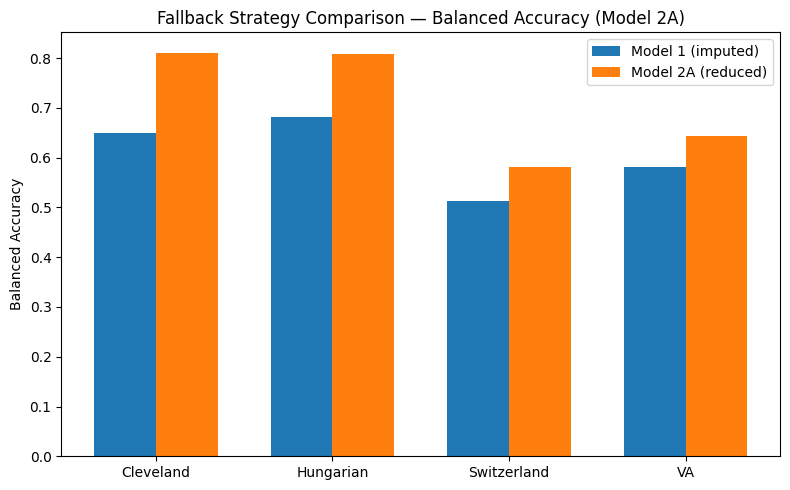

In [78]:
# Balanced accuracy

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, comparison_clean_2a["balanced_accuracy_model1_imputed"], width, label="Model 1 (imputed)")
plt.bar(x + width/2, comparison_clean_2a["balanced_accuracy_model2a"], width, label="Model 2A (reduced)")

plt.xticks(x, comparison_clean_2a["dataset"])
plt.ylabel("Balanced Accuracy")
plt.title("Fallback Strategy Comparison — Balanced Accuracy (Model 2A)")
plt.legend()

plt.tight_layout()
plt.savefig("uci_plots/model2_fallback_comparison_balanced_accuracy.png", bbox_inches="tight")
plt.show()

### Compare with Model 2B

In [79]:
# Align with Model 2B grouped results

reduced_results_model2_df = grouped_results_model2_df.copy()

# Keep only the columns we want for comparison
reduced_results_model2_df = reduced_results_model2_df.rename(columns={
    "test_dataset": "dataset",
    "roc_auc": "roc_auc_model2_reduced",
    "pr_auc": "pr_auc_model2_reduced",
    "accuracy": "accuracy_model2_reduced",
    "balanced_accuracy": "balanced_accuracy_model2_reduced",
    "precision": "precision_model2_reduced",
    "recall_sensitivity": "recall_model2_reduced",
    "specificity": "specificity_model2_reduced",
    "f1_score": "f1_model2_reduced",
    "brier_score": "brier_model2_reduced",
    "predicted_positive_rate": "predicted_positive_rate_model2_reduced"
})[
    [
        "dataset",
        "roc_auc_model2_reduced",
        "pr_auc_model2_reduced",
        "accuracy_model2_reduced",
        "balanced_accuracy_model2_reduced",
        "precision_model2_reduced",
        "recall_model2_reduced",
        "specificity_model2_reduced",
        "f1_model2_reduced",
        "brier_model2_reduced",
        "predicted_positive_rate_model2_reduced"
    ]
]

fallback_results_model1_df = fallback_results_model1_df.rename(columns={
    "roc_auc": "roc_auc_model1_imputed",
    "pr_auc": "pr_auc_model1_imputed",
    "accuracy": "accuracy_model1_imputed",
    "balanced_accuracy": "balanced_accuracy_model1_imputed",
    "precision": "precision_model1_imputed",
    "recall_sensitivity": "recall_model1_imputed",
    "specificity": "specificity_model1_imputed",
    "f1_score": "f1_model1_imputed",
    "brier_score": "brier_model1_imputed",
    "predicted_positive_rate": "predicted_positive_rate_model1_imputed"
})[
    [
        "dataset",
        "roc_auc_model1_imputed",
        "pr_auc_model1_imputed",
        "accuracy_model1_imputed",
        "balanced_accuracy_model1_imputed",
        "precision_model1_imputed",
        "recall_model1_imputed",
        "specificity_model1_imputed",
        "f1_model1_imputed",
        "brier_model1_imputed",
        "predicted_positive_rate_model1_imputed"
    ]
]

fallback_comparison_df = pd.merge(
    fallback_results_model1_df,
    reduced_results_model2_df,
    on="dataset",
    how="inner"
).round(4)

fallback_comparison_df

,dataset,roc_auc_model1_imputed,pr_auc_model1_imputed,accuracy_model1_imputed,balanced_accuracy_model1_imputed,precision_model1_imputed,recall_model1_imputed,specificity_model1_imputed,f1_model1_imputed,brier_model1_imputed,...,roc_auc_model2_reduced,pr_auc_model2_reduced,accuracy_model2_reduced,balanced_accuracy_model2_reduced,precision_model2_reduced,recall_model2_reduced,specificity_model2_reduced,f1_model2_reduced,brier_model2_reduced,predicted_positive_rate_model2_reduced
0,Cleveland,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,0.9878,0.4674,0.2261,...,0.8692,0.8594,0.8020,0.7979,0.8062,0.7482,0.8476,0.7761,0.1470,0.4257
1,Hungarian,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,0.9840,0.5369,0.1659,...,0.8726,0.8246,0.8129,0.7817,0.7802,0.6698,0.8936,0.7208,0.1329,0.3095
2,Switzerland,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,1.0000,0.0508,0.6104,...,0.7239,0.9704,0.6992,0.6647,0.9643,0.7043,0.6250,0.8141,0.1995,0.6829
3,VA,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,0.9216,0.3810,0.3891,...,0.7271,0.8753,0.7500,0.6517,0.8194,0.8523,0.4510,0.8355,0.1775,0.7750


In [80]:
# Add difference columns

fallback_comparison_df["delta_roc_auc"] = (
    fallback_comparison_df["roc_auc_model2_reduced"] -
    fallback_comparison_df["roc_auc_model1_imputed"]
).round(4)

fallback_comparison_df["delta_pr_auc"] = (
    fallback_comparison_df["pr_auc_model2_reduced"] -
    fallback_comparison_df["pr_auc_model1_imputed"]
).round(4)

fallback_comparison_df["delta_balanced_accuracy"] = (
    fallback_comparison_df["balanced_accuracy_model2_reduced"] -
    fallback_comparison_df["balanced_accuracy_model1_imputed"]
).round(4)

fallback_comparison_df["delta_brier_score"] = (
    fallback_comparison_df["brier_model2_reduced"] -
    fallback_comparison_df["brier_model1_imputed"]
).round(4)

fallback_comparison_df

,dataset,roc_auc_model1_imputed,pr_auc_model1_imputed,accuracy_model1_imputed,balanced_accuracy_model1_imputed,precision_model1_imputed,recall_model1_imputed,specificity_model1_imputed,f1_model1_imputed,brier_model1_imputed,...,precision_model2_reduced,recall_model2_reduced,specificity_model2_reduced,f1_model2_reduced,brier_model2_reduced,predicted_positive_rate_model2_reduced,delta_roc_auc,delta_pr_auc,delta_balanced_accuracy,delta_brier_score
0,Cleveland,0.8855,0.8757,0.6766,0.6486,0.9556,0.3094,0.9878,0.4674,0.2261,...,0.8062,0.7482,0.8476,0.7761,0.1470,0.4257,-0.0163,-0.0163,0.1493,-0.0791
1,Hungarian,0.8554,0.8186,0.7653,0.6807,0.9302,0.3774,0.9840,0.5369,0.1659,...,0.7802,0.6698,0.8936,0.7208,0.1329,0.3095,0.0172,0.0060,0.1010,-0.0330
2,Switzerland,0.7967,0.9838,0.0894,0.5130,1.0000,0.0261,1.0000,0.0508,0.6104,...,0.9643,0.7043,0.6250,0.8141,0.1995,0.6829,-0.0728,-0.0134,0.1517,-0.4109
3,VA,0.6931,0.8618,0.4150,0.5816,0.9000,0.2416,0.9216,0.3810,0.3891,...,0.8194,0.8523,0.4510,0.8355,0.1775,0.7750,0.0340,0.0135,0.0701,-0.2116


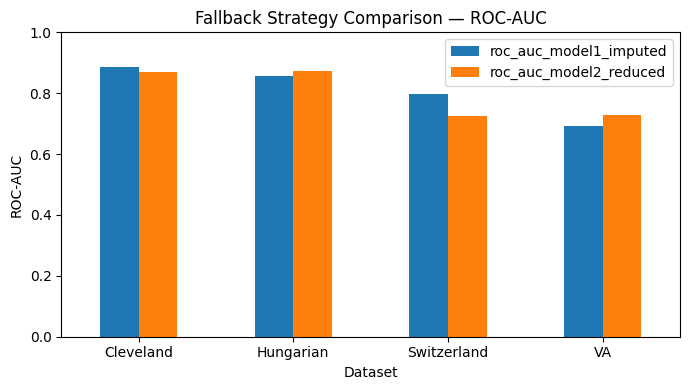

In [81]:
# Visualization: ROC-AUC comparison

plot_df = fallback_comparison_df.set_index("dataset")[
    ["roc_auc_model1_imputed", "roc_auc_model2_reduced"]
]

plot_df.plot(kind="bar", figsize=(7, 4))
plt.title("Fallback Strategy Comparison — ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("uci_plots/model2_fallback_comparison_roc-auc_model2b.png", bbox_inches="tight")
plt.show()

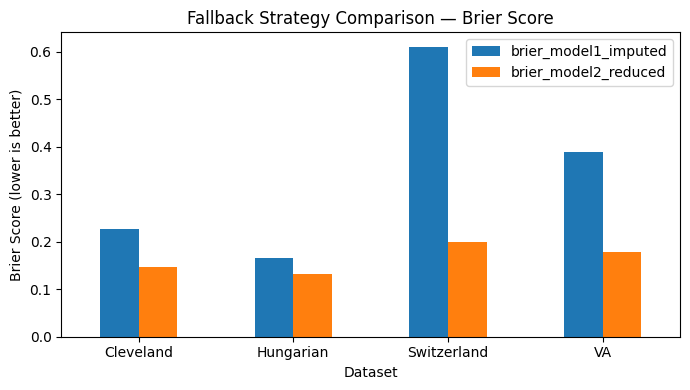

In [82]:
# Visualization: Brier score comparison

plot_df_brier = fallback_comparison_df.set_index("dataset")[
    ["brier_model1_imputed", "brier_model2_reduced"]
]

plot_df_brier.plot(kind="bar", figsize=(7, 4))
plt.title("Fallback Strategy Comparison — Brier Score")
plt.ylabel("Brier Score (lower is better)")
plt.xlabel("Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("uci_plots/model2_fallback_comparison_brier_score_model2b.png", bbox_inches="tight")
plt.show()

In [83]:
# Compact mean summary

fallback_mean_summary = pd.DataFrame({
    "Metric": [
        "Mean ROC-AUC",
        "Mean PR-AUC",
        "Mean Balanced Accuracy",
        "Mean F1 Score",
        "Mean Brier Score"
    ],
    "Model 1 Imputed Fallback": [
        fallback_comparison_df["roc_auc_model1_imputed"].mean(),
        fallback_comparison_df["pr_auc_model1_imputed"].mean(),
        fallback_comparison_df["balanced_accuracy_model1_imputed"].mean(),
        fallback_comparison_df["f1_model1_imputed"].mean(),
        fallback_comparison_df["brier_model1_imputed"].mean()
    ],
    "Model 2 Reduced Fallback": [
        fallback_comparison_df["roc_auc_model2_reduced"].mean(),
        fallback_comparison_df["pr_auc_model2_reduced"].mean(),
        fallback_comparison_df["balanced_accuracy_model2_reduced"].mean(),
        fallback_comparison_df["f1_model2_reduced"].mean(),
        fallback_comparison_df["brier_model2_reduced"].mean()
    ]
}).round(4)

fallback_mean_summary

,Metric,Model 1 Imputed Fallback,Model 2 Reduced Fallback
0,Mean ROC-AUC,0.8077,0.7982
1,Mean PR-AUC,0.8850,0.8824
2,Mean Balanced Accuracy,0.6060,0.7240
3,Mean F1 Score,0.3590,0.7866
4,Mean Brier Score,0.3479,0.1642


### Reduced model as a fallback strategy - Summary

The fallback comparison shows that using a **dedicated reduced-feature model is clearly preferable to imputing missing values into the full model**. Although the imputed full model sometimes retains similar ROC-AUC, its decision behavior is much worse: it becomes overly conservative, recall collapses, and calibration degrades sharply, especially on Switzerland and VA.

Both reduced-model variants outperform the imputed full model on the metrics that matter most for deployment. In particular, they achieve much higher **balanced accuracy**, **F1 score**, and much lower **Brier score**, indicating more reliable classification and probability estimates under incomplete-input conditions. This confirms that a separate reduced-feature model is not just a convenience, but a genuinely better fallback strategy.

Between the two reduced models, **Model 2A is selected as the final Model 2**. It consistently matches or outperforms Model 2B across datasets, with no clear downside, while preserving the same practical advantage over imputation.

**Final decision:**

* **Model 1** → use when full diagnostic inputs are available
* **Model 2A** → use as the fallback model when richer features are missing
* **Do not use imputation + Model 1 as the default fallback strategy**


## Understanding Model2 Behavior

In [84]:
# Extract coefficients and odds ratios from Model 2A

model2a_clf = logreg_model2_baseline.named_steps["classifier"]
model2a_feature_names = logreg_model2_baseline.named_steps["preprocessor"].get_feature_names_out()

coef_model2a_df = pd.DataFrame({
    "feature": model2a_feature_names,
    "coefficient": model2a_clf.coef_[0]
})

# Clean names
coef_model2a_df["feature"] = (
    coef_model2a_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_model2a_df["odds_ratio"] = np.exp(coef_model2a_df["coefficient"])
coef_model2a_df["abs_coefficient"] = coef_model2a_df["coefficient"].abs()

coef_model2a_df = coef_model2a_df.sort_values(by="coefficient", ascending=False)

coef_model2a_df.head(15)

,feature,coefficient,odds_ratio,abs_coefficient
10,cp_4.0,1.138044,3.120657,1.138044
6,sex_1.0,0.712816,2.039728,0.712816
4,oldpeak,0.569951,1.768180,0.569951
2,chol,0.251127,1.285474,0.251127
1,trestbps,0.247408,1.280701,0.247408
0,age,0.195144,1.215487,0.195144
13,restecg_2.0,0.179667,1.196819,0.179667
15,exang_1.0,0.149263,1.160978,0.149263
12,restecg_1.0,-0.193100,0.824399,0.193100
8,cp_2.0,-0.229542,0.794898,0.229542


In [85]:
# Create interpretation table

interpretation_model2a_df = coef_model2a_df.copy()

interpretation_model2a_df["direction"] = np.where(
    interpretation_model2a_df["coefficient"] > 0,
    "Higher predicted risk",
    "Lower predicted risk"
)

interpretation_model2a_df = interpretation_model2a_df[
    ["feature", "coefficient", "odds_ratio", "direction", "abs_coefficient"]
].sort_values(by="abs_coefficient", ascending=False)

interpretation_model2a_df.head(15)

,feature,coefficient,odds_ratio,direction,abs_coefficient
10,cp_4.0,1.138044,3.120657,Higher predicted risk,1.138044
5,sex_0.0,-1.035563,0.355026,Lower predicted risk,1.035563
6,sex_1.0,0.712816,2.039728,Higher predicted risk,0.712816
7,cp_1.0,-0.710865,0.491219,Lower predicted risk,0.710865
4,oldpeak,0.569951,1.768180,Higher predicted risk,0.569951
9,cp_3.0,-0.520383,0.594293,Lower predicted risk,0.520383
3,thalach,-0.485404,0.615449,Lower predicted risk,0.485404
14,exang_0.0,-0.472009,0.623748,Lower predicted risk,0.472009
11,restecg_0.0,-0.309314,0.733951,Lower predicted risk,0.309314
2,chol,0.251127,1.285474,Higher predicted risk,0.251127


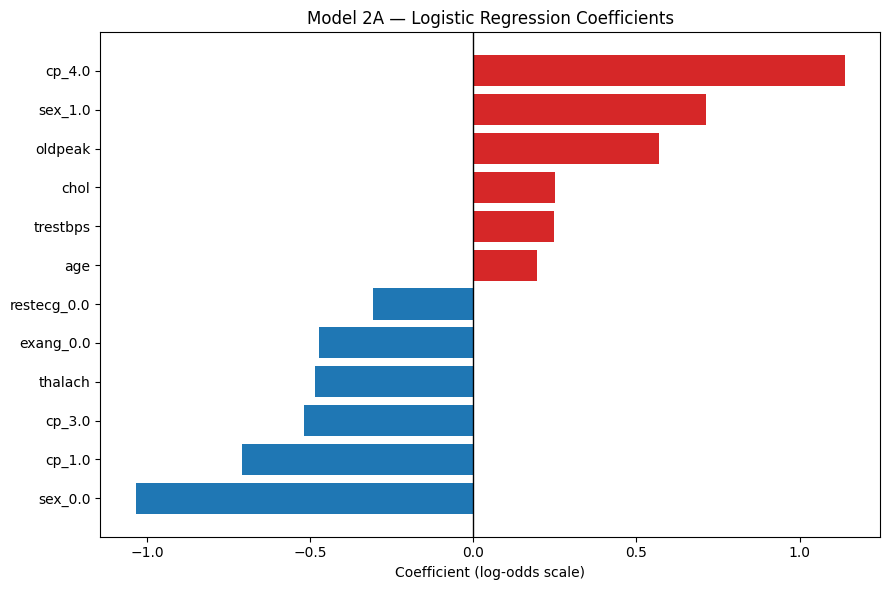

In [86]:
# Plot strongest positive and negative coefficients

top_n = 6

top_pos_model2a = coef_model2a_df.sort_values(by="coefficient", ascending=False).head(top_n)
top_neg_model2a = coef_model2a_df.sort_values(by="coefficient", ascending=True).head(top_n)

plot_model2a_df = pd.concat([top_pos_model2a, top_neg_model2a]).drop_duplicates()
plot_model2a_df = plot_model2a_df.sort_values(by="coefficient")

colors = ["#1f77b4" if x < 0 else "#d62728" for x in plot_model2a_df["coefficient"]]

plt.figure(figsize=(9, 6))
plt.barh(plot_model2a_df["feature"], plot_model2a_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)

plt.title("Model 2A — Logistic Regression Coefficients")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.savefig("uci_plots/model2_top_coefficients.png", bbox_inches="tight")
plt.show()

In [87]:
# Compare top features with Model 1

top_model1_features = set(
    coef_df.sort_values(by="abs_coefficient", ascending=False).head(10)["feature"]
)

top_model2a_features = set(
    coef_model2a_df.sort_values(by="abs_coefficient", ascending=False).head(10)["feature"]
)

shared_model1_model2a_features = sorted(top_model1_features.intersection(top_model2a_features))

feature_shift_summary = {
    "top_model1_features": sorted(top_model1_features),
    "top_model2a_features": sorted(top_model2a_features),
    "shared_features": shared_model1_model2a_features
}

feature_shift_summary

{'top_model1_features': ['ca_0.0',
  'ca_2.0',
  'cp_1.0',
  'cp_3.0',
  'cp_4.0',
  'sex_0.0',
  'sex_1.0',
  'slope_2.0',
  'thal_3.0',
  'thal_7.0'],
 'top_model2a_features': ['chol',
  'cp_1.0',
  'cp_3.0',
  'cp_4.0',
  'exang_0.0',
  'oldpeak',
  'restecg_0.0',
  'sex_0.0',
  'sex_1.0',
  'thalach'],
 'shared_features': ['cp_1.0', 'cp_3.0', 'cp_4.0', 'sex_0.0', 'sex_1.0']}

### Understanding Model 2A Behavior - Summary

Model 2A is primarily driven by **accessible clinical features**, with the strongest signal coming from

* **cp_4.0 (asymptomatic chest pain)** → strongly increases risk
* **sex_1.0 (male)** → higher predicted risk
* **oldpeak (ST depression during exercise)** → higher risk

Moderate contributions come from **chol (cholesterol)**, **trestbps (resting blood pressure)**, and **age**, indicating the model leans on general cardiovascular risk factors when advanced diagnostics are unavailable.

On the protective side, features like

* **thalach (max heart rate achieved)** and
* **exang_0.0 (no exercise-induced angina)**
  are associated with lower risk.

Compared to Model 1, Model 2A shifts away from specialized diagnostic features (e.g., `ca`, `thal`) and relies on broadly available inputs. The overlap is mainly in **cp (chest pain type)** and **sex**, suggesting these are robust predictors across settings.

Overall, Model 2A behaves as intended: a **clinically sensible, lower-information model** that substitutes missing diagnostics with general risk indicators rather than trying to approximate them.

---

## Finalizing Model 2: Hyperparameter Tuning, Threshold Selection, and Export

Model 2 has been selected as the reduced-feature fallback model for cases where the full diagnostic input required by Model 1 is unavailable. Before exporting the final artifact, we complete three steps:

1. tune the logistic regression hyperparameters on the Cleveland training split,
2. select an operating threshold on the Cleveland hold-out set,
3. retrain the final reduced-feature model on the full Cleveland dataset and save it together with metadata.

This preserves a clean evaluation logic: external datasets remain reserved for generalization analysis rather than model selection.

In [88]:
# 1. Hyperparameter tuning for final Model 2A

# Tuning helper and grid search

# Rebuild the reduced-feature preprocessor
preprocessor_model2_final = build_preprocessor(
    numerical_features=model2_numerical_features,
    categorical_features=model2_categorical_features
)

# Base pipeline
logreg_model2_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor_model2_final),
    ("classifier", LogisticRegression(
        solver="liblinear",
        max_iter=1000
    ))
])

# Small, focused hyperparameter grid
param_grid_model2 = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}

cv_model2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_model2 = GridSearchCV(
    estimator=logreg_model2_tuning,
    param_grid=param_grid_model2,
    scoring="roc_auc",
    cv=cv_model2,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

grid_model2.fit(X_train_m2, y_train_m2)

print("Best parameters:", grid_model2.best_params_)
print("Best CV ROC-AUC:", round(grid_model2.best_score_, 4))

Best parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced'}
Best CV ROC-AUC: 0.8625


In [89]:
# Tuning results summary

tuning_results_model2 = pd.DataFrame(grid_model2.cv_results_)[
    [
        "param_classifier__C",
        "param_classifier__class_weight",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].copy()

tuning_results_model2 = tuning_results_model2.rename(columns={
    "param_classifier__C": "C",
    "param_classifier__class_weight": "class_weight",
    "mean_test_score": "mean_cv_roc_auc",
    "std_test_score": "std_cv_roc_auc",
    "rank_test_score": "rank"
}).sort_values(["rank", "C"])

tuning_results_model2.round(4)

,C,class_weight,mean_cv_roc_auc,std_cv_roc_auc,rank
5,1.00,balanced,0.8625,0.0381,1
4,1.00,NaN,0.8625,0.0362,2
6,10.00,NaN,0.8608,0.0364,3
8,100.00,NaN,0.8602,0.0366,4
7,10.00,balanced,0.8598,0.0373,5
9,100.00,balanced,0.8591,0.0381,6
3,0.10,balanced,0.8577,0.0414,7
2,0.10,NaN,0.8567,0.0411,8
0,0.01,NaN,0.8405,0.0430,9
1,0.01,balanced,0.8401,0.0429,10


### Threshold selection for final Model 2A

After choosing the final logistic regression hyperparameters, we select a classification threshold using the Cleveland hold-out set. The threshold is chosen to maximize **balanced accuracy**, which is more appropriate than plain accuracy under class imbalance.

In [90]:
# 2. Threshold selection on Cleveland hold-out


def compute_threshold_metrics(y_true, y_proba, thresholds):
    rows = []

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = recall_score(y_true, y_pred, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        rows.append({
            "threshold": thr,
            "balanced_accuracy": bal_acc,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "f1_score": f1,
            "predicted_positive_rate": y_pred.mean(),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    return pd.DataFrame(rows)

In [91]:
# Choose threshold

# Best tuned pipeline
best_model2_pipeline = grid_model2.best_estimator_

# Probabilities on the Cleveland hold-out set
y_proba_holdout_m2 = best_model2_pipeline.predict_proba(X_test_m2)[:, 1]

# Evaluate candidate thresholds
threshold_grid_model2 = np.round(np.arange(0.10, 0.91, 0.01), 2)

threshold_results_model2 = compute_threshold_metrics(
    y_true=y_test_m2,
    y_proba=y_proba_holdout_m2,
    thresholds=threshold_grid_model2
)

threshold_results_model2 = threshold_results_model2.sort_values(
    ["balanced_accuracy", "f1_score", "specificity"],
    ascending=False
).reset_index(drop=True)

threshold_results_model2.head(10).round(4)

,threshold,balanced_accuracy,sensitivity,specificity,precision,f1_score,predicted_positive_rate,tn,fp,fn,tp
0,0.47,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
1,0.48,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
2,0.49,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
3,0.50,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
4,0.51,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
5,0.52,0.9215,0.9643,0.8788,0.8710,0.9153,0.5082,29,4,1,27
6,0.45,0.9064,0.9643,0.8485,0.8438,0.9000,0.5246,28,5,1,27
7,0.46,0.9064,0.9643,0.8485,0.8438,0.9000,0.5246,28,5,1,27
8,0.55,0.9010,0.8929,0.9091,0.8929,0.8929,0.4590,30,3,3,25
9,0.56,0.9010,0.8929,0.9091,0.8929,0.8929,0.4590,30,3,3,25


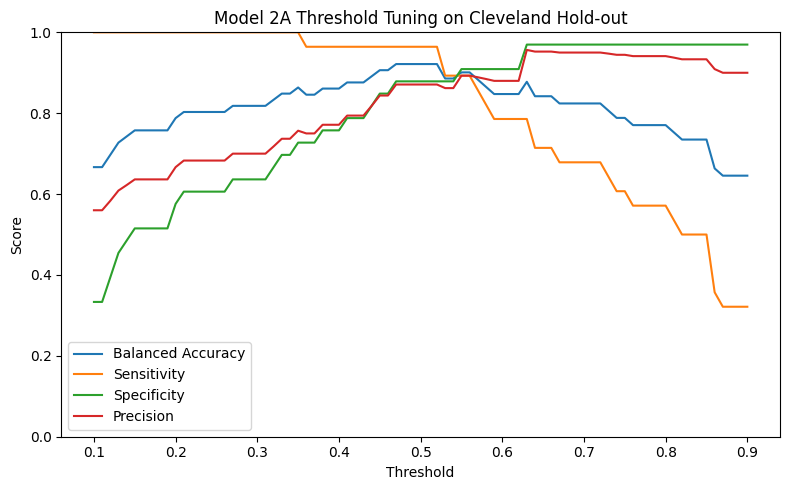

In [92]:
# Visualize threshold trade-offs

plot_df = threshold_results_model2.sort_values("threshold")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["threshold"], plot_df["balanced_accuracy"], label="Balanced Accuracy")
plt.plot(plot_df["threshold"], plot_df["sensitivity"], label="Sensitivity")
plt.plot(plot_df["threshold"], plot_df["specificity"], label="Specificity")
plt.plot(plot_df["threshold"], plot_df["precision"], label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Model 2A Threshold Tuning on Cleveland Hold-out")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("uci_plots/model2_threshold_tuning.png", bbox_inches="tight")
plt.show()

In [93]:
# Select final threshold = one that maximizes balanced accuracy
best_threshold_row_model2 = threshold_results_model2.iloc[0]
final_model2_threshold = float(best_threshold_row_model2["threshold"])

print("Selected threshold:", final_model2_threshold)
print("\nThreshold summary:")
display(best_threshold_row_model2.to_frame().T.round(4))

# Hold-out predictions at tuned threshold
y_pred_holdout_m2 = (y_proba_holdout_m2 >= final_model2_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_m2, y_pred_holdout_m2).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

final_holdout_results_model2 = {
    "roc_auc": roc_auc_score(y_test_m2, y_proba_holdout_m2),
    "pr_auc": average_precision_score(y_test_m2, y_proba_holdout_m2),
    "accuracy": accuracy_score(y_test_m2, y_pred_holdout_m2),
    "balanced_accuracy": balanced_accuracy_score(y_test_m2, y_pred_holdout_m2),
    "precision": precision_score(y_test_m2, y_pred_holdout_m2, zero_division=0),
    "recall_sensitivity": recall_score(y_test_m2, y_pred_holdout_m2, zero_division=0),
    "specificity": specificity,
    "f1_score": f1_score(y_test_m2, y_pred_holdout_m2, zero_division=0),
    "brier_score": brier_score_loss(y_test_m2, y_proba_holdout_m2),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

pd.DataFrame([final_holdout_results_model2]).round(4)

Selected threshold: 0.47

Threshold summary:


,threshold,balanced_accuracy,sensitivity,specificity,precision,f1_score,predicted_positive_rate,tn,fp,fn,tp
0,0.47,0.9215,0.9643,0.8788,0.871,0.9153,0.5082,29.0,4.0,1.0,27.0


,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1_score,brier_score,tn,fp,fn,tp
0,0.9556,0.9337,0.918,0.9215,0.871,0.9643,0.8788,0.9153,0.0941,29,4,1,27


### Final training and export

The selected Model 2A configuration is now retrained on the full Cleveland reduced-feature dataset and saved together with the tuned threshold and metadata. External datasets remain untouched during model selection and are retained as evidence of cross-dataset generalization.

In this section, we save Model 2 using the same export structure as Model 1.

As before, we save three files:

- the `.joblib` file contains the runtime artifact needed for prediction;
- the `.metadata.json` file contains model documentation, validation details, performance summaries, and limitations;
- the `.schema.json` file defines the expected input fields and valid values for API validation.

In [94]:
# 3. Final Model 2A training on full Cleveland data


# Rebuild final pipeline with selected hyperparameters
final_model2_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor(
        numerical_features=model2_numerical_features,
        categorical_features=model2_categorical_features
    )),
    ("classifier", LogisticRegression(
        C=grid_model2.best_params_["classifier__C"],
        class_weight=grid_model2.best_params_["classifier__class_weight"],
        solver="liblinear",
        max_iter=1000
    ))
])

# Train on full Cleveland reduced-feature dataset
final_model2_pipeline.fit(X_cleveland, y_cleveland)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [95]:
# Model 2 schema

model2_schema = {
    "schema_version": "1.0.0",
    "description": (
        "Input schema for Model 2, the reduced-feature current heart disease "
        "diagnostic-support model."
    ),
    "features": {
        "age": {
            "type": "number",
            "required": True,
            "minimum": 18,
            "maximum": 100,
            "unit": "years",
            "description": "Age in years."
        },
        "trestbps": {
            "type": "number",
            "required": True,
            "minimum": 70,
            "maximum": 250,
            "unit": "mm Hg",
            "description": "Resting blood pressure."
        },
        "chol": {
            "type": "number",
            "required": True,
            "minimum": 80,
            "maximum": 700,
            "unit": "mg/dL",
            "description": "Serum cholesterol."
        },
        "restecg": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1, 2],
            "value_mapping": {
                "0": "normal",
                "1": "ST-T wave abnormality",
                "2": "probable or definite left ventricular hypertrophy"
            },
            "description": "Resting electrocardiographic results."
        },
        "thalach": {
            "type": "number",
            "required": True,
            "minimum": 60,
            "maximum": 230,
            "description": "Maximum heart rate achieved."
        },
        "oldpeak": {
            "type": "number",
            "required": True,
            "minimum": 0,
            "maximum": 10,
            "description": "ST depression induced by exercise relative to rest."
        },
        "sex": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "female",
                "1": "male"
            },
            "description": "Biological sex as encoded in the UCI dataset."
        },
        "cp": {
            "type": "integer",
            "required": True,
            "allowed_values": [1, 2, 3, 4],
            "value_mapping": {
                "1": "typical angina",
                "2": "atypical angina",
                "3": "non-anginal pain",
                "4": "asymptomatic"
            },
            "description": "Chest pain type."
        },
        "exang": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "no exercise-induced angina",
                "1": "exercise-induced angina"
            },
            "description": "Exercise-induced angina."
        }
    },
    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },
    "notes": [
        "This model uses a reduced clinical feature set.",
        "It excludes richer full-model variables such as ca, thal, fbs, and slope.",
        "It is intended as a fallback or reduced-input diagnostic-support model.",
        "This model predicts current heart disease pattern, not 10-year CHD risk."
    ]
}

In [96]:
# Model 2 metadata

model2_performance_summary = {
    "mean_roc_auc": float(baseline_results_df["roc_auc"].mean()),
    "mean_pr_auc": float(baseline_results_df["pr_auc"].mean()),
    "mean_accuracy": float(baseline_results_df["accuracy"].mean()),
    "mean_balanced_accuracy": float(baseline_results_df["balanced_accuracy"].mean()),
    "mean_precision": float(baseline_results_df["precision"].mean()),
    "mean_recall_sensitivity": float(baseline_results_df["recall_sensitivity"].mean()),
    "mean_specificity": float(baseline_results_df["specificity"].mean()),
    "mean_f1": float(baseline_results_df["f1_score"].mean()),
    "mean_brier_score": float(baseline_results_df["brier_score"].mean())
}

model2_fallback_summary = {
    "comparison": (
        "Model 2 reduced-feature fallback compared with Model 1 full model "
        "when richer features are unavailable and imputed."
    ),
    "mean_roc_auc_model1_imputed": float(comparison_clean_2a["roc_auc_model1_imputed"].mean()),
    "mean_roc_auc_model2a": float(comparison_clean_2a["roc_auc_model2a"].mean()),
    "mean_brier_model1_imputed": float(comparison_clean_2a["brier_score_model1_imputed"].mean()),
    "mean_brier_model2a": float(comparison_clean_2a["brier_score_model2a"].mean()),
    "mean_balanced_accuracy_model1_imputed": float(
        comparison_clean_2a["balanced_accuracy_model1_imputed"].mean()
    ),
    "mean_balanced_accuracy_model2a": float(
        comparison_clean_2a["balanced_accuracy_model2a"].mean()
    )
}

model2_metadata = {
    "algorithm": "LogisticRegression",

    "intended_use": (
        "Reduced-feature current heart disease diagnostic-support model for cases "
        "where the full clinical feature set is unavailable."
    ),

    "not_for": [
        "10-year CHD risk estimation",
        "standalone clinical diagnosis",
        "emergency decision-making"
    ],

    "training_dataset": "Cleveland",
    "external_validation_datasets": ["Hungarian", "Switzerland", "VA"],

    "validation_strategy": {
        "summary": (
            "Hyperparameter tuning by 5-fold stratified cross-validation on the "
            "Cleveland training split, final refit on the full Cleveland dataset, "
            "and external evaluation on Hungarian, Switzerland, and VA."
        ),
        "threshold_selection_dataset": "Cleveland hold-out",
        "threshold_selection_policy": "Maximize balanced accuracy.",
        "primary_tuning_metric": "ROC-AUC",
        "best_cv_roc_auc": float(grid_model2.best_score_)
    },

    "features": {
        "all": list(model2_features),
        "numerical": list(model2_numerical_features),
        "categorical": list(model2_categorical_features)
    },

    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },

    "selected_hyperparameters": {
        "C": grid_model2.best_params_["classifier__C"],
        "class_weight": grid_model2.best_params_["classifier__class_weight"],
        "solver": "liblinear",
        "max_iter": 1000
    },

    "thresholding": {
        "selected_threshold": float(final_model2_threshold),
        "threshold_policy": "Selected on Cleveland hold-out by maximizing balanced accuracy.",
        "threshold_selection_set": "Cleveland hold-out",
        "holdout_metrics_at_selected_threshold": final_holdout_results_model2
    },

    "performance": {
        "external_validation_summary": model2_performance_summary,
        "fallback_comparison_summary": model2_fallback_summary,
        "external_validation_records": baseline_results_df.to_dict(orient="records")
    },

    "limitations": [
        "This model was trained only on the Cleveland dataset.",
        "Threshold selection was performed on a Cleveland hold-out set.",
        "External performance should be interpreted separately for Hungarian, Switzerland, and VA.",
        "This model removes richer clinical variables but still requires several clinical and exercise-test inputs.",
        "The predicted score should not be interpreted as a calibrated real-world diagnostic probability without further validation."
    ]
}

In [97]:
# 4. Export Model 2


MODEL2_ID = "model2_reduced_clinical_v1"

MODEL2_DISPLAY_NAME = "Model 2 - Reduced Clinical Logistic Regression"

MODEL2_ROLE = "reduced-feature current heart disease diagnostic-support model"

MODEL2_THRESHOLD = float(final_model2_threshold)

MODEL2_THRESHOLD_POLICY = "Selected on Cleveland hold-out by maximizing balanced accuracy."

MODEL2_FEATURE_ORDER = list(model2_features)


model2_export_paths = export_model_artifacts(
    model_id=MODEL2_ID,
    model_display_name=MODEL2_DISPLAY_NAME,
    model_role=MODEL2_ROLE,
    pipeline=final_model2_pipeline,
    threshold=MODEL2_THRESHOLD,
    threshold_policy=MODEL2_THRESHOLD_POLICY,
    feature_order=MODEL2_FEATURE_ORDER,
    numerical_features=model2_numerical_features,
    categorical_features=model2_categorical_features,
    metadata=model2_metadata,
    schema=model2_schema,
    artifact_dir="artifacts",
    artifact_version="1.0.0",
)

model2_export_paths

{'artifact_path': 'artifacts/model2_reduced_clinical_v1.joblib',
 'metadata_path': 'artifacts/model2_reduced_clinical_v1.metadata.json',
 'schema_path': 'artifacts/model2_reduced_clinical_v1.schema.json'}

In [98]:
# 5. Verification step

# Load standardized Model 2 artifact
loaded_artifact = joblib.load("artifacts/model2_reduced_clinical_v1.joblib")

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]
loaded_feature_order = loaded_artifact["feature_order"]

# Verify feature order using Switzerland prepared data, as in the original notebook
X_verify = switzerland_prepared[loaded_feature_order].iloc[:5]

sample_proba = loaded_pipeline.predict_proba(X_verify)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

print("Model ID:", loaded_artifact["model_id"])
print("Display name:", loaded_artifact["model_display_name"])
print("Threshold:", loaded_threshold)
print("Feature order matches input:", list(X_verify.columns) == loaded_feature_order)
print("Probabilities:", sample_proba)
print("Predictions:", sample_pred)

Model ID: model2_reduced_clinical_v1
Display name: Model 2 - Reduced Clinical Logistic Regression
Threshold: 0.47
Feature order matches input: True
Probabilities: [0.05276932 0.17970181 0.61254946 0.59794559 0.11623111]
Predictions: [0 0 1 1 0]


# Model 3

### Model 3 — Minimal Input Risk Model

Model 3 is a **lightweight, low-feature version** of your classifier designed for situations where only **basic, easily obtainable patient data** is available.

* **Purpose:** enable quick, accessible risk estimation (e.g., primary care, screening, or low-resource settings)
* **Features:** only a **small subset of universally available variables** (e.g., age, sex, simple symptoms like chest pain)
* **Trade-off:** lower predictive performance than Models 1 and 2, but **maximum usability and portability**
* **Design goal:** prioritize **simplicity, robustness, and ease of deployment** over accuracy

In short:

* **Model 1 = best performance (full clinical data)**
* **Model 2 = balanced & generalizable**
* **Model 3 = simplest & most deployable**

---

## Feature selection rationale

Model 3 is designed as a minimal-input risk model, prioritizing features that are widely available, easy to obtain, and clinically meaningful. The selected feature set (`age`, `sex`, `cp`, `exang`, `trestbps`, `thalach`) balances simplicity with predictive signal.

Demographic variables (`age`, `sex`) are included as universally available baseline risk factors. Symptom-related features (`cp`, `exang`) provide strong clinical signal without requiring advanced testing. Basic physiological measurements (`trestbps`, `thalach`) are routinely collected and add additional predictive value, with maximum heart rate (`thalach`) being particularly informative.

More complex or less portable features (e.g., `ca`, `thal`, `oldpeak`) were excluded because they require specialized testing or are not consistently available across datasets. Other variables such as `chol` and `fbs` were excluded due to data quality concerns or weak and inconsistent signal in this setting.

Overall, the selected feature set aims to retain the core predictive information while maximizing portability and ease of use, making Model 3 suitable for lightweight screening scenarios.

In [99]:
datasets = {
    "cleveland": df_cleveland,
    "hungarian": df_hungarian,
    "switzerland": df_switzerland,
    "va": df_va
}

In [100]:
# Define Model 3 feature set

model3_features = ["age", "sex", "cp", "exang", "trestbps", "thalach"]

In [101]:
# Check that all selected features exist in all datasets

for name, df in datasets.items():
    missing_cols = [col for col in model3_features if col not in df.columns]
    print(f"{name}: missing columns -> {missing_cols if missing_cols else 'none'}")

cleveland: missing columns -> none
hungarian: missing columns -> none
switzerland: missing columns -> none
va: missing columns -> none


In [102]:
# Missingness summary for selected features

missingness_rows = []

for name, df in datasets.items():
    row = {"dataset": name}
    for col in model3_features:
        row[col] = df[col].isna().mean()
    missingness_rows.append(row)

missingness_summary = pd.DataFrame(missingness_rows).set_index("dataset")
missingness_summary

,age,sex,cp,exang,trestbps,thalach
dataset,,,,,,
cleveland,0.0,0.0,0.0,0.000000,0.000000,0.000000
hungarian,0.0,0.0,0.0,0.003401,0.003401,0.003401
switzerland,0.0,0.0,0.0,0.008130,0.016260,0.008130
va,0.0,0.0,0.0,0.265000,0.280000,0.265000


Despite some dataset-specific missingness—particularly in the VA cohort—the overall availability and stability of these features support their use in a minimal-input model, and we proceed with model development on this basis.

## Model 3 EDA

In [103]:
# Basic sample size and target balance for Model 3 subset

summary_rows = []

for name, df in datasets.items():
    subset = df[model3_features + ["num"]].copy()
    row = {
        "dataset": name,
        "n_total": len(subset),
        "target_rate": subset["num"].mean(),
        "complete_case_n": subset.dropna().shape[0],
        "complete_case_pct": subset.dropna().shape[0] / len(subset)
    }
    summary_rows.append(row)

model3_dataset_summary = pd.DataFrame(summary_rows).set_index("dataset")
model3_dataset_summary

,n_total,target_rate,complete_case_n,complete_case_pct
dataset,,,,
cleveland,303,0.937294,303,1.000000
hungarian,294,0.360544,293,0.996599
switzerland,123,1.804878,121,0.983740
va,200,1.520000,144,0.720000


In [104]:
# Sanity checks for invalid numeric values

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("trestbps <= 0:", (df["trestbps"] <= 0).sum())
    print("thalach <= 0:", (df["thalach"] <= 0).sum())
    print("age <= 0:", (df["age"] <= 0).sum())


CLEVELAND
trestbps <= 0: 0
thalach <= 0: 0
age <= 0: 0

HUNGARIAN
trestbps <= 0: 0
thalach <= 0: 0
age <= 0: 0

SWITZERLAND
trestbps <= 0: 0
thalach <= 0: 0
age <= 0: 0

VA
trestbps <= 0: 1
thalach <= 0: 0
age <= 0: 0


The Model 3 subset retains adequate sample sizes across datasets, but exhibits substantial variation in target prevalence and data completeness. Cleveland and Hungarian cohorts remain well-formed, while the VA dataset shows notable missingness and higher prevalence, indicating potential challenges for generalization and the need for careful validation.

---

### Feature Distribution

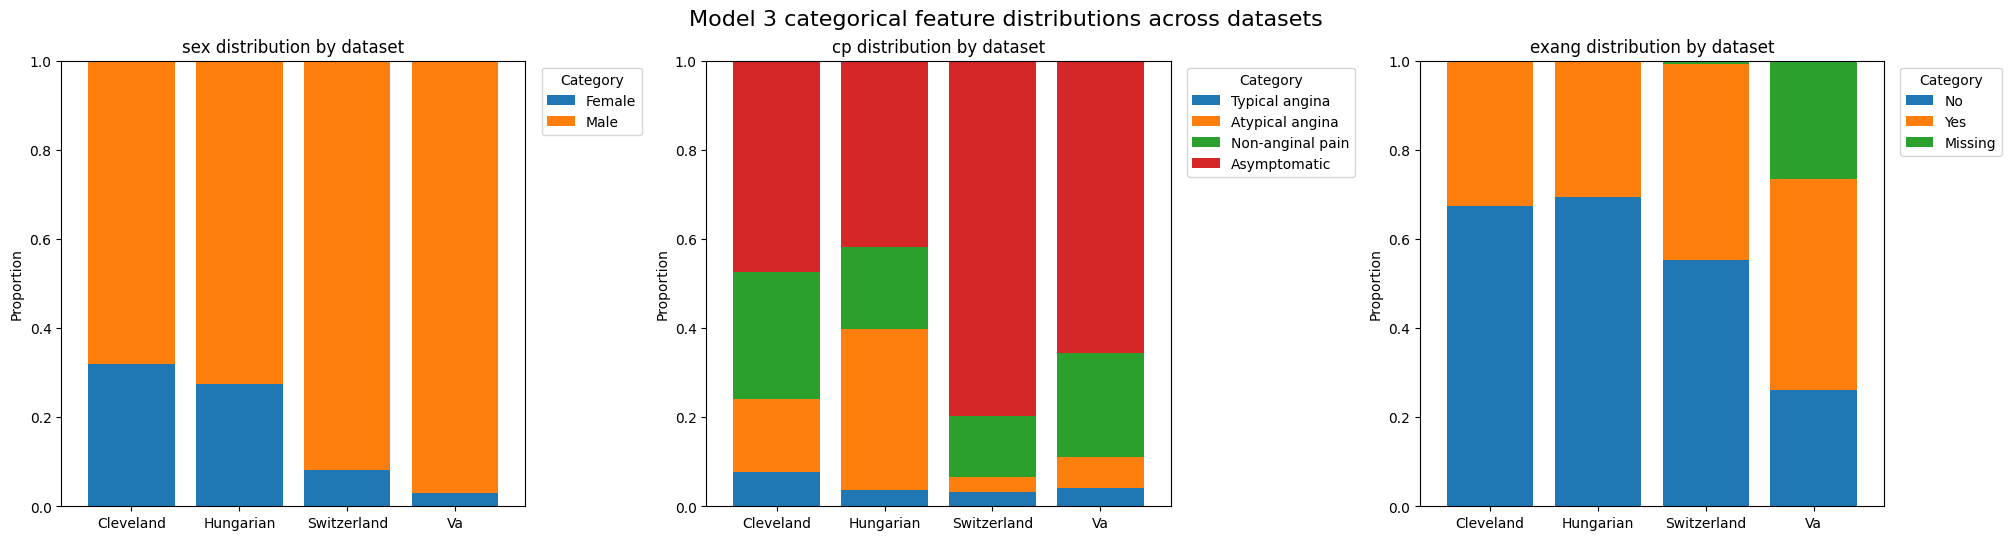

In [105]:
# Category distribution plots for Model 3 categorical features

categorical_features = ["sex", "cp", "exang"]

# Optional readable labels
category_labels = {
    "sex": {
        0: "Female",
        1: "Male"
    },
    "cp": {
        1: "Typical angina",
        2: "Atypical angina",
        3: "Non-anginal pain",
        4: "Asymptomatic"
    },
    "exang": {
        0: "No",
        1: "Yes"
    }
}

# Fixed dataset order for consistency
dataset_order = ["cleveland", "hungarian", "switzerland", "va"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5), constrained_layout=True)

for ax, col in zip(axes, categorical_features):
    plot_rows = []

    for dataset_name in dataset_order:
        df = datasets[dataset_name].copy()

        # Keep missing values explicit for plotting
        values = df[col].copy()
        values = values.where(values.notna(), "Missing")

        # Convert labels where available
        mapped_values = values.map(category_labels.get(col, {})).fillna(values)

        # Proportion table
        prop = (
            mapped_values
            .value_counts(normalize=True, dropna=False)
            .rename_axis("category")
            .reset_index(name="proportion")
        )
        prop["dataset"] = dataset_name.capitalize()
        plot_rows.append(prop)

    plot_df = pd.concat(plot_rows, ignore_index=True)

    # Consistent category ordering
    categories = list(category_labels.get(col, {}).values())
    if "Missing" in plot_df["category"].values:
        categories = categories + ["Missing"]

    pivot_df = (
        plot_df
        .pivot(index="dataset", columns="category", values="proportion")
        .reindex([d.capitalize() for d in dataset_order])
    )

    # Ensure all expected columns exist
    for category in categories:
        if category not in pivot_df.columns:
            pivot_df[category] = 0.0

    pivot_df = pivot_df[categories]

    pivot_df.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(f"{col} distribution by dataset", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.set_ylim(0, 1)
    ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Model 3 categorical feature distributions across datasets", fontsize=16, y=1.05)
plt.savefig("uci_plots/model3_categorical_feature_distribution_across_datasets.png", bbox_inches="tight")
plt.show()

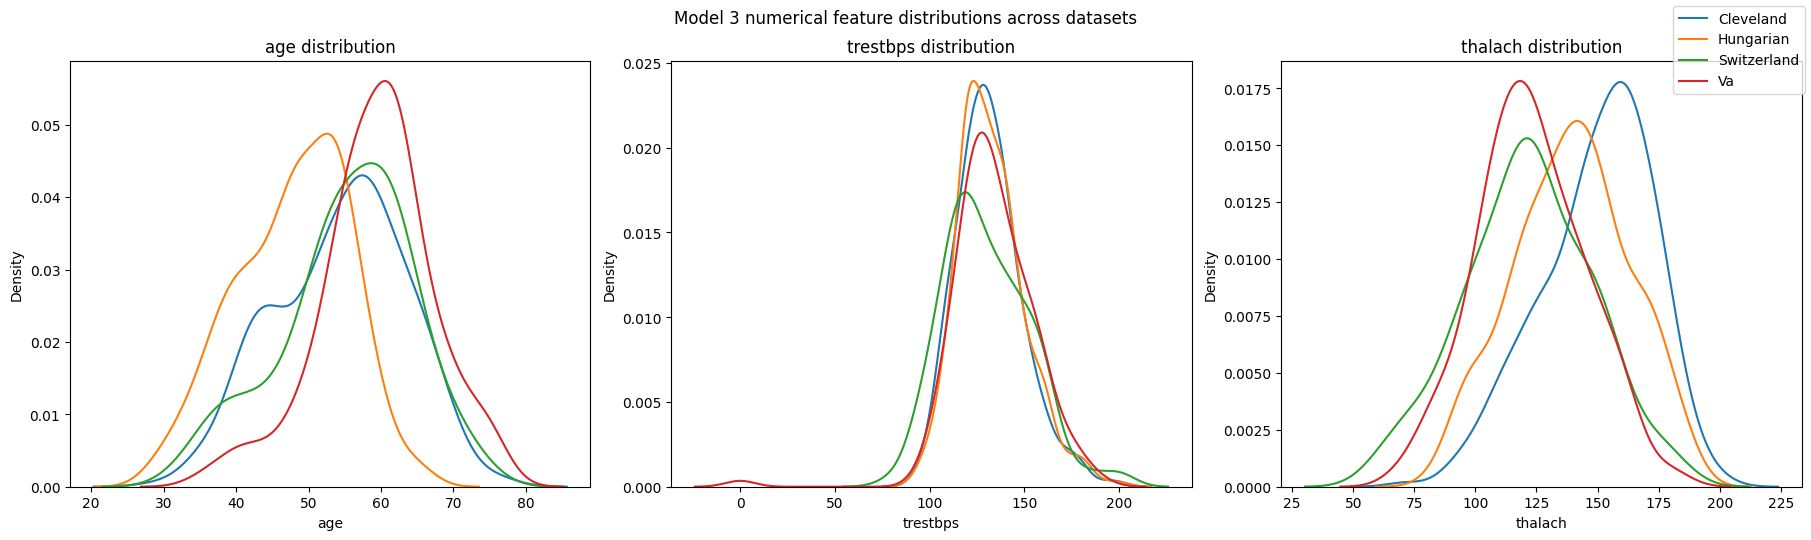

In [106]:
# Numerical distributions across datasets

numerical_features = ["age", "trestbps", "thalach"]
dataset_order = ["cleveland", "hungarian", "switzerland", "va"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, feature in zip(axes, numerical_features):
    for name in dataset_order:
        df = datasets[name]

        sns.kdeplot(
            data=df,
            x=feature,
            label=name.capitalize(),
            fill=False,
            common_norm=False,
            ax=ax
        )

    ax.set_title(f"{feature} distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

# Single legend (cleaner)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("Model 3 numerical feature distributions across datasets", y=1.05)
plt.savefig("uci_plots/model3_numerical_feature_distribution_across_datasets.png", bbox_inches="tight")
plt.show()

Feature distributions differ substantially across datasets, indicating clear covariate shift. The Switzerland and VA cohorts are heavily male-dominated and show a strong concentration of asymptomatic chest pain, unlike the more heterogeneous Cleveland data. Exercise-induced angina is also affected by significant missingness in the VA dataset. While age remains relatively stable, physiological measures such as resting blood pressure and maximum heart rate vary more noticeably. These differences suggest that models trained on a single dataset may not generalize reliably, underscoring the importance of cross-dataset evaluation for Model 3.

---

### Feature-Target Relationships Across Datasets

In [107]:
for df in datasets.values():
    df["target"] = (df["num"] > 0).astype(int)

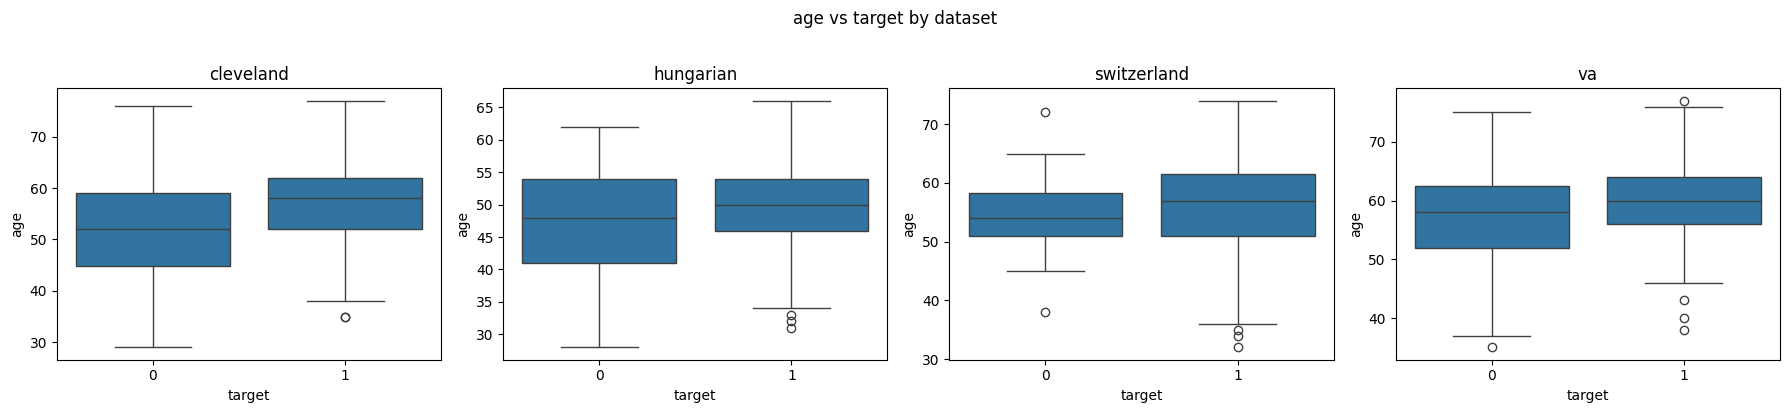

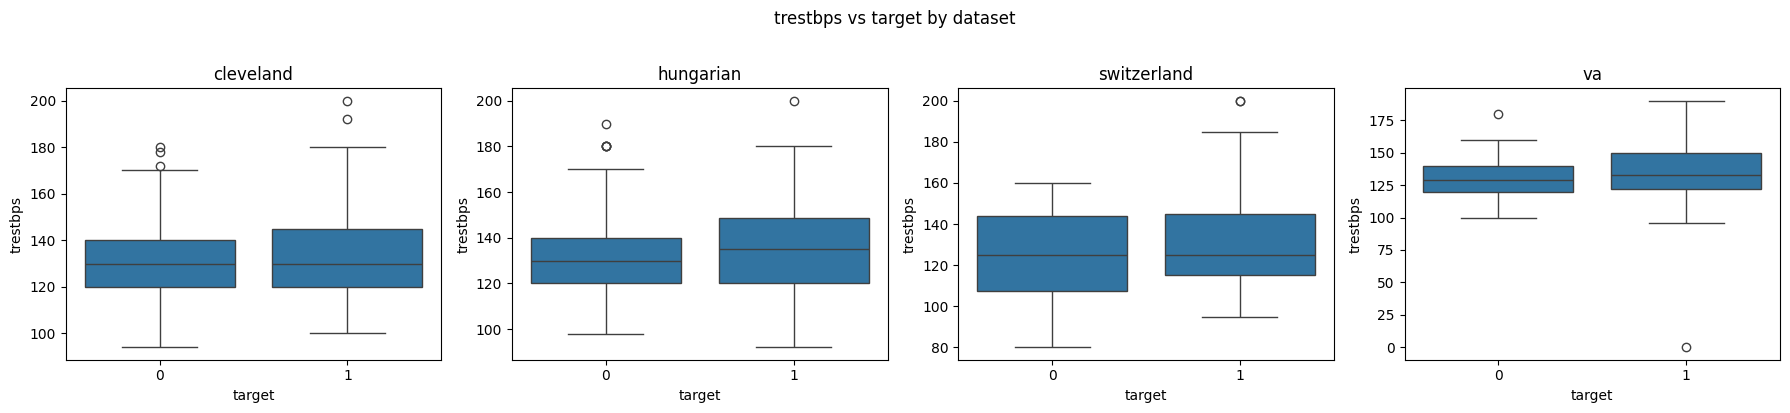

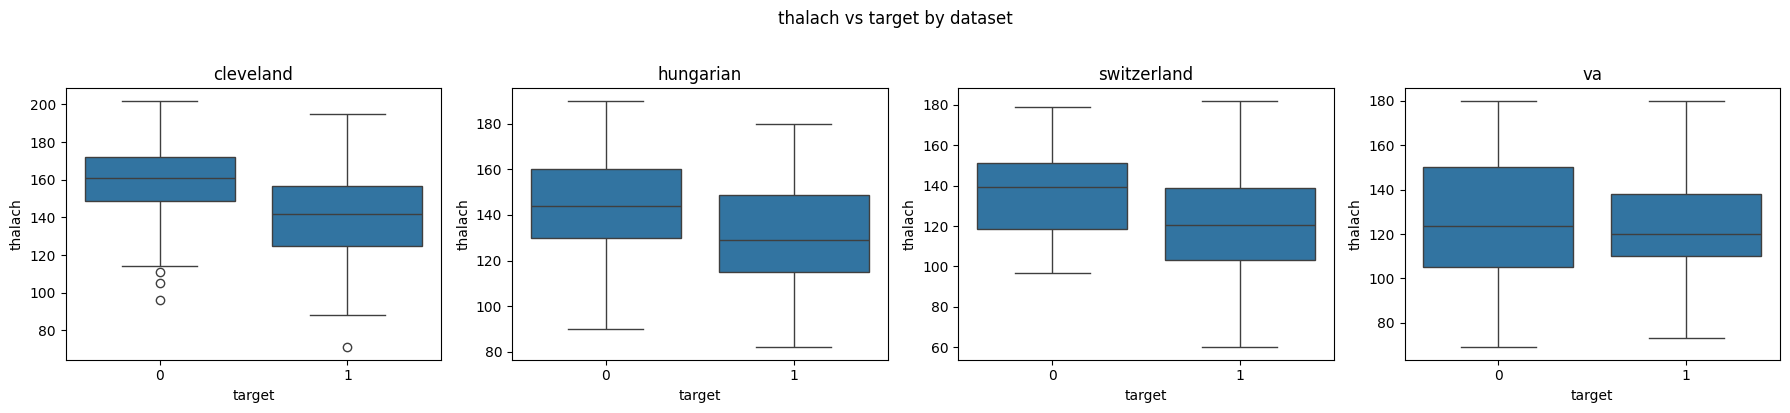

In [108]:
# Numerical features vs target within each dataset

for feature in ["age", "trestbps", "thalach"]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
    
    for ax, (name, df) in zip(axes, datasets.items()):
        sns.boxplot(data=df, x="target", y=feature, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("target")
        ax.set_ylabel(feature)
    
    plt.suptitle(f"{feature} vs target by dataset", y=1.02)
    plt.tight_layout()
    plt.show()

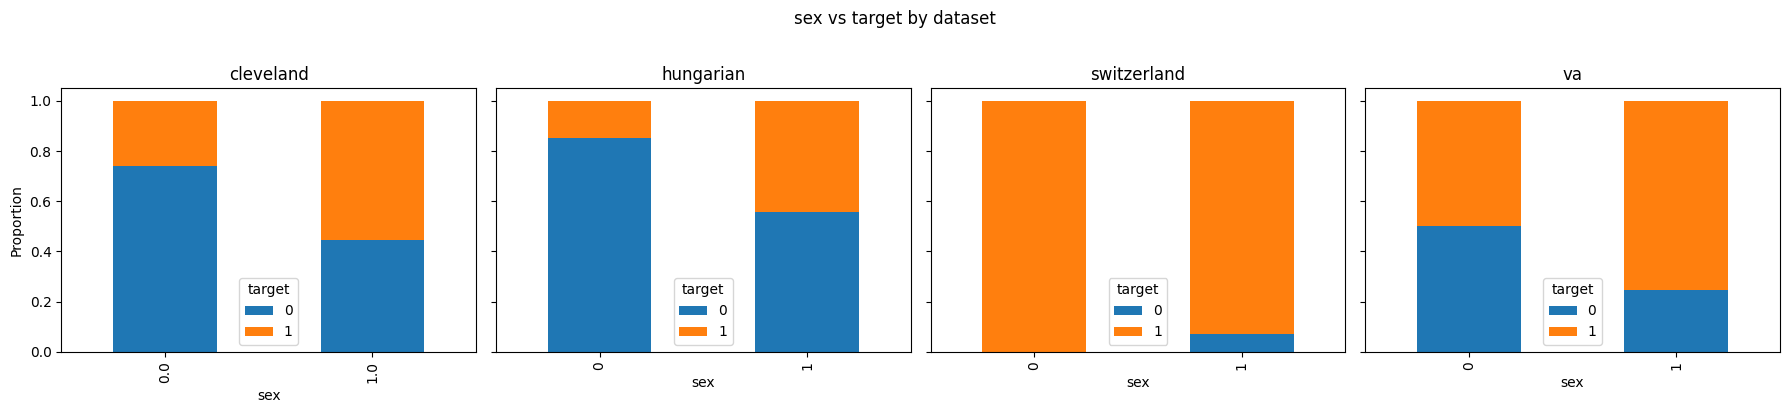

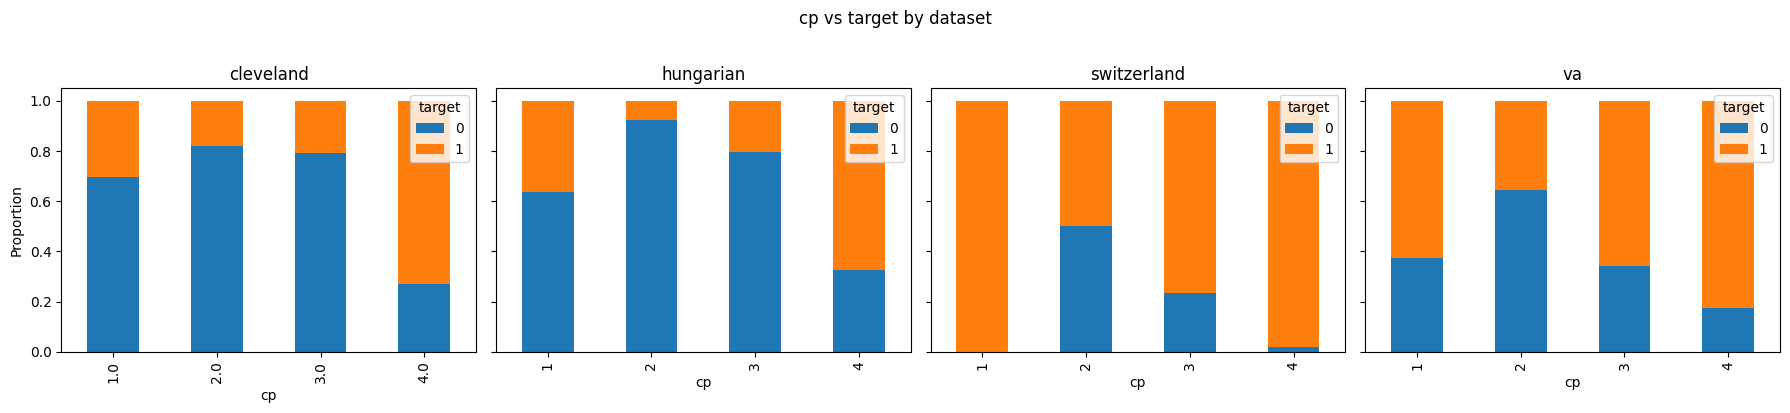

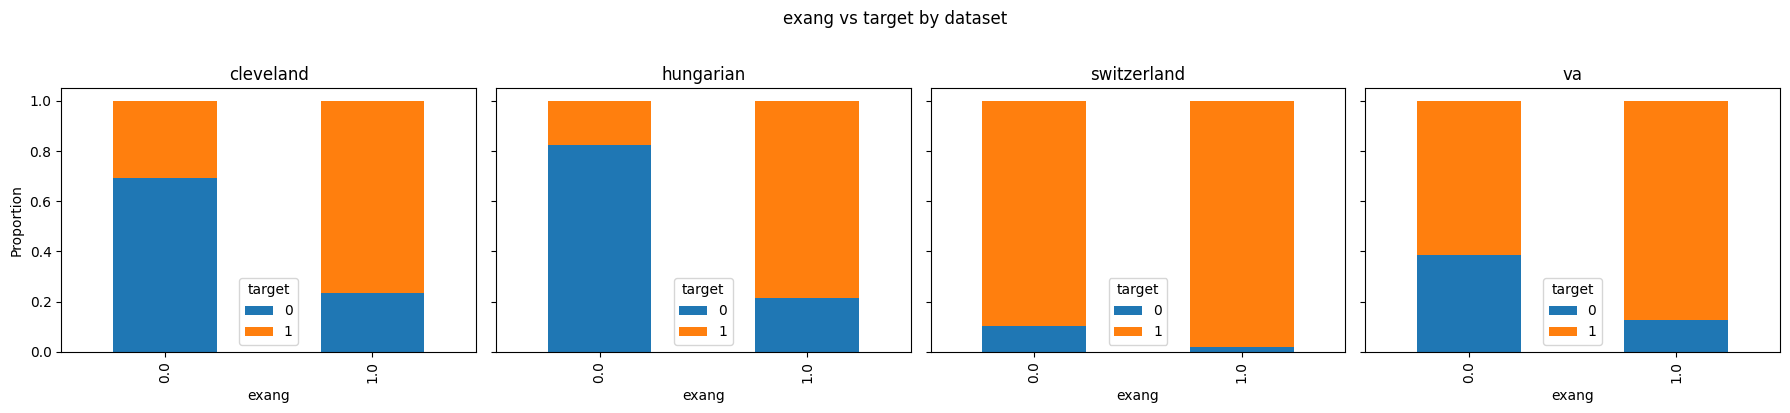

In [109]:
# Categorical features vs target within each dataset

for feature in ["sex", "cp", "exang"]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    
    for ax, (name, df) in zip(axes, datasets.items()):
        ct = pd.crosstab(df[feature], df["target"], normalize="index")
        ct.plot(kind="bar", stacked=True, ax=ax)
        ax.set_title(name)
        ax.set_xlabel(feature)
        ax.set_ylabel("Proportion")
        ax.legend(title="target")
    
    plt.suptitle(f"{feature} vs target by dataset", y=1.02)
    plt.tight_layout()
    plt.show()

Feature–target relationships are largely consistent across datasets, indicating stable predictive signal despite distributional differences. Age and resting blood pressure show a positive association with disease, while maximum heart rate is inversely related. Among categorical features, asymptomatic chest pain (cp=4) emerges as the strongest and most consistent predictor, and exercise-induced angina also shows a clear association with disease presence. In contrast, sex provides weaker and less consistent signal. These results support the suitability of the selected feature set for a portable risk model.

---

### Feature Signal Strength and Data Quality Summary

In [110]:
# Quick univariate signal check

univariate_auc_rows = []

for name, df in datasets.items():
    for feature in ["age", "trestbps", "thalach"]:
        temp = df[[feature, "target"]].dropna()
        
        if temp[feature].nunique() > 1 and temp["target"].nunique() == 2:
            auc = roc_auc_score(temp["target"], temp[feature])
            auc_flipped = max(auc, 1 - auc)  # keep orientation-neutral
        else:
            auc_flipped = None
        
        univariate_auc_rows.append({
            "dataset": name,
            "feature": feature,
            "roc_auc_abs_direction": auc_flipped
        })

univariate_auc = pd.DataFrame(univariate_auc_rows)
univariate_auc.pivot(index="feature", columns="dataset", values="roc_auc_abs_direction").round(3)

dataset,cleveland,hungarian,switzerland,va
feature,,,,
age,0.637,0.587,0.541,0.597
thalach,0.745,0.692,0.659,0.532
trestbps,0.574,0.586,0.553,0.596


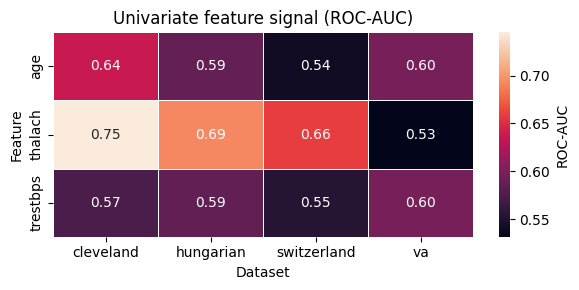

In [111]:
# heatmap

pivot_auc = univariate_auc.pivot(
    index="feature",
    columns="dataset",
    values="roc_auc_abs_direction"
)

plt.figure(figsize=(6, 3))
sns.heatmap(
    pivot_auc,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "ROC-AUC"}
)

plt.title("Univariate feature signal (ROC-AUC)")
plt.xlabel("Dataset")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("uci_plots/model3_heatmap_feature_signal.png", bbox_inches="tight")
plt.show()

In [112]:
# Compact feature summary table for the notebook

feature_summary_rows = []

numeric_features = ["age", "trestbps", "thalach"]
feature_order = model3_features
dataset_order = ["cleveland", "hungarian", "switzerland", "va"]

for dataset_name in dataset_order:
    df = datasets[dataset_name]
    
    for feature in feature_order:
        missing_pct = df[feature].isna().mean() * 100
        
        row = {
            "dataset": dataset_name,
            "feature": feature,
            "feature_type": "numeric" if feature in numeric_features else "categorical",
            "missing_pct": round(missing_pct, 2),
            "complete_pct": round(100 - missing_pct, 2),
            "n_unique": df[feature].nunique(dropna=True)
        }
        
        if feature in numeric_features:
            row["mean"] = round(df[feature].mean(), 2)
            row["std"] = round(df[feature].std(), 2)
        else:
            row["mean"] = np.nan
            row["std"] = np.nan
        
        feature_summary_rows.append(row)

feature_summary = pd.DataFrame(feature_summary_rows)

feature_summary["dataset"] = pd.Categorical(
    feature_summary["dataset"],
    categories=dataset_order,
    ordered=True
)

feature_summary["feature"] = pd.Categorical(
    feature_summary["feature"],
    categories=feature_order,
    ordered=True
)

feature_summary = feature_summary.sort_values(["feature", "dataset"]).reset_index(drop=True)

feature_summary

,dataset,feature,feature_type,missing_pct,complete_pct,n_unique,mean,std
0,cleveland,age,numeric,0.00,100.00,41,54.44,9.04
1,hungarian,age,numeric,0.00,100.00,38,47.83,7.81
2,switzerland,age,numeric,0.00,100.00,37,55.32,9.03
3,va,age,numeric,0.00,100.00,39,59.35,7.81
4,cleveland,sex,categorical,0.00,100.00,2,NaN,NaN
5,hungarian,sex,categorical,0.00,100.00,2,NaN,NaN
6,switzerland,sex,categorical,0.00,100.00,2,NaN,NaN
7,va,sex,categorical,0.00,100.00,2,NaN,NaN
8,cleveland,cp,categorical,0.00,100.00,4,NaN,NaN
9,hungarian,cp,categorical,0.00,100.00,4,NaN,NaN


In [113]:
model3_data = {}

for name, df in datasets.items():
    model3_data[name] = df[model3_features + ["target"]].copy()

for name, df in model3_data.items():
    print(name, df.shape)

cleveland (303, 7)
hungarian (294, 7)
switzerland (123, 7)
va (200, 7)


Univariate checks suggest that `thalach` carries the strongest individual signal, followed by `age`, while `trestbps` is weaker across datasets. Data quality is strong in Cleveland and Hungarian, but missingness increases in Switzerland and is most substantial in the VA cohort, especially for `exang`, `trestbps`, and `thalach`. Overall, the selected features retain useful predictive signal, but cross-dataset variability remains an important constraint for Model 3.

---

## Feature Validation Summary

The Model 3 feature set retains a consistent and clinically meaningful predictive signal across datasets despite substantial heterogeneity. A small number of variables—particularly chest pain type and maximum heart rate—capture most of the discriminative power, while age contributes moderate signal and resting blood pressure adds limited value.

At the same time, clear dataset shift is present in both feature distributions and disease prevalence, and data quality varies notably, with increased missingness in the VA cohort. These factors indicate that model performance will depend not only on feature selection but also on robustness to distributional differences and incomplete data.

Overall, the selected feature set represents a deliberate trade-off: it sacrifices some predictive strength relative to richer models in exchange for simplicity, portability, and broader applicability. The subsequent modeling approach must therefore prioritize stability and generalization across datasets rather than optimizing performance on a single cohort.

---

## Model pipeline, Cross-validation results and Cross-dataset evaluation

In [114]:
# Model 3 baseline feature set

model3_features = ["age", "sex", "cp", "exang", "trestbps", "thalach"]
target = "target"

numeric_features = ["age", "trestbps", "thalach"]
categorical_features = ["sex", "cp", "exang"]

In [115]:
# Helper to prepare each dataset for Model 3 baseline

def prepare_model3_dataset(df, source_name):
    df = df.copy()
    df[target] = (df["num"] > 0).astype(int)   # binary target
    df["dataset_source"] = source_name
    return df[model3_features + [target, "dataset_source"]]

In [116]:
# Prepare datasets

cleveland_m3 = prepare_model3_dataset(df_cleveland, "Cleveland")
hungarian_m3 = prepare_model3_dataset(df_hungarian, "Hungarian")
switzerland_m3 = prepare_model3_dataset(df_switzerland, "Switzerland")
va_m3 = prepare_model3_dataset(df_va, "VA")

In [117]:
# Training data: cleaner / more stable cohorts
train_df_m3 = pd.concat(
    [cleveland_m3, hungarian_m3],
    axis=0,
    ignore_index=True
)

# External test cohorts
swiss_test_m3 = switzerland_m3.copy()
va_test_m3 = va_m3.copy()

X_train_m3 = train_df_m3[model3_features]
y_train_m3 = train_df_m3[target]
groups_m3 = train_df_m3["dataset_source"]

print("Training shape:", train_df_m3.shape)
print("\nTraining samples by dataset:")
print(train_df_m3["dataset_source"].value_counts())

print("\nPositive class rate in training data:")
print(train_df_m3.groupby("dataset_source")[target].mean().round(3))

Training shape: (597, 8)

Training samples by dataset:
dataset_source
Cleveland    303
Hungarian    294
Name: count, dtype: int64

Positive class rate in training data:
dataset_source
Cleveland    0.459
Hungarian    0.361
Name: target, dtype: float64


In [118]:
# Build the untuned baseline Model 3 pipeline

preprocessor_m3 = build_preprocessor(
    numerical_features=numeric_features,
    categorical_features=categorical_features
)

model3_pipeline = Pipeline([
    ("preprocessor", preprocessor_m3),
    ("classifier", LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight="balanced"
    ))
])

model3_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [119]:
# Helper to compute baseline evaluation metrics

def compute_classification_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "n_test": len(y_true),
        "positive_rate": y_true.mean()
    }

In [120]:
# Internal validation: cross-dataset holdout
# With two training cohorts, this is effectively:
# - train on Cleveland, test on Hungarian
# - train on Hungarian, test on Cleveland

gkf_m3 = GroupKFold(n_splits=2)
holdout_results_m3 = []

for fold, (train_idx, test_idx) in enumerate(
    gkf_m3.split(X_train_m3, y_train_m3, groups=groups_m3),
    start=1
):
    X_tr = X_train_m3.iloc[train_idx]
    X_te = X_train_m3.iloc[test_idx]
    y_tr = y_train_m3.iloc[train_idx]
    y_te = y_train_m3.iloc[test_idx]

    train_groups = groups_m3.iloc[train_idx].unique()
    test_groups = groups_m3.iloc[test_idx].unique()
    test_dataset = test_groups[0]

    model3_pipeline.fit(X_tr, y_tr)

    y_proba = model3_pipeline.predict_proba(X_te)[:, 1]
    y_pred = model3_pipeline.predict(X_te)  # default threshold = 0.5 baseline

    metrics = compute_classification_metrics(y_te, y_pred, y_proba)
    metrics.update({
        "fold": fold,
        "evaluation_type": "Cross-dataset holdout",
        "test_dataset": test_dataset,
        "train_datasets": ", ".join(train_groups)
    })

    holdout_results_m3.append(metrics)

    print(f"\n{'='*72}")
    print(f"Fold {fold}: Cross-dataset holdout")
    print(f"Train datasets: {list(train_groups)}")
    print(f"Test dataset: {test_dataset}")
    print(f"{'='*72}")
    print(f"ROC-AUC:           {metrics['roc_auc']:.4f}")
    print(f"Accuracy:          {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Sensitivity:       {metrics['sensitivity']:.4f}")
    print(f"Specificity:       {metrics['specificity']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_te, y_pred))
    print("Confusion matrix:")
    print(np.array([[metrics["tn"], metrics["fp"]],
                    [metrics["fn"], metrics["tp"]]]))


Fold 1: Cross-dataset holdout
Train datasets: ['Hungarian']
Test dataset: Cleveland
ROC-AUC:           0.8528
Accuracy:          0.7690
Balanced Accuracy: 0.7630
Sensitivity:       0.6906
Specificity:       0.8354

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       164
           1       0.78      0.69      0.73       139

    accuracy                           0.77       303
   macro avg       0.77      0.76      0.76       303
weighted avg       0.77      0.77      0.77       303

Confusion matrix:
[[137  27]
 [ 43  96]]

Fold 2: Cross-dataset holdout
Train datasets: ['Cleveland']
Test dataset: Hungarian
ROC-AUC:           0.8536
Accuracy:          0.7585
Balanced Accuracy: 0.7700
Sensitivity:       0.8113
Specificity:       0.7287

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.73      0.79       188
           1       0.63      0.81      0.71  

In [121]:
# Cross-dataset holdout summary table

holdout_results_m3_df = pd.DataFrame(holdout_results_m3)

holdout_results_m3_df = holdout_results_m3_df[
    [
        "evaluation_type", "fold", "train_datasets", "test_dataset",
        "roc_auc", "accuracy", "balanced_accuracy",
        "sensitivity", "specificity",
        "n_test", "positive_rate", "tn", "fp", "fn", "tp"
    ]
].sort_values(by="roc_auc", ascending=False)

display(holdout_results_m3_df)

,evaluation_type,fold,train_datasets,test_dataset,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,n_test,positive_rate,tn,fp,fn,tp
1,Cross-dataset holdout,2,Cleveland,Hungarian,0.853623,0.758503,0.770022,0.811321,0.728723,294,0.360544,137,51,20,86
0,Cross-dataset holdout,1,Hungarian,Cleveland,0.852825,0.768977,0.763007,0.690647,0.835366,303,0.458746,137,27,43,96


In [122]:
# Aggregate internal baseline results

print("Internal baseline summary (cross-dataset holdout):")
print(f"Mean ROC-AUC:           {holdout_results_m3_df['roc_auc'].mean():.4f}")
print(f"Std ROC-AUC:            {holdout_results_m3_df['roc_auc'].std():.4f}")
print(f"Mean Accuracy:          {holdout_results_m3_df['accuracy'].mean():.4f}")
print(f"Mean Balanced Accuracy: {holdout_results_m3_df['balanced_accuracy'].mean():.4f}")
print(f"Mean Sensitivity:       {holdout_results_m3_df['sensitivity'].mean():.4f}")
print(f"Mean Specificity:       {holdout_results_m3_df['specificity'].mean():.4f}")

Internal baseline summary (cross-dataset holdout):
Mean ROC-AUC:           0.8532
Std ROC-AUC:            0.0006
Mean Accuracy:          0.7637
Mean Balanced Accuracy: 0.7665
Mean Sensitivity:       0.7510
Mean Specificity:       0.7820


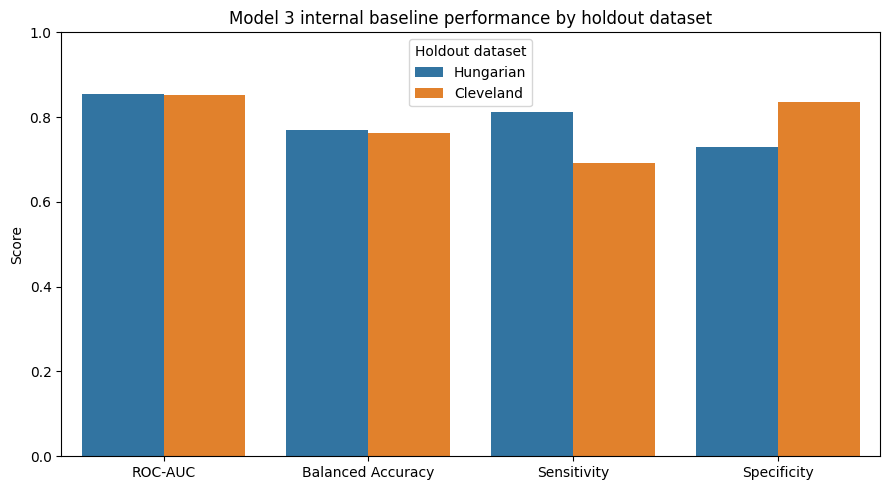

In [123]:
# Visualize internal cross-dataset holdout results

plot_df = holdout_results_m3_df.copy()

metrics_to_plot = ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
metric_labels = {
    "roc_auc": "ROC-AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity"
}

plot_long = plot_df.melt(
    id_vars=["test_dataset"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plot_long["metric"] = plot_long["metric"].map(metric_labels)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_long,
    x="metric",
    y="score",
    hue="test_dataset"
)

plt.ylim(0, 1)
plt.title("Model 3 internal baseline performance by holdout dataset")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="Holdout dataset")
plt.tight_layout()
plt.show()

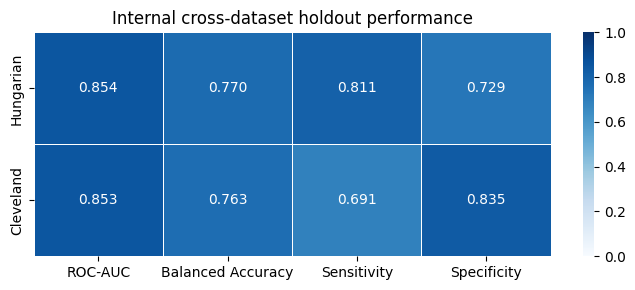

In [124]:
# Heatmap view of internal cross-dataset holdout results

heatmap_df = holdout_results_m3_df.set_index("test_dataset")[
    ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
].copy()

heatmap_df.columns = ["ROC-AUC", "Balanced Accuracy", "Sensitivity", "Specificity"]

plt.figure(figsize=(7, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Internal cross-dataset holdout performance")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_internal_baseline_performance.png", bbox_inches="tight")
plt.show()

In [125]:
# Fit final untuned baseline Model 3 on all training data

final_model3 = Pipeline([
    ("preprocessor", build_preprocessor(
        numerical_features=numeric_features,
        categorical_features=categorical_features
    )),
    ("classifier", LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight="balanced"
    ))
])

final_model3.fit(X_train_m3, y_train_m3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [126]:
# External baseline evaluation on Switzerland and VA

external_results_m3 = []

for test_name, test_df in [("Switzerland", swiss_test_m3), ("VA", va_test_m3)]:
    X_ext = test_df[model3_features]
    y_ext = test_df[target]

    y_proba = final_model3.predict_proba(X_ext)[:, 1]
    y_pred = final_model3.predict(X_ext)  # default threshold = 0.5 baseline

    metrics = compute_classification_metrics(y_ext, y_pred, y_proba)
    metrics.update({
        "evaluation_type": "External test",
        "test_dataset": test_name
    })

    external_results_m3.append(metrics)

    print(f"\n{'='*72}")
    print(f"External baseline evaluation: {test_name}")
    print(f"{'='*72}")
    print(f"ROC-AUC:           {metrics['roc_auc']:.4f}")
    print(f"Accuracy:          {metrics['accuracy']:.4f}")
    print(f"Balanced Accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"Sensitivity:       {metrics['sensitivity']:.4f}")
    print(f"Specificity:       {metrics['specificity']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_ext, y_pred))
    print("Confusion matrix:")
    print(np.array([[metrics["tn"], metrics["fp"]],
                    [metrics["fn"], metrics["tp"]]]))


External baseline evaluation: Switzerland
ROC-AUC:           0.8087
Accuracy:          0.8293
Balanced Accuracy: 0.7342
Sensitivity:       0.8435
Specificity:       0.6250

Classification report:
              precision    recall  f1-score   support

           0       0.22      0.62      0.32         8
           1       0.97      0.84      0.90       115

    accuracy                           0.83       123
   macro avg       0.59      0.73      0.61       123
weighted avg       0.92      0.83      0.86       123

Confusion matrix:
[[ 5  3]
 [18 97]]

External baseline evaluation: VA
ROC-AUC:           0.7391
Accuracy:          0.7500
Balanced Accuracy: 0.6452
Sensitivity:       0.8591
Specificity:       0.4314

Classification report:
              precision    recall  f1-score   support

           0       0.51      0.43      0.47        51
           1       0.82      0.86      0.84       149

    accuracy                           0.75       200
   macro avg       0.66      0.65

In [127]:
# External baseline summary table

external_results_m3_df = pd.DataFrame(external_results_m3)

external_results_m3_df = external_results_m3_df[
    [
        "evaluation_type", "test_dataset",
        "roc_auc", "accuracy", "balanced_accuracy",
        "sensitivity", "specificity",
        "n_test", "positive_rate", "tn", "fp", "fn", "tp"
    ]
].sort_values(by="roc_auc", ascending=False)

display(external_results_m3_df)

,evaluation_type,test_dataset,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,n_test,positive_rate,tn,fp,fn,tp
0,External test,Switzerland,0.808696,0.829268,0.734239,0.843478,0.625000,123,0.934959,5,3,18,97
1,External test,VA,0.739110,0.750000,0.645216,0.859060,0.431373,200,0.745000,22,29,21,128


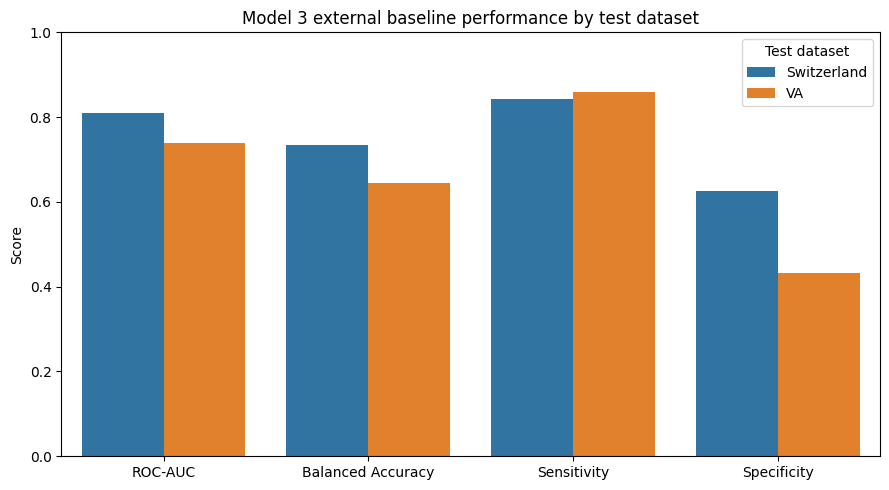

In [128]:
# Visualize external baseline results

plot_df = external_results_m3_df.copy()

metrics_to_plot = ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
metric_labels = {
    "roc_auc": "ROC-AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity"
}

plot_long = plot_df.melt(
    id_vars=["test_dataset"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plot_long["metric"] = plot_long["metric"].map(metric_labels)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_long,
    x="metric",
    y="score",
    hue="test_dataset"
)

plt.ylim(0, 1)
plt.title("Model 3 external baseline performance by test dataset")
plt.xlabel("")
plt.ylabel("Score")
plt.legend(title="Test dataset")
plt.tight_layout()
plt.show()

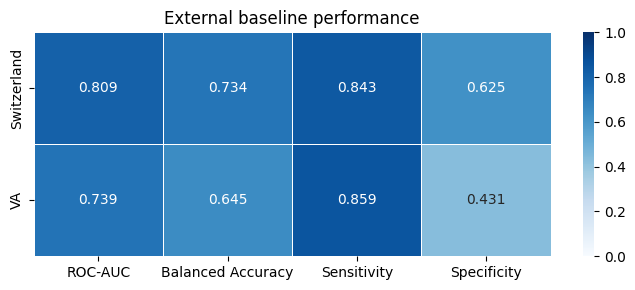

In [129]:
# Heatmap view of external baseline results

heatmap_df = external_results_m3_df.set_index("test_dataset")[
    ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
].copy()

heatmap_df.columns = ["ROC-AUC", "Balanced Accuracy", "Sensitivity", "Specificity"]

plt.figure(figsize=(7, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("External baseline performance")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_external_baseline_performance.png", bbox_inches="tight")
plt.show()

In [130]:
# Combined baseline summary

internal_summary = holdout_results_m3_df.copy()
external_summary = external_results_m3_df.copy()

baseline_model3_results = pd.concat(
    [internal_summary, external_summary],
    axis=0,
    ignore_index=True
)

display(baseline_model3_results)

,evaluation_type,fold,train_datasets,test_dataset,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,n_test,positive_rate,tn,fp,fn,tp
0,Cross-dataset holdout,2.0,Cleveland,Hungarian,0.853623,0.758503,0.770022,0.811321,0.728723,294,0.360544,137,51,20,86
1,Cross-dataset holdout,1.0,Hungarian,Cleveland,0.852825,0.768977,0.763007,0.690647,0.835366,303,0.458746,137,27,43,96
2,External test,NaN,NaN,Switzerland,0.808696,0.829268,0.734239,0.843478,0.625000,123,0.934959,5,3,18,97
3,External test,NaN,NaN,VA,0.739110,0.750000,0.645216,0.859060,0.431373,200,0.745000,22,29,21,128


In [131]:
# Probability-based evaluation summary (threshold-independent)

probability_summary_m3 = baseline_model3_results[
    ["evaluation_type", "test_dataset", "roc_auc", "n_test", "positive_rate"]
].copy()

display(probability_summary_m3)

,evaluation_type,test_dataset,roc_auc,n_test,positive_rate
0,Cross-dataset holdout,Hungarian,0.853623,294,0.360544
1,Cross-dataset holdout,Cleveland,0.852825,303,0.458746
2,External test,Switzerland,0.808696,123,0.934959
3,External test,VA,0.739110,200,0.745000


In [132]:
# Threshold-based evaluation summary (default threshold = 0.5)

threshold_summary_m3 = baseline_model3_results[
    [
        "evaluation_type", "test_dataset",
        "accuracy", "balanced_accuracy",
        "sensitivity", "specificity",
        "tn", "fp", "fn", "tp"
    ]
].copy()

display(threshold_summary_m3)

,evaluation_type,test_dataset,accuracy,balanced_accuracy,sensitivity,specificity,tn,fp,fn,tp
0,Cross-dataset holdout,Hungarian,0.758503,0.770022,0.811321,0.728723,137,51,20,86
1,Cross-dataset holdout,Cleveland,0.768977,0.763007,0.690647,0.835366,137,27,43,96
2,External test,Switzerland,0.829268,0.734239,0.843478,0.625000,5,3,18,97
3,External test,VA,0.750000,0.645216,0.859060,0.431373,22,29,21,128


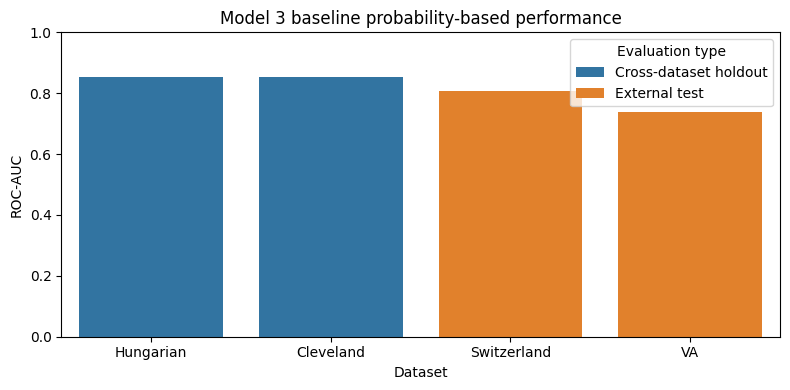

In [133]:
# Visualize combined probability-based baseline results

plot_df = probability_summary_m3.copy()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="test_dataset",
    y="roc_auc",
    hue="evaluation_type"
)

plt.ylim(0, 1)
plt.title("Model 3 baseline probability-based performance")
plt.xlabel("Dataset")
plt.ylabel("ROC-AUC")
plt.legend(title="Evaluation type")
plt.tight_layout()
plt.show()

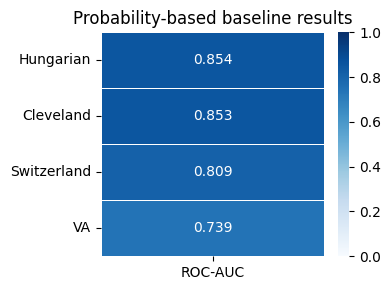

In [134]:
# Heatmap for combined probability-based baseline results

heatmap_df = probability_summary_m3.set_index("test_dataset")[["roc_auc"]].copy()
heatmap_df.columns = ["ROC-AUC"]

plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Probability-based baseline results")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_probability_based_baseline_results.png", bbox_inches="tight")
plt.show()

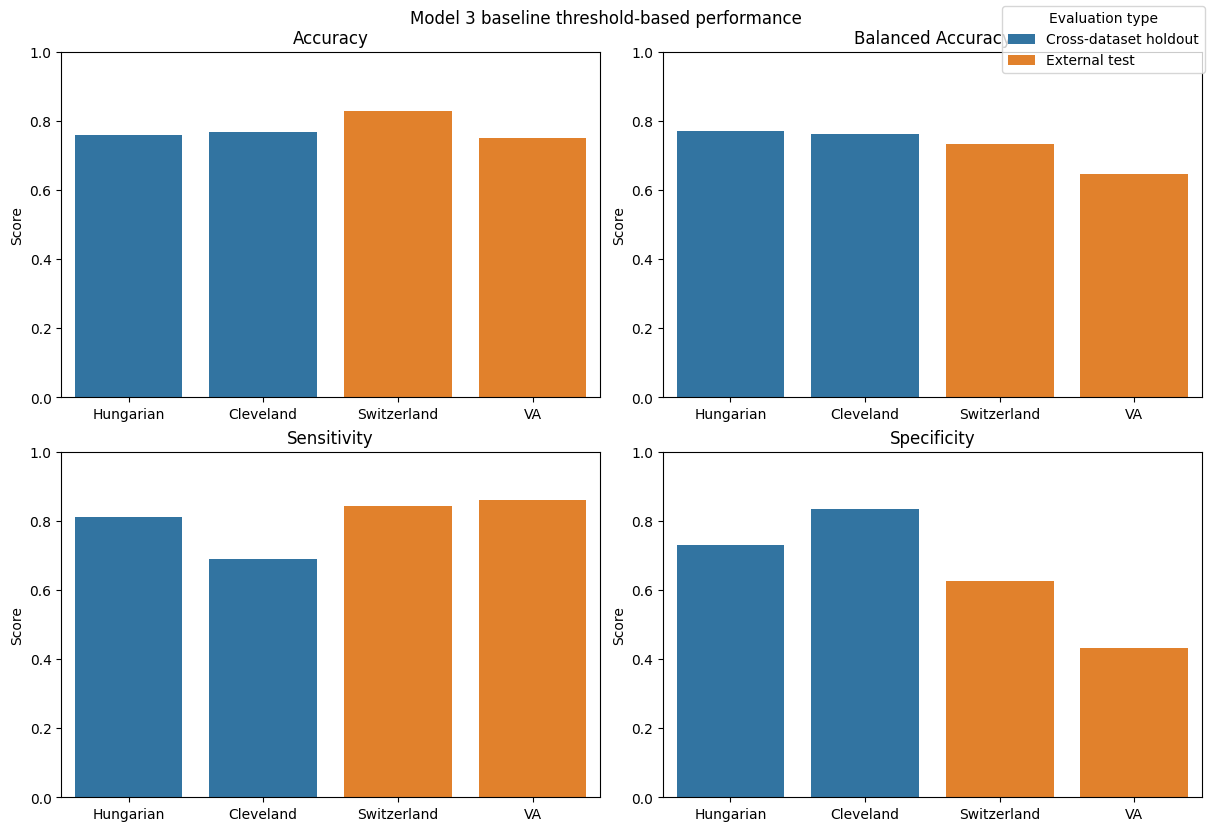

In [135]:
# Visualize combined threshold-based baseline results

plot_df = threshold_summary_m3.copy()

metrics_to_plot = ["accuracy", "balanced_accuracy", "sensitivity", "specificity"]
metric_labels = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity"
}

plot_long = plot_df.melt(
    id_vars=["evaluation_type", "test_dataset"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plot_long["metric"] = plot_long["metric"].map(metric_labels)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, metric in zip(axes, metric_labels.values()):
    metric_df = plot_long[plot_long["metric"] == metric]

    sns.barplot(
        data=metric_df,
        x="test_dataset",
        y="score",
        hue="evaluation_type",
        ax=ax
    )

    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

fig.legend(handles, labels, loc="upper right", title="Evaluation type")
plt.suptitle("Model 3 baseline threshold-based performance", y=1.02)
plt.savefig("uci_plots/model3_baseline_threshold-based_performance.png", bbox_inches="tight")
plt.show()

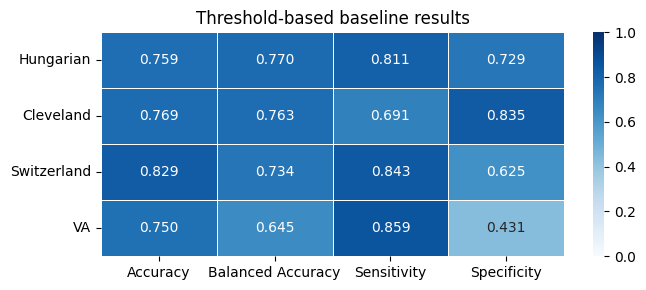

In [136]:
# Heatmap for combined threshold-based baseline results

heatmap_df = threshold_summary_m3.set_index("test_dataset")[
    ["accuracy", "balanced_accuracy", "sensitivity", "specificity"]
].copy()

heatmap_df.columns = ["Accuracy", "Balanced Accuracy", "Sensitivity", "Specificity"]

plt.figure(figsize=(7, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Threshold-based baseline results")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_baseline_threshold-based_performance_heatmap.png", bbox_inches="tight")
plt.show()

### Model 3 performance interpretation

The untuned baseline Model 3 shows strong and remarkably stable **discriminative performance** in cross-dataset holdout, with ROC-AUC around **0.85** in both directions, indicating that the reduced feature set preserves substantial predictive signal even under cohort shift between Cleveland and Hungarian data. External performance remains solid on **Switzerland** (**ROC-AUC ≈ 0.81**) and declines more clearly on **VA** (**ROC-AUC ≈ 0.74**), confirming that the model is portable but more sensitive to stronger distribution shift and missingness.

Threshold-based performance reveals a more important limitation: the baseline model tends to favor **sensitivity over specificity**, especially on the external cohorts. This trade-off is moderate on Switzerland but becomes pronounced on VA, where sensitivity remains high (**≈ 0.86**) while specificity drops substantially (**≈ 0.43**). In other words, the model still identifies most positive cases, but at the cost of more false positives under harder out-of-distribution conditions.

Accuracy should also be interpreted cautiously, particularly for Switzerland, where the very high positive prevalence inflates headline classification performance. Overall, these results support Model 3 as a **credible lightweight baseline**: a small, clinically accessible feature set can recover much of the underlying signal, but robustness at the default threshold is weaker than discrimination alone suggests, especially under stronger dataset shift.

---

## Threshold tuning

The baseline model showed useful probability discrimination, but default classification at a threshold of 0.5 does not necessarily match the intended use of Model 3 as a lightweight screening tool.

This subsection selects an operating threshold using **out-of-fold predicted probabilities from the training cohorts only**. The objective is to prioritize **high sensitivity**, so that most positive cases are identified, while choosing the **highest possible specificity** among thresholds that satisfy the target sensitivity constraint.

This procedure does **not** change model parameters or refit the model on external data. It only selects a decision threshold for converting predicted probabilities into class labels.

In [137]:
# Out-of-fold predicted probabilities on training data for threshold selection

gkf_m3 = GroupKFold(n_splits=2)

oof_pred_proba_m3 = np.zeros(len(X_train_m3))
oof_y_true_m3 = y_train_m3.to_numpy()

for train_idx, valid_idx in gkf_m3.split(X_train_m3, y_train_m3, groups=groups_m3):
    X_tr = X_train_m3.iloc[train_idx]
    X_val = X_train_m3.iloc[valid_idx]
    y_tr = y_train_m3.iloc[train_idx]

    fold_model_m3 = clone(final_model3)
    fold_model_m3.fit(X_tr, y_tr)

    oof_pred_proba_m3[valid_idx] = fold_model_m3.predict_proba(X_val)[:, 1]

In [138]:
# Threshold candidate table from out-of-fold training predictions

fpr_m3, tpr_m3, threshold_values_m3 = roc_curve(oof_y_true_m3, oof_pred_proba_m3)

threshold_candidates_m3 = pd.DataFrame({
    "threshold": threshold_values_m3,
    "sensitivity": tpr_m3,
    "fpr": fpr_m3,
    "specificity": 1 - fpr_m3
})

threshold_candidates_m3["balanced_accuracy"] = (
    threshold_candidates_m3["sensitivity"] + threshold_candidates_m3["specificity"]
) / 2

threshold_candidates_m3 = threshold_candidates_m3.sort_values(
    by="threshold",
    ascending=False
).reset_index(drop=True)

display(threshold_candidates_m3.head(10))

,threshold,sensitivity,fpr,specificity,balanced_accuracy
0,inf,0.000000,0.000000,1.000000,0.500000
1,0.966104,0.004082,0.000000,1.000000,0.502041
2,0.921975,0.073469,0.000000,1.000000,0.536735
3,0.921797,0.073469,0.002841,0.997159,0.535314
4,0.907602,0.097959,0.002841,0.997159,0.547559
5,0.906387,0.097959,0.005682,0.994318,0.546139
6,0.896497,0.114286,0.005682,0.994318,0.554302
7,0.893950,0.114286,0.008523,0.991477,0.552881
8,0.885401,0.138776,0.008523,0.991477,0.565126
9,0.884734,0.138776,0.011364,0.988636,0.563706


In [139]:
# Select operating threshold:
# minimum target sensitivity, then highest specificity among eligible thresholds

min_target_sensitivity_m3 = 0.85

eligible_thresholds_m3 = threshold_candidates_m3[
    threshold_candidates_m3["sensitivity"] >= min_target_sensitivity_m3
].copy()

selected_threshold_row_m3 = eligible_thresholds_m3.sort_values(
    by="specificity",
    ascending=False
).iloc[0]

selected_threshold_m3 = float(selected_threshold_row_m3["threshold"])

In [140]:
# Selected operating point summary

print("Selected operating threshold for Model 3:")
print(f"Threshold:           {selected_threshold_m3:.3f}")
print(f"OOF Sensitivity:     {selected_threshold_row_m3['sensitivity']:.4f}")
print(f"OOF Specificity:     {selected_threshold_row_m3['specificity']:.4f}")
print(f"OOF Balanced Acc.:   {selected_threshold_row_m3['balanced_accuracy']:.4f}")
print(f"OOF False Pos. Rate: {selected_threshold_row_m3['fpr']:.4f}")
print(f"Eligible thresholds: {len(eligible_thresholds_m3)}")

Selected operating threshold for Model 3:
Threshold:           0.372
OOF Sensitivity:     0.8531
OOF Specificity:     0.6364
OOF Balanced Acc.:   0.7447
OOF False Pos. Rate: 0.3636
Eligible thresholds: 58


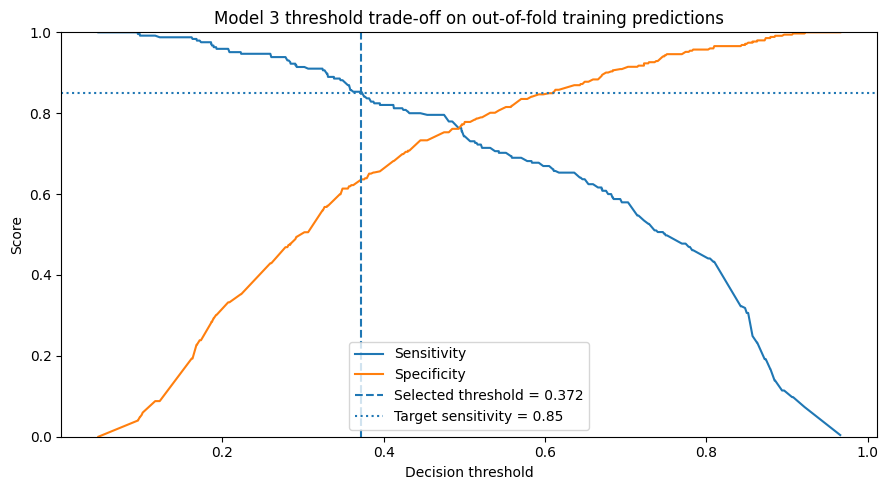

In [141]:
# Threshold trade-off plot on out-of-fold training predictions

plot_df = threshold_candidates_m3.copy()

plt.figure(figsize=(9, 5))
plt.plot(plot_df["threshold"], plot_df["sensitivity"], label="Sensitivity")
plt.plot(plot_df["threshold"], plot_df["specificity"], label="Specificity")
plt.axvline(selected_threshold_m3, linestyle="--", label=f"Selected threshold = {selected_threshold_m3:.3f}")
plt.axhline(min_target_sensitivity_m3, linestyle=":", label=f"Target sensitivity = {min_target_sensitivity_m3:.2f}")

plt.title("Model 3 threshold trade-off on out-of-fold training predictions")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig("uci_plots/model3_threshold_trade-off_on_oof.png", bbox_inches="tight")
plt.show()

In [142]:
# Evaluate selected threshold on training and external datasets

threshold_tuned_results_m3 = []

all_eval_sets_m3 = {
    "Cleveland": cleveland_m3,
    "Hungarian": hungarian_m3,
    "Switzerland": switzerland_m3,
    "VA": va_m3
}

for dataset_name, df_eval in all_eval_sets_m3.items():
    X_eval = df_eval[model3_features]
    y_eval = df_eval[target]

    y_pred_proba = final_model3.predict_proba(X_eval)[:, 1]
    y_pred_label = (y_pred_proba >= selected_threshold_m3).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred_label).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    row = {
        "dataset": dataset_name,
        "evaluation_group": "Training cohorts" if dataset_name in ["Cleveland", "Hungarian"] else "External cohorts",
        "threshold": selected_threshold_m3,
        "roc_auc": roc_auc_score(y_eval, y_pred_proba),
        "accuracy": accuracy_score(y_eval, y_pred_label),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred_label),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision_positive": precision_pos,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "n_samples": len(y_eval),
        "positive_rate": y_eval.mean()
    }

    threshold_tuned_results_m3.append(row)

    print(f"\n{'='*72}")
    print(f"{dataset_name} | threshold = {selected_threshold_m3:.3f}")
    print(f"{'='*72}")
    print(f"ROC-AUC:           {row['roc_auc']:.4f}")
    print(f"Accuracy:          {row['accuracy']:.4f}")
    print(f"Balanced Accuracy: {row['balanced_accuracy']:.4f}")
    print(f"Sensitivity:       {row['sensitivity']:.4f}")
    print(f"Specificity:       {row['specificity']:.4f}")
    print(f"Precision (pos):   {row['precision_positive']:.4f}")
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred_label))
    print("Confusion matrix:")
    print(np.array([[tn, fp], [fn, tp]]))


Cleveland | threshold = 0.372
ROC-AUC:           0.8691
Accuracy:          0.7690
Balanced Accuracy: 0.7773
Sensitivity:       0.8777
Specificity:       0.6768
Precision (pos):   0.6971

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.68      0.76       164
           1       0.70      0.88      0.78       139

    accuracy                           0.77       303
   macro avg       0.78      0.78      0.77       303
weighted avg       0.79      0.77      0.77       303

Confusion matrix:
[[111  53]
 [ 17 122]]

Hungarian | threshold = 0.372
ROC-AUC:           0.8822
Accuracy:          0.7959
Balanced Accuracy: 0.8199
Sensitivity:       0.9057
Specificity:       0.7340
Precision (pos):   0.6575

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.73      0.82       188
           1       0.66      0.91      0.76       106

    accuracy                           0.80   

In [143]:
# Combined threshold-tuned evaluation results

threshold_tuned_results_m3_df = pd.DataFrame(threshold_tuned_results_m3).sort_values(
    by="roc_auc",
    ascending=False
)

display(threshold_tuned_results_m3_df)

,dataset,evaluation_group,threshold,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive,tn,fp,fn,tp,n_samples,positive_rate
1,Hungarian,Training cohorts,0.372348,0.882176,0.795918,0.819851,0.905660,0.734043,0.657534,138,50,10,96,294,0.360544
0,Cleveland,Training cohorts,0.372348,0.869144,0.768977,0.777264,0.877698,0.676829,0.697143,111,53,17,122,303,0.458746
2,Switzerland,External cohorts,0.372348,0.808696,0.886179,0.706522,0.913043,0.500000,0.963303,4,4,10,105,123,0.934959
3,VA,External cohorts,0.372348,0.739110,0.765000,0.616594,0.919463,0.313725,0.796512,16,35,12,137,200,0.745000


In [144]:
# Training-cohort threshold-tuned results

threshold_tuned_train_m3 = threshold_tuned_results_m3_df[
    threshold_tuned_results_m3_df["evaluation_group"] == "Training cohorts"
].copy()

display(threshold_tuned_train_m3)

,dataset,evaluation_group,threshold,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive,tn,fp,fn,tp,n_samples,positive_rate
1,Hungarian,Training cohorts,0.372348,0.882176,0.795918,0.819851,0.905660,0.734043,0.657534,138,50,10,96,294,0.360544
0,Cleveland,Training cohorts,0.372348,0.869144,0.768977,0.777264,0.877698,0.676829,0.697143,111,53,17,122,303,0.458746


In [145]:
# External-cohort threshold-tuned results

threshold_tuned_external_m3 = threshold_tuned_results_m3_df[
    threshold_tuned_results_m3_df["evaluation_group"] == "External cohorts"
].copy()

display(threshold_tuned_external_m3)

,dataset,evaluation_group,threshold,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive,tn,fp,fn,tp,n_samples,positive_rate
2,Switzerland,External cohorts,0.372348,0.808696,0.886179,0.706522,0.913043,0.500000,0.963303,4,4,10,105,123,0.934959
3,VA,External cohorts,0.372348,0.739110,0.765000,0.616594,0.919463,0.313725,0.796512,16,35,12,137,200,0.745000


In [146]:
# Probability-based summary (unchanged by threshold, shown for reference)

threshold_probability_summary_m3 = threshold_tuned_results_m3_df[
    ["evaluation_group", "dataset", "roc_auc", "n_samples", "positive_rate"]
].copy()

display(threshold_probability_summary_m3)

,evaluation_group,dataset,roc_auc,n_samples,positive_rate
1,Training cohorts,Hungarian,0.882176,294,0.360544
0,Training cohorts,Cleveland,0.869144,303,0.458746
2,External cohorts,Switzerland,0.808696,123,0.934959
3,External cohorts,VA,0.739110,200,0.745000


In [147]:
# Threshold-based summary at selected operating point

threshold_classification_summary_m3 = threshold_tuned_results_m3_df[
    [
        "evaluation_group", "dataset", "threshold",
        "accuracy", "balanced_accuracy", "sensitivity", "specificity",
        "precision_positive",
        "tn", "fp", "fn", "tp"
    ]
].copy()

display(threshold_classification_summary_m3)

,evaluation_group,dataset,threshold,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive,tn,fp,fn,tp
1,Training cohorts,Hungarian,0.372348,0.795918,0.819851,0.905660,0.734043,0.657534,138,50,10,96
0,Training cohorts,Cleveland,0.372348,0.768977,0.777264,0.877698,0.676829,0.697143,111,53,17,122
2,External cohorts,Switzerland,0.372348,0.886179,0.706522,0.913043,0.500000,0.963303,4,4,10,105
3,External cohorts,VA,0.372348,0.765000,0.616594,0.919463,0.313725,0.796512,16,35,12,137


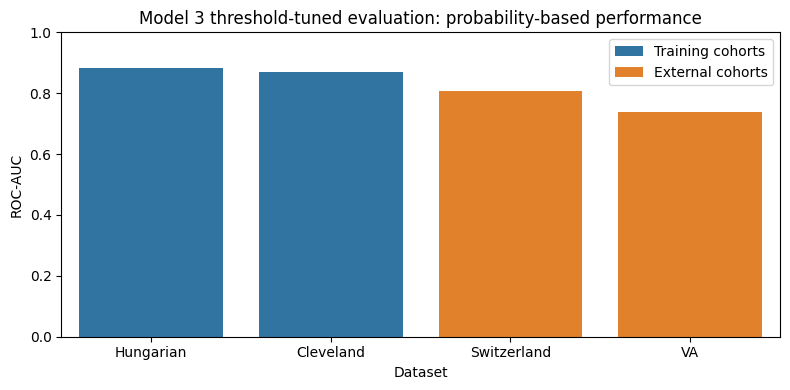

In [148]:
# Visualize probability-based performance after threshold selection
# (ROC-AUC shown for reference; threshold does not affect it)

plot_df = threshold_probability_summary_m3.copy()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=plot_df,
    x="dataset",
    y="roc_auc",
    hue="evaluation_group"
)

plt.ylim(0, 1)
plt.title("Model 3 threshold-tuned evaluation: probability-based performance")
plt.xlabel("Dataset")
plt.ylabel("ROC-AUC")
plt.legend(title="")
plt.tight_layout()
plt.show()

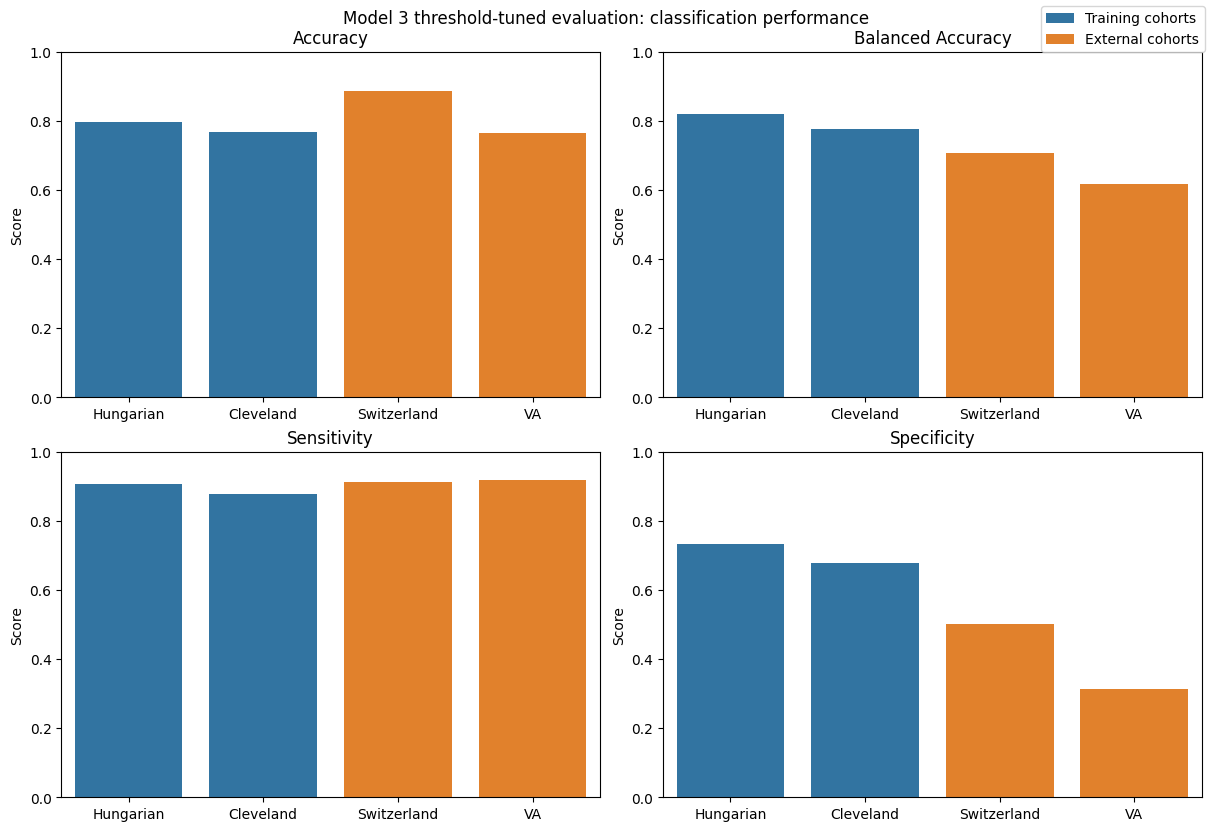

In [149]:
# Visualize threshold-based performance at selected operating point

plot_df = threshold_classification_summary_m3.copy()

metrics_to_plot = ["accuracy", "balanced_accuracy", "sensitivity", "specificity"]
metric_titles = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity"
}

plot_long = plot_df.melt(
    id_vars=["dataset", "evaluation_group"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    metric_df = plot_long[plot_long["metric"] == metric]

    sns.barplot(
        data=metric_df,
        x="dataset",
        y="score",
        hue="evaluation_group",
        ax=ax
    )

    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

fig.legend(handles, labels, loc="upper right", title="")
plt.suptitle("Model 3 threshold-tuned evaluation: classification performance", y=1.02)
plt.savefig("uci_plots/model3_threshold-tuned_evaluation.png", bbox_inches="tight")
plt.show()

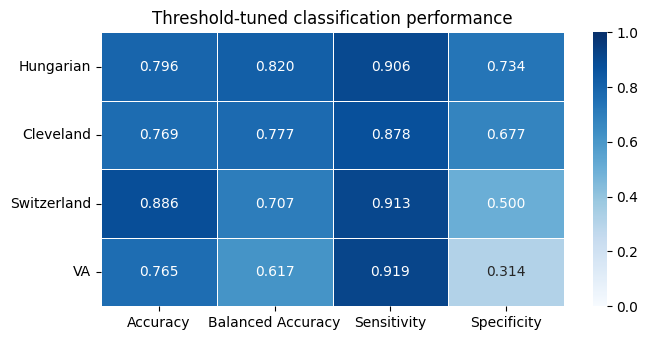

In [150]:
# Optional heatmap for threshold-based performance

heatmap_df = threshold_tuned_results_m3_df.set_index("dataset")[
    ["accuracy", "balanced_accuracy", "sensitivity", "specificity"]
].copy()

heatmap_df.columns = ["Accuracy", "Balanced Accuracy", "Sensitivity", "Specificity"]

plt.figure(figsize=(7, 3.5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Threshold-tuned classification performance")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

To make Model 3 more suitable for screening-oriented use, the decision threshold was selected from out-of-fold predictions on the training cohorts only, using a minimum sensitivity target of 0.85. This choice reflects the intended role of the model: for a lightweight first-pass classifier, missing positive cases is more costly than generating additional false positives. A target of 0.85 provides a practical compromise—high enough to prioritize case detection, but not so extreme that specificity collapses completely.

Under this rule, the selected threshold (0.372) achieved OOF sensitivity = 0.853 and OOF specificity = 0.636, indicating a reasonable operating point for a sensitivity-first model. After applying this threshold, sensitivity increased consistently across all datasets, reaching about 0.88–0.91 on the training cohorts and 0.91–0.92 on the external cohorts. This confirms that threshold selection successfully shifted the classifier toward the intended screening behavior.

The trade-off is a clear reduction in specificity, especially under stronger dataset shift. This decline is moderate on the training cohorts (~0.68–0.73) and Switzerland (0.50), but becomes substantial on VA (~0.31), where the tuned model captures most positives at the cost of many more false positives. As expected, ROC-AUC remains unchanged, so the subsection mainly shows how the same probability model can be adapted to a more clinically appropriate operating point.

Overall, threshold selection improves the practical usefulness of Model 3 for screening by making its predictions more sensitive and conservative. The results also show that this benefit is dataset-dependent: the strategy works as intended, but the specificity cost becomes more pronounced in the most shifted external cohort.

---

## Model 3 as a fallback strategy

Model 3 is not intended to replace Models 1 and 2 when richer clinical information is available. Instead, it is designed as a fallback option for settings where those richer models must rely more heavily on imputation due to missing data.

To assess this role, we compare the threshold-tuned versions of Models 1, 2, and 3 on the same external datasets. This provides a practical view of how much performance is retained by the minimal-input model when more complex models operate under incomplete data conditions.

In [151]:
# Comparison setup for fallback-strategy analysis

models_dir = Path("artifacts")

def load_pipeline_artifact(path):
    """
    Load a saved model artifact. If the artifact is a dict produced by the
    export step, extract the sklearn pipeline from the 'pipeline' key.
    """
    artifact = joblib.load(path)
    if isinstance(artifact, dict):
        if "pipeline" in artifact:
            return artifact["pipeline"], artifact
        else:
            raise KeyError(
                f"Loaded artifact from {path} is a dict, but does not contain a 'pipeline' key. "
                f"Available keys: {list(artifact.keys())}"
            )
    return artifact, None  # fallback for plain pipeline artifacts

# Load persisted artifacts for Models 1 and 2
final_model1, artifact_model1 = load_pipeline_artifact(models_dir / "model1_full_clinical_v1.joblib")
final_model2, artifact_model2 = load_pipeline_artifact(models_dir / "model2_reduced_clinical_v1.joblib")


# Load metadata JSON files
with open(models_dir / "model1_full_clinical_v1.metadata.json", "r") as f:
    model1_metadata = json.load(f)

with open(models_dir / "model2_reduced_clinical_v1.metadata.json", "r") as f:
    model2_metadata = json.load(f)

# Feature lists
# Prefer feature_order from the saved artifact if available, otherwise fall back to metadata["features"]
model1_features = artifact_model1["feature_order"] if artifact_model1 is not None else model1_metadata["features"]
model2_features = artifact_model2["feature_order"] if artifact_model2 is not None else model2_metadata["features"]

# Model 3 features: define explicitly here so the subsection is self-contained
model3_features = ["age", "sex", "cp", "exang", "trestbps", "thalach"]

# Thresholds
# Prefer threshold from artifact if available, otherwise fall back to metadata["thresholding"]["selected_threshold"]
selected_threshold_m1 = artifact_model1["threshold"] if artifact_model1 is not None else model1_metadata["thresholding"]["selected_threshold"]
selected_threshold_m2 = artifact_model2["threshold"] if artifact_model2 is not None else model2_metadata["thresholding"]["selected_threshold"]

# Model 3 comes from the current notebook state
final_model3_fallback = final_model3
selected_threshold_m3_fallback = selected_threshold_m3

# Comparison spec
fallback_model_specs = {
    "Model 1": {
        "model": final_model1,
        "features": model1_features,
        "threshold": selected_threshold_m1
    },
    "Model 2": {
        "model": final_model2,
        "features": model2_features,
        "threshold": selected_threshold_m2
    },
    "Model 3": {
        "model": final_model3_fallback,
        "features": model3_features,
        "threshold": selected_threshold_m3_fallback
    }
}

# Evaluate on original external datasets so each model can use its own feature set
fallback_eval_sets = {
    "Switzerland": df_switzerland.copy(),
    "VA": df_va.copy()
}

# Sanity checks
for model_name, spec in fallback_model_specs.items():
    print(
        f"{model_name}: "
        f"type={type(spec['model']).__name__} | "
        f"n_features={len(spec['features'])} | "
        f"threshold={spec['threshold']:.3f}"
    )

Model 1: type=Pipeline | n_features=13 | threshold=0.500
Model 2: type=Pipeline | n_features=9 | threshold=0.470
Model 3: type=Pipeline | n_features=6 | threshold=0.372


In [152]:
# Alternative external datasets setup to evaluate each model from the original cleaned datasets

fallback_eval_sets = {
    "Switzerland": df_switzerland.copy(),
    "VA": df_va.copy()
}

In [153]:
# Helpers for fallback-strategy evaluation

def prepare_binary_target_for_eval(df):
    df = df.copy()
    if "target" not in df.columns:
        df["target"] = (df["num"] > 0).astype(int)
    return df

def compute_threshold_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision_pos = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    return {
        "roc_auc": roc_auc_score(y_true, y_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision_positive": precision_pos,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "n_samples": len(y_true),
        "positive_rate": y_true.mean()
    }

def evaluate_threshold_tuned_model(model, df, feature_list, threshold):
    df_eval = prepare_binary_target_for_eval(df)

    X_eval = df_eval[feature_list]
    y_eval = df_eval["target"]

    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = compute_threshold_metrics(y_eval, y_pred, y_proba)
    return metrics

In [154]:
# Missingness burden of each model's required inputs on external datasets

missingness_rows = []

for dataset_name, df_raw in fallback_eval_sets.items():
    df_eval = prepare_binary_target_for_eval(df_raw)

    for model_name, spec in fallback_model_specs.items():
        feature_list = spec["features"]

        feature_missing_pct = df_eval[feature_list].isna().mean().mean() * 100
        complete_case_pct = df_eval[feature_list].notna().all(axis=1).mean() * 100

        missingness_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "n_features": len(feature_list),
            "avg_feature_missing_pct": feature_missing_pct,
            "complete_case_pct": complete_case_pct
        })

fallback_missingness_df = pd.DataFrame(missingness_rows)
display(fallback_missingness_df)

,dataset,model,n_features,avg_feature_missing_pct,complete_case_pct
0,Switzerland,Model 1,13,17.073171,0.000000
1,Switzerland,Model 2,9,0.993677,94.308943
2,Switzerland,Model 3,6,0.542005,98.373984
3,VA,Model 1,13,26.846154,0.500000
4,VA,Model 2,9,12.500000,68.500000
5,VA,Model 3,6,13.500000,72.000000


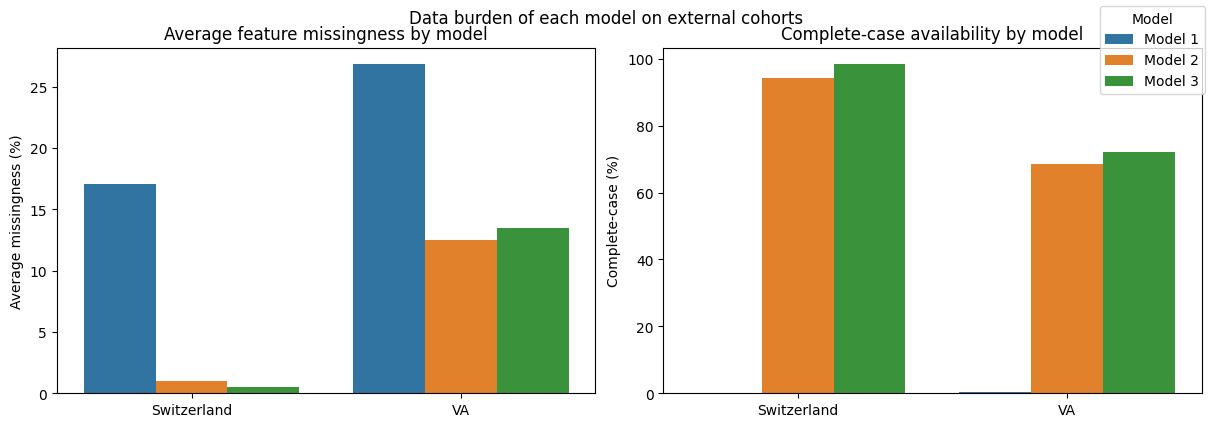

In [155]:
# Visualize missingness burden across models and external datasets

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.barplot(
    data=fallback_missingness_df,
    x="dataset",
    y="avg_feature_missing_pct",
    hue="model",
    ax=axes[0]
)
axes[0].set_title("Average feature missingness by model")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average missingness (%)")

sns.barplot(
    data=fallback_missingness_df,
    x="dataset",
    y="complete_case_pct",
    hue="model",
    ax=axes[1]
)
axes[1].set_title("Complete-case availability by model")
axes[1].set_xlabel("")
axes[1].set_ylabel("Complete-case (%)")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

fig.legend(handles, labels, loc="upper right", title="Model")
plt.suptitle("Data burden of each model on external cohorts", y=1.03)
plt.savefig("uci_plots/model3_data_burden.png", bbox_inches="tight")
plt.show()

In [156]:
# Compare threshold-tuned Models 1, 2, and 3 on the same external datasets

fallback_results = []

for dataset_name, df_raw in fallback_eval_sets.items():
    for model_name, spec in fallback_model_specs.items():
        metrics = evaluate_threshold_tuned_model(
            model=spec["model"],
            df=df_raw,
            feature_list=spec["features"],
            threshold=spec["threshold"]
        )

        metrics.update({
            "dataset": dataset_name,
            "model": model_name,
            "threshold": spec["threshold"],
            "n_features": len(spec["features"])
        })

        fallback_results.append(metrics)

fallback_results_df = pd.DataFrame(fallback_results).sort_values(
    by=["dataset", "roc_auc"],
    ascending=[True, False]
)

display(fallback_results_df)

,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive,tn,fp,fn,tp,n_samples,positive_rate,dataset,model,threshold,n_features
2,0.808696,0.886179,0.706522,0.913043,0.500000,0.963303,4,4,10,105,123,0.934959,Switzerland,Model 3,0.372348,6
1,0.754348,0.658537,0.642935,0.660870,0.625000,0.962025,5,3,39,76,123,0.934959,Switzerland,Model 2,0.470000,9
0,0.748913,0.414634,0.628804,0.382609,0.875000,0.977778,7,1,71,44,123,0.934959,Switzerland,Model 1,0.500000,13
5,0.739110,0.765000,0.616594,0.919463,0.313725,0.796512,16,35,12,137,200,0.745000,VA,Model 3,0.372348,6
4,0.726411,0.730000,0.651138,0.812081,0.490196,0.823129,25,26,28,121,200,0.745000,VA,Model 2,0.470000,9
3,0.682458,0.525000,0.629622,0.416107,0.843137,0.885714,43,8,87,62,200,0.745000,VA,Model 1,0.500000,13


In [157]:
# Compact comparison table for the notebook

fallback_comparison_summary = fallback_results_df[
    [
        "dataset", "model", "n_features", "threshold",
        "roc_auc", "accuracy", "balanced_accuracy",
        "sensitivity", "specificity", "precision_positive"
    ]
].copy()

display(fallback_comparison_summary)

,dataset,model,n_features,threshold,roc_auc,accuracy,balanced_accuracy,sensitivity,specificity,precision_positive
2,Switzerland,Model 3,6,0.372348,0.808696,0.886179,0.706522,0.913043,0.500000,0.963303
1,Switzerland,Model 2,9,0.470000,0.754348,0.658537,0.642935,0.660870,0.625000,0.962025
0,Switzerland,Model 1,13,0.500000,0.748913,0.414634,0.628804,0.382609,0.875000,0.977778
5,VA,Model 3,6,0.372348,0.739110,0.765000,0.616594,0.919463,0.313725,0.796512
4,VA,Model 2,9,0.470000,0.726411,0.730000,0.651138,0.812081,0.490196,0.823129
3,VA,Model 1,13,0.500000,0.682458,0.525000,0.629622,0.416107,0.843137,0.885714


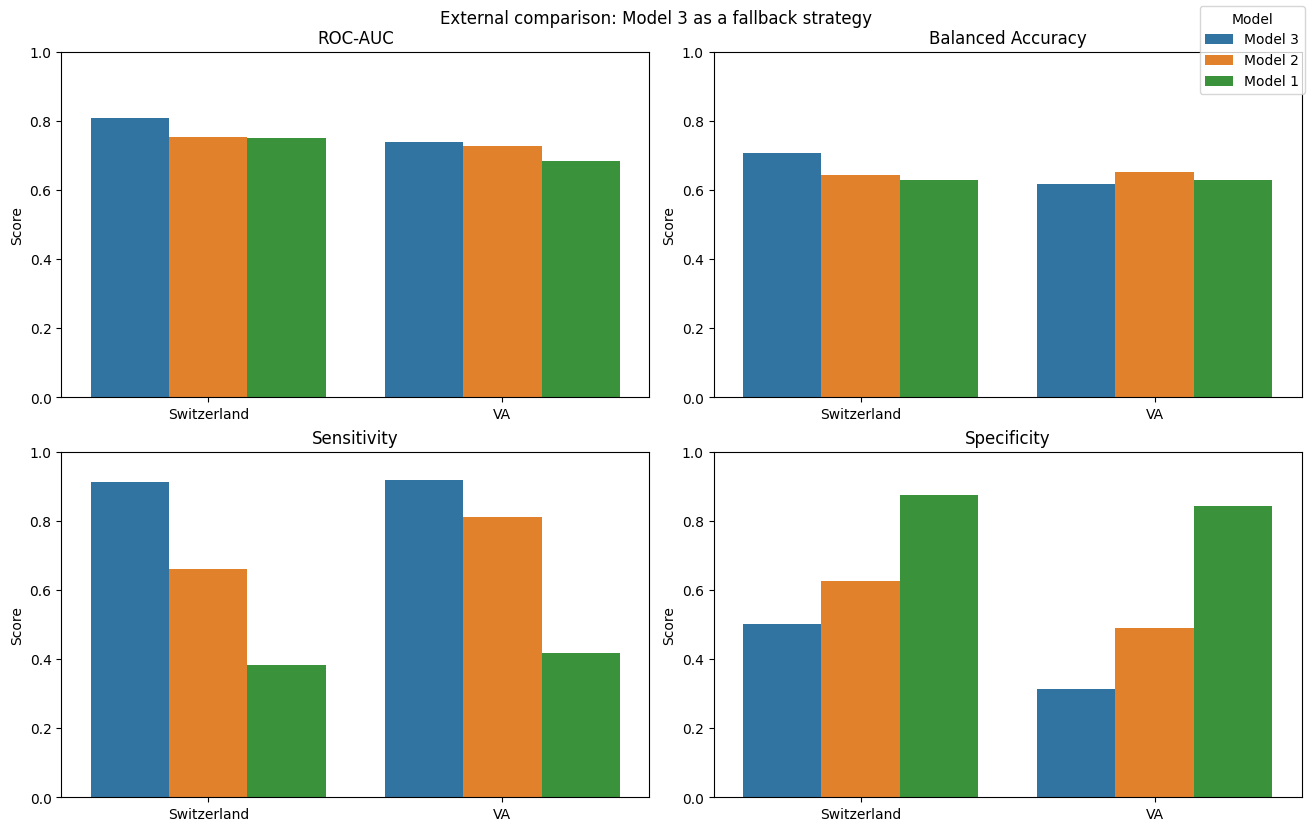

In [158]:
# Visualize fallback comparison across external datasets

metrics_to_plot = ["roc_auc", "balanced_accuracy", "sensitivity", "specificity"]
metric_titles = {
    "roc_auc": "ROC-AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "sensitivity": "Sensitivity",
    "specificity": "Specificity"
}

plot_long = fallback_results_df.melt(
    id_vars=["dataset", "model"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    metric_df = plot_long[plot_long["metric"] == metric]

    sns.barplot(
        data=metric_df,
        x="dataset",
        y="score",
        hue="model",
        ax=ax
    )

    ax.set_title(metric_titles[metric])
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    ax.get_legend().remove()

fig.legend(handles, labels, loc="upper right", title="Model")
plt.suptitle("External comparison: Model 3 as a fallback strategy", y=1.02)
plt.savefig("uci_plots/model3_external_comparison_fallback_strategy.png", bbox_inches="tight")
plt.show()

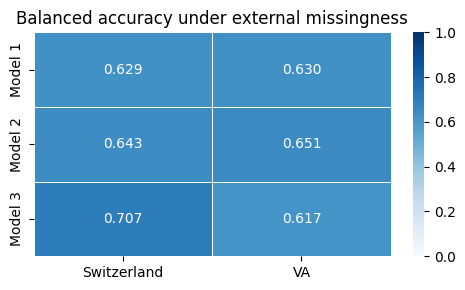

In [159]:
# Heatmap: balanced accuracy by model and external dataset

heatmap_df = fallback_results_df.pivot(
    index="model",
    columns="dataset",
    values="balanced_accuracy"
)

plt.figure(figsize=(5, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Balanced accuracy under external missingness")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_balanced_accuracy_fallback_strategy.png", bbox_inches="tight")
plt.show()

### Model 3 as a fallback strategy — Summary

Model 3 demonstrates a clear advantage in **data availability and robustness under missingness**, while maintaining competitive predictive performance.

The most important structural finding is the **dramatic improvement in usable data**. Model 1 is effectively unusable on external cohorts (≈0–0.5% complete cases), whereas Model 2 recovers a substantial portion (≈68–94%), and Model 3 further improves this to **~72% on VA and ~98% on Switzerland**. This confirms that reducing feature requirements directly translates into significantly higher real-world applicability.

Despite this simplification, Model 3 does not suffer a meaningful loss in ranking performance. **ROC-AUC remains comparable or slightly better than Model 2 across both datasets**, and consistently exceeds Model 1. This indicates that the reduced feature set preserves most of the discriminative signal.

More importantly, Model 3 provides a **better sensitivity–specificity trade-off under realistic conditions**. With threshold tuning focused on high sensitivity:

* Model 3 achieves **substantially higher sensitivity** (≈0.91–0.92 across datasets), clearly outperforming both Model 1 and Model 2.
* This comes at the expected cost of **lower specificity**, but the trade-off is controlled and consistent with the intended clinical objective (minimizing false negatives).

In terms of balanced accuracy, Model 3:

* **Outperforms both models on Switzerland**, where missingness is low and signal is cleaner.
* Remains **competitive on VA**, slightly below Model 2 but still above or comparable to Model 1, despite harsher data conditions.

Overall, these results validate Model 3 as a **practical and reliable fallback strategy**:

* It maximizes coverage under missing data,
* Preserves most of the predictive signal,
* And aligns better with high-sensitivity deployment scenarios.

This makes it particularly suitable for settings where **data completeness cannot be guaranteed**, and where **robust, accessible prediction is preferred over maximal model complexity**.

---

## Model 3 interpretation

In [160]:
# Extract transformed feature names and coefficients from the fitted Model 3 pipeline

m3_preprocessor = final_model3.named_steps["preprocessor"]
m3_classifier = final_model3.named_steps["classifier"]

m3_feature_names = m3_preprocessor.get_feature_names_out()
m3_coefficients = m3_classifier.coef_[0]

model3_coef_df = pd.DataFrame({
    "feature": m3_feature_names,
    "coefficient": m3_coefficients,
    "abs_coefficient": np.abs(m3_coefficients),
    "odds_ratio": np.exp(m3_coefficients)
}).sort_values("abs_coefficient", ascending=False)

display(model3_coef_df)

,feature,coefficient,abs_coefficient,odds_ratio
8,cat__cp_4.0,0.967392,0.967392,2.631074
6,cat__cp_2.0,-0.700844,0.700844,0.496166
10,cat__exang_1.0,0.614365,0.614365,1.848482
9,cat__exang_0.0,-0.614308,0.614308,0.541015
4,cat__sex_1.0,0.511641,0.511641,1.668026
3,cat__sex_0.0,-0.511584,0.511584,0.599545
7,cat__cp_3.0,-0.314237,0.314237,0.730346
0,num__age,0.290026,0.290026,1.336462
2,num__thalach,-0.268585,0.268585,0.764461
1,num__trestbps,0.155438,0.155438,1.168169


In [161]:
# Clean transformed feature names for display

def clean_model3_feature_name(name: str) -> str:
    name = name.replace("num__", "").replace("cat__", "")
    
    replacements = {
        "sex_0.0": "sex = female",
        "sex_1.0": "sex = male",
        "sex_0": "sex = female",
        "sex_1": "sex = male",
        "exang_0.0": "exang = no",
        "exang_1.0": "exang = yes",
        "exang_0": "exang = no",
        "exang_1": "exang = yes",
        "cp_1.0": "cp = typical angina",
        "cp_2.0": "cp = atypical angina",
        "cp_3.0": "cp = non-anginal pain",
        "cp_4.0": "cp = asymptomatic",
        "cp_1": "cp = typical angina",
        "cp_2": "cp = atypical angina",
        "cp_3": "cp = non-anginal pain",
        "cp_4": "cp = asymptomatic",
    }
    
    return replacements.get(name, name)

model3_coef_df["feature_clean"] = model3_coef_df["feature"].apply(clean_model3_feature_name)

display(
    model3_coef_df[
        ["feature_clean", "coefficient", "odds_ratio", "abs_coefficient"]
    ].round(4)
)

,feature_clean,coefficient,odds_ratio,abs_coefficient
8,cp = asymptomatic,0.9674,2.6311,0.9674
6,cp = atypical angina,-0.7008,0.4962,0.7008
10,exang = yes,0.6144,1.8485,0.6144
9,exang = no,-0.6143,0.5410,0.6143
4,sex = male,0.5116,1.6680,0.5116
3,sex = female,-0.5116,0.5995,0.5116
7,cp = non-anginal pain,-0.3142,0.7303,0.3142
0,age,0.2900,1.3365,0.2900
2,thalach,-0.2686,0.7645,0.2686
1,trestbps,0.1554,1.1682,0.1554


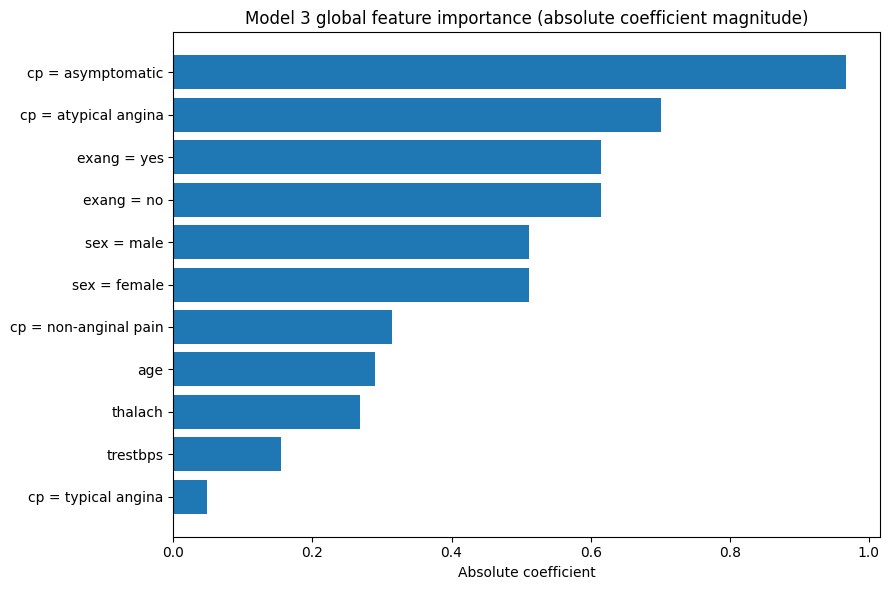

In [162]:
# Plot global feature importance by absolute coefficient magnitude

plot_df = model3_coef_df.sort_values("abs_coefficient", ascending=True).copy()

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature_clean"], plot_df["abs_coefficient"])
plt.title("Model 3 global feature importance (absolute coefficient magnitude)")
plt.xlabel("Absolute coefficient")
plt.ylabel("")
plt.tight_layout()
plt.savefig("uci_plots/model3_global_feature_importance.png", bbox_inches="tight")
plt.show()

In [163]:
# Separate positive and negative coefficients for interpretation

positive_effects_m3 = model3_coef_df[model3_coef_df["coefficient"] > 0].copy()
negative_effects_m3 = model3_coef_df[model3_coef_df["coefficient"] < 0].copy()

print("Top positive effects (increase predicted CHD risk):")
display(
    positive_effects_m3[
        ["feature_clean", "coefficient", "odds_ratio"]
    ].sort_values("coefficient", ascending=False).round(4)
)

print("Top negative effects (decrease predicted CHD risk):")
display(
    negative_effects_m3[
        ["feature_clean", "coefficient", "odds_ratio"]
    ].sort_values("coefficient", ascending=True).round(4)
)

Top positive effects (increase predicted CHD risk):


,feature_clean,coefficient,odds_ratio
8,cp = asymptomatic,0.9674,2.6311
10,exang = yes,0.6144,1.8485
4,sex = male,0.5116,1.6680
0,age,0.2900,1.3365
1,trestbps,0.1554,1.1682
5,cp = typical angina,0.0477,1.0489


Top negative effects (decrease predicted CHD risk):


,feature_clean,coefficient,odds_ratio
6,cp = atypical angina,-0.7008,0.4962
9,exang = no,-0.6143,0.5410
3,sex = female,-0.5116,0.5995
7,cp = non-anginal pain,-0.3142,0.7303
2,thalach,-0.2686,0.7645


,feature_family,abs_coefficient
1,cp,2.030219
2,exang,1.228673
3,sex,1.023225
0,age,0.290026
4,thalach,0.268585
5,trestbps,0.155438


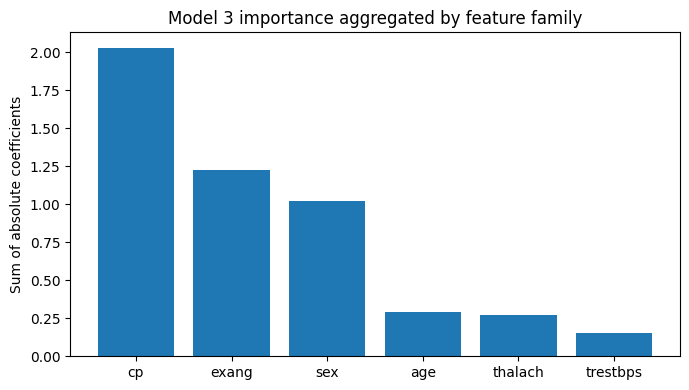

In [164]:
# Summarize coefficient strength by original feature family

def feature_family(clean_name: str) -> str:
    if clean_name.startswith("cp"):
        return "cp"
    if clean_name.startswith("sex"):
        return "sex"
    if clean_name.startswith("exang"):
        return "exang"
    if clean_name.startswith("age"):
        return "age"
    if clean_name.startswith("trestbps"):
        return "trestbps"
    if clean_name.startswith("thalach"):
        return "thalach"
    return "other"

family_summary_m3 = model3_coef_df.copy()
family_summary_m3["feature_family"] = family_summary_m3["feature_clean"].apply(feature_family)

family_importance_m3 = (
    family_summary_m3.groupby("feature_family", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=False)
)

display(family_importance_m3)

plt.figure(figsize=(7, 4))
plt.bar(family_importance_m3["feature_family"], family_importance_m3["abs_coefficient"])
plt.title("Model 3 importance aggregated by feature family")
plt.xlabel("")
plt.ylabel("Sum of absolute coefficients")
plt.tight_layout()
plt.savefig("uci_plots/model3_importance_aggregated_by_feature_family.png", bbox_inches="tight")
plt.show()

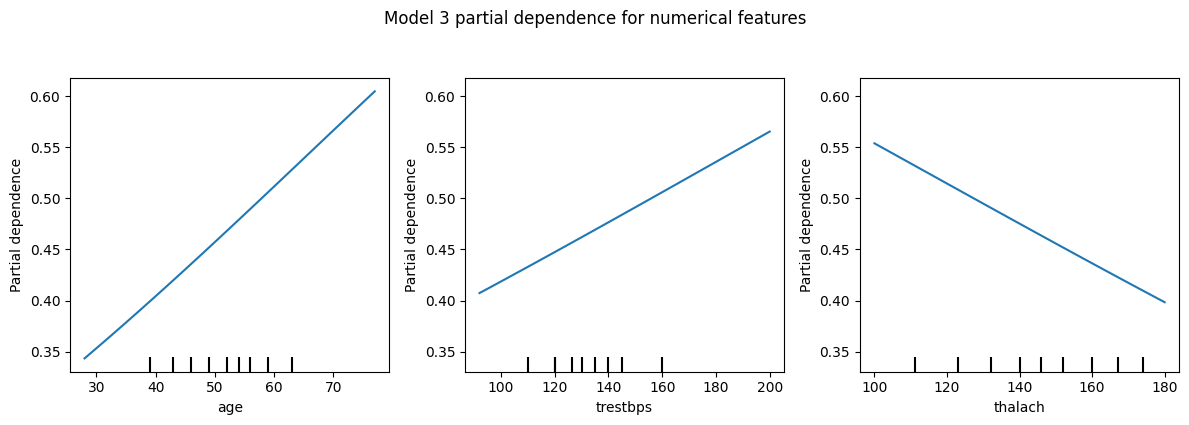

In [165]:
# Partial dependence plots for numerical features

numeric_features_m3 = ["age", "trestbps", "thalach"]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

PartialDependenceDisplay.from_estimator(
    final_model3,
    X_train_m3,
    features=numeric_features_m3,
    kind="average",
    ax=ax
)

plt.suptitle("Model 3 partial dependence for numerical features", y=1.05)
plt.tight_layout()
plt.savefig("uci_plots/model3_partial_dependence_for_numerical_features.png", bbox_inches="tight")
plt.show()

In [166]:
# Build a combined evaluation set for local explanation examples

interpretation_eval_df = pd.concat(
    [
        cleveland_m3.assign(dataset="Cleveland"),
        hungarian_m3.assign(dataset="Hungarian"),
        switzerland_m3.assign(dataset="Switzerland"),
        va_m3.assign(dataset="VA")
    ],
    axis=0,
    ignore_index=True
)

X_interp = interpretation_eval_df[model3_features]
y_interp = interpretation_eval_df[target]

interp_proba = final_model3.predict_proba(X_interp)[:, 1]
interp_pred = (interp_proba >= selected_threshold_m3).astype(int)

interpretation_eval_df = interpretation_eval_df.copy()
interpretation_eval_df["pred_proba"] = interp_proba
interpretation_eval_df["pred_label"] = interp_pred

interpretation_eval_df["case_type"] = np.select(
    [
        (interpretation_eval_df[target] == 1) & (interpretation_eval_df["pred_label"] == 1),
        (interpretation_eval_df[target] == 0) & (interpretation_eval_df["pred_label"] == 1),
        (interpretation_eval_df[target] == 1) & (interpretation_eval_df["pred_label"] == 0),
        (interpretation_eval_df[target] == 0) & (interpretation_eval_df["pred_label"] == 0),
    ],
    [
        "true_positive",
        "false_positive",
        "false_negative",
        "true_negative"
    ],
    default="other"
)

interpretation_eval_df["distance_to_threshold"] = np.abs(
    interpretation_eval_df["pred_proba"] - selected_threshold_m3
)

interpretation_eval_df["row_id"] = interpretation_eval_df.index

interpretation_eval_df[
    ["dataset", target, "pred_label", "pred_proba", "case_type", "distance_to_threshold"]
].head()

,dataset,target,pred_label,pred_proba,case_type,distance_to_threshold
0,Cleveland,0,1,0.512513,false_positive,0.140165
1,Cleveland,1,1,0.949496,true_positive,0.577148
2,Cleveland,1,1,0.912349,true_positive,0.540001
3,Cleveland,0,0,0.155169,true_negative,0.217179
4,Cleveland,0,0,0.056952,true_negative,0.315395


In [167]:
# Pick representative local explanation cases

representative_cases = {}

for case_name in ["true_positive", "false_positive", "false_negative"]:
    subset = interpretation_eval_df[interpretation_eval_df["case_type"] == case_name].copy()
    
    if len(subset) > 0:
        # choose a case close to the threshold for more informative explanation
        chosen = subset.sort_values("distance_to_threshold").iloc[0]
        representative_cases[case_name] = int(chosen["row_id"])

representative_cases

{'true_positive': 531, 'false_positive': 416, 'false_negative': 915}

In [168]:
# Local explanation helper for logistic regression pipeline

def explain_model3_case(row_index, model, X_original, threshold, feature_names_clean):
    preprocessor = model.named_steps["preprocessor"]
    classifier = model.named_steps["classifier"]
    
    x_row = X_original.iloc[[row_index]]
    x_trans = preprocessor.transform(x_row)
    
    # convert sparse to dense if needed
    if hasattr(x_trans, "toarray"):
        x_trans = x_trans.toarray()
    
    coefs = classifier.coef_[0]
    intercept = classifier.intercept_[0]
    contributions = x_trans[0] * coefs
    
    logit = intercept + contributions.sum()
    prob = 1 / (1 + np.exp(-logit))
    pred = int(prob >= threshold)
    
    explanation_df = pd.DataFrame({
        "feature": feature_names_clean,
        "contribution": contributions,
        "abs_contribution": np.abs(contributions)
    }).sort_values("abs_contribution", ascending=False)
    
    return {
        "x_row": x_row,
        "probability": prob,
        "prediction": pred,
        "logit": logit,
        "intercept": intercept,
        "explanation_df": explanation_df
    }

feature_names_clean_m3 = model3_coef_df["feature_clean"].tolist()

In [169]:
# Inspect representative local explanations

for case_name, row_idx in representative_cases.items():
    result = explain_model3_case(
        row_index=row_idx,
        model=final_model3,
        X_original=X_interp,
        threshold=selected_threshold_m3,
        feature_names_clean=feature_names_clean_m3
    )
    
    meta = interpretation_eval_df.loc[row_idx, ["dataset", target, "pred_label", "pred_proba", "case_type"]]
    
    print(f"\n{'='*80}")
    print(case_name.replace("_", " ").title())
    print(f"{'='*80}")
    print(meta)
    print("\nOriginal feature values:")
    display(X_interp.iloc[[row_idx]])
    
    print(f"Predicted probability: {result['probability']:.4f}")
    print(f"Predicted label at threshold {selected_threshold_m3:.3f}: {result['prediction']}")
    print("\nTop contributing features:")
    display(result["explanation_df"][["feature", "contribution"]].head(10).round(4))


True Positive
dataset           Hungarian
target                    1
pred_label                1
pred_proba         0.373114
case_type     true_positive
Name: 531, dtype: object

Original feature values:


,age,sex,cp,exang,trestbps,thalach
531,40.0,0.0,4.0,0.0,150.0,130.0


Predicted probability: 0.3731
Predicted label at threshold 0.372: 1

Top contributing features:


,feature,contribution
8,thalach,0.9674
9,trestbps,-0.6143
3,exang = no,-0.5116
0,cp = asymptomatic,-0.3577
2,exang = yes,0.1635
1,cp = atypical angina,0.1581
4,sex = male,0.0000
5,sex = female,0.0000
6,cp = non-anginal pain,-0.0000
7,age,-0.0000



False Positive
dataset            Hungarian
target                     0
pred_label                 1
pred_proba          0.375468
case_type     false_positive
Name: 416, dtype: object

Original feature values:


,age,sex,cp,exang,trestbps,thalach
416,50.0,1.0,2.0,0.0,170.0,116.0


Predicted probability: 0.3755
Predicted label at threshold 0.372: 1

Top contributing features:


,feature,contribution
6,cp = non-anginal pain,-0.7008
9,trestbps,-0.6143
4,sex = male,0.5116
1,cp = atypical angina,0.3350
2,exang = yes,0.3218
0,cp = asymptomatic,-0.0378
3,exang = no,-0.0000
5,sex = female,0.0000
7,age,-0.0000
8,thalach,0.0000



False Negative
dataset                   VA
target                     1
pred_label                 0
pred_proba          0.366831
case_type     false_negative
Name: 915, dtype: object

Original feature values:


,age,sex,cp,exang,trestbps,thalach
915,54.0,0.0,4.0,0.0,127.0,154.0


Predicted probability: 0.3668
Predicted label at threshold 0.372: 0

Top contributing features:


,feature,contribution
8,thalach,0.9674
9,trestbps,-0.6143
3,exang = no,-0.5116
2,exang = yes,-0.1079
0,cp = asymptomatic,0.0901
1,cp = atypical angina,-0.0453
4,sex = male,0.0000
5,sex = female,0.0000
6,cp = non-anginal pain,-0.0000
7,age,-0.0000


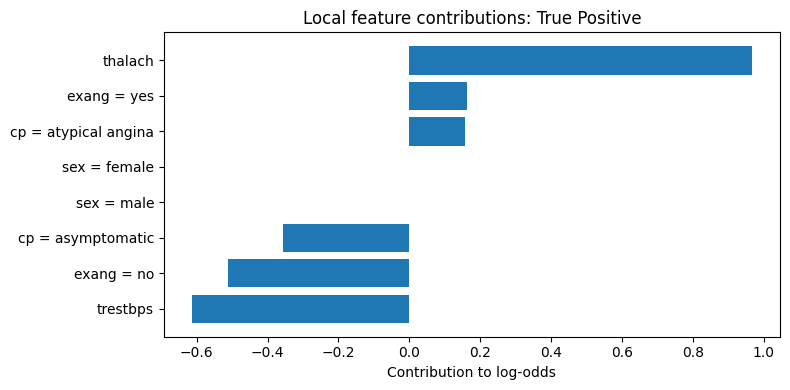

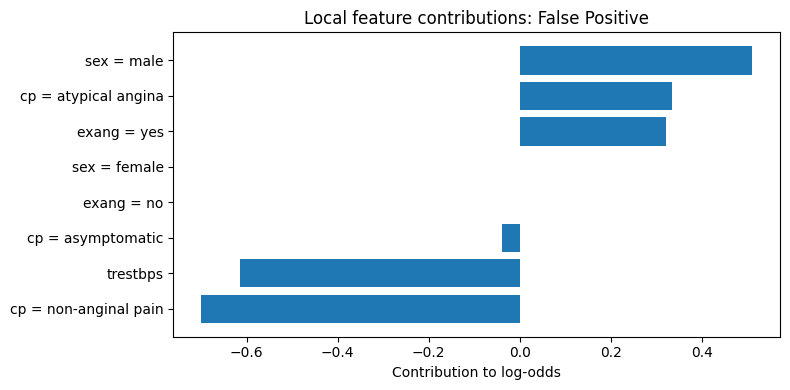

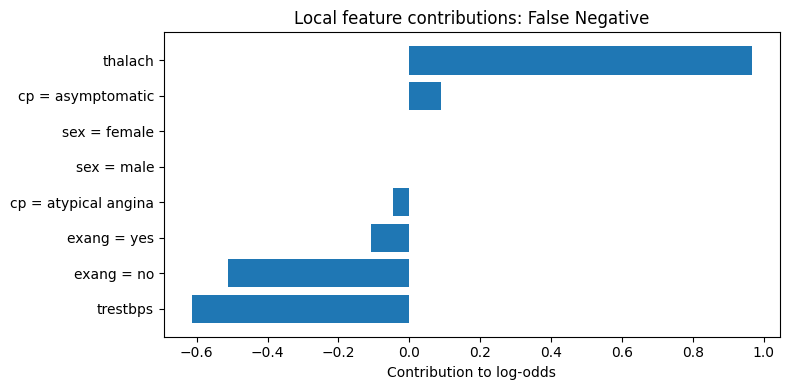

In [170]:
# Visualize top local contributions for each representative case

for case_name, row_idx in representative_cases.items():
    result = explain_model3_case(
        row_index=row_idx,
        model=final_model3,
        X_original=X_interp,
        threshold=selected_threshold_m3,
        feature_names_clean=feature_names_clean_m3
    )
    
    plot_df = result["explanation_df"].head(8).sort_values("contribution")
    
    plt.figure(figsize=(8, 4))
    plt.barh(plot_df["feature"], plot_df["contribution"])
    plt.title(f"Local feature contributions: {case_name.replace('_', ' ').title()}")
    plt.xlabel("Contribution to log-odds")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

Model 3 behaves in a clinically plausible and internally coherent way. The strongest drivers of prediction are **chest pain type**, especially **asymptomatic chest pain**, followed by **exercise-induced angina** and **sex**, while the numerical variables play a smaller but still consistent role. Among continuous features, **age** and **resting blood pressure** increase predicted risk, whereas **maximum heart rate (`thalach`)** decreases it. The partial dependence plots confirm these monotonic relationships and show no obvious pathological behavior.

Aggregating coefficients by feature family further shows that most of the predictive signal comes from the **symptom-related variables** (`cp`, `exang`), with demographic information contributing secondarily and physiological measurements adding more modest refinement. This is fully consistent with the earlier EDA and with the intended design of Model 3 as a simple, symptom-aware screening model.

The local explanations also help clarify how the model makes decisions near the operating threshold. In the representative **true positive**, a combination of lower `thalach`, higher `trestbps`, and symptom pattern pushed the case just above the decision boundary. The **false positive** illustrates the main downside of the sensitivity-first threshold: some cases are classified as positive because moderate-risk signals accumulate even in the absence of true disease. The **false negative** shows the opposite pattern, where strong protective contributions—particularly from physiological variables—can outweigh weaker positive signals and keep a truly positive case just below threshold.

Overall, the interpretation results reinforce that Model 3 is not acting as a black box. Its predictions are dominated by clinically meaningful variables, its global relationships are stable and monotonic, and its mistakes are understandable in terms of the deliberate high-sensitivity operating point rather than arbitrary model behavior.

---

## Export model 3

In this section, we save Model 3 using the same export structure as Model 1 and Model 2.

As before, we save three files:

- the `.joblib` file contains the runtime artifact needed for prediction;
- the `.metadata.json` file contains model documentation, validation details, threshold-selection information, performance summaries, interpretation summaries, and limitations;
- the `.schema.json` file defines the expected input fields and valid values for API validation.

In [171]:
# ============================================================
# Save Model 3 artifact + metadata
# ============================================================

# Model 3 schema

model3_schema = {
    "schema_version": "1.0.0",
    "description": (
        "Input schema for Model 3, the minimal-input current heart disease "
        "screening-support model."
    ),
    "features": {
        "age": {
            "type": "number",
            "required": True,
            "minimum": 18,
            "maximum": 100,
            "unit": "years",
            "description": "Age in years."
        },
        "trestbps": {
            "type": "number",
            "required": True,
            "minimum": 70,
            "maximum": 250,
            "unit": "mm Hg",
            "description": "Resting blood pressure."
        },
        "thalach": {
            "type": "number",
            "required": True,
            "minimum": 60,
            "maximum": 230,
            "description": "Maximum heart rate achieved."
        },
        "sex": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "female",
                "1": "male"
            },
            "description": "Biological sex as encoded in the UCI dataset."
        },
        "cp": {
            "type": "integer",
            "required": True,
            "allowed_values": [1, 2, 3, 4],
            "value_mapping": {
                "1": "typical angina",
                "2": "atypical angina",
                "3": "non-anginal pain",
                "4": "asymptomatic"
            },
            "description": "Chest pain type."
        },
        "exang": {
            "type": "integer",
            "required": True,
            "allowed_values": [0, 1],
            "value_mapping": {
                "0": "no exercise-induced angina",
                "1": "exercise-induced angina"
            },
            "description": "Exercise-induced angina."
        }
    },
    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },
    "notes": [
        "This model uses the smallest input feature set among the three models.",
        "It is intended as the primary candidate for a lightweight screening API.",
        "Its selected threshold prioritizes sensitivity for screening support.",
        "This model predicts current heart disease pattern, not 10-year CHD risk."
    ]
}

In [172]:
# Model 3 metadata

# Select threshold row closest to the chosen Model 3 threshold
selected_threshold_row_m3 = threshold_candidates_m3.iloc[
    (threshold_candidates_m3["threshold"] - selected_threshold_m3)
    .abs()
    .argsort()[:1]
].iloc[0]


model3_metadata = {
    "algorithm": "LogisticRegression",

    "intended_use": (
        "Minimal-input current heart disease screening-support model intended "
        "for lightweight API use when only a small set of common clinical and "
        "exercise-related inputs are available."
    ),

    "not_for": [
        "10-year CHD risk estimation",
        "standalone clinical diagnosis",
        "emergency decision-making"
    ],

    "training_datasets": ["Cleveland", "Hungarian"],
    "external_validation_datasets": ["Switzerland", "VA"],

    "data_constraints": {
        "excluded_from_training": {
            "Switzerland": (
                "Used only for external validation because of distribution shift "
                "and high positive prevalence."
            ),
            "VA": (
                "Excluded from training because of high missingness and stronger "
                "distribution shift; used as a robustness stress test."
            )
        }
    },

    "validation_strategy": {
        "summary": (
            "GroupKFold leave-one-dataset-out validation on Cleveland and Hungarian, "
            "with external evaluation on Switzerland and VA."
        ),
        "threshold_selection_dataset": "Out-of-fold training predictions from Cleveland and Hungarian.",
        "threshold_selection_policy": "Maximize specificity under a sensitivity constraint.",
        "target_sensitivity": 0.85
    },

    "features": {
        "all": list(model3_features),
        "numerical": ["age", "trestbps", "thalach"],
        "categorical": ["sex", "cp", "exang"]
    },

    "target": {
        "name": "num",
        "definition": "target = 1 if num > 0 else 0",
        "positive_class": 1
    },

    "selected_hyperparameters": {
        "C": 0.1,
        "class_weight": "balanced",
        "solver": "lbfgs",
        "max_iter": 1000
    },

    "thresholding": {
        "default_threshold": 0.5,
        "selected_threshold": float(selected_threshold_m3),
        "threshold_selection_method": "Maximize specificity under sensitivity constraint.",
        "threshold_selection_dataset": "OOF training predictions from Cleveland and Hungarian.",
        "target_sensitivity": 0.85,
        "metrics_at_selected_threshold": {
            "sensitivity": float(selected_threshold_row_m3["sensitivity"]),
            "specificity": float(selected_threshold_row_m3["specificity"]),
            "balanced_accuracy": float(selected_threshold_row_m3["balanced_accuracy"]),
            "fpr": float(selected_threshold_row_m3["fpr"])
        },
        "note": "Threshold selected to prioritize sensitivity for screening use case."
    },

    "performance": {
        "baseline_internal_results": holdout_results_m3_df.to_dict(orient="records"),
        "baseline_external_results": external_results_m3_df.to_dict(orient="records"),
        "threshold_tuned_results": threshold_tuned_results_m3_df.to_dict(orient="records")
    },

    "fallback_strategy_summary": fallback_results_df.to_dict(orient="records"),

    "interpretation_summary": {
        "top_features_by_absolute_coefficient": (
            model3_coef_df[
                ["feature_clean", "coefficient", "odds_ratio", "abs_coefficient"]
            ]
            .sort_values("abs_coefficient", ascending=False)
            .head(10)
            .to_dict(orient="records")
        ),
        "feature_family_importance": family_importance_m3.to_dict(orient="records")
    },

    "limitations": [
        "This model uses fewer features than Model 1 and Model 2, so it may miss patterns captured by richer clinical variables.",
        "The threshold is intentionally sensitivity-oriented, which can increase false positives.",
        "External validation performance varies across Switzerland and VA, indicating dataset shift.",
        "The model predicts current heart disease pattern, not future CHD risk.",
        "The predicted score should not be interpreted as a calibrated real-world diagnostic probability without further validation."
    ]
}

In [173]:
# Export Model 3

MODEL3_ID = "model3_minimal_screening_v1"

MODEL3_DISPLAY_NAME = "Model 3 - Minimal Input Screening Logistic Regression"

MODEL3_ROLE = "minimal-input current heart disease screening-support model"

MODEL3_THRESHOLD = float(selected_threshold_m3)

MODEL3_THRESHOLD_POLICY = "Selected to prioritize sensitivity for screening use case."

MODEL3_FEATURE_ORDER = list(model3_features)

MODEL3_NUMERICAL_FEATURES = ["age", "trestbps", "thalach"]

MODEL3_CATEGORICAL_FEATURES = ["sex", "cp", "exang"]


model3_export_paths = export_model_artifacts(
    model_id=MODEL3_ID,
    model_display_name=MODEL3_DISPLAY_NAME,
    model_role=MODEL3_ROLE,
    pipeline=final_model3,
    threshold=MODEL3_THRESHOLD,
    threshold_policy=MODEL3_THRESHOLD_POLICY,
    feature_order=MODEL3_FEATURE_ORDER,
    numerical_features=MODEL3_NUMERICAL_FEATURES,
    categorical_features=MODEL3_CATEGORICAL_FEATURES,
    metadata=model3_metadata,
    schema=model3_schema,
    artifact_dir="artifacts",
    artifact_version="1.0.0",
)

model3_export_paths

{'artifact_path': 'artifacts/model3_minimal_screening_v1.joblib',
 'metadata_path': 'artifacts/model3_minimal_screening_v1.metadata.json',
 'schema_path': 'artifacts/model3_minimal_screening_v1.schema.json'}

In [174]:
# Verification step

# Load standardized Model 3 artifact
loaded_artifact = joblib.load("artifacts/model3_minimal_screening_v1.joblib")

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]
loaded_feature_order = loaded_artifact["feature_order"]

# Verify feature order using Model 3 training data, as in the original notebook
X_verify = X_train_m3[loaded_feature_order].iloc[:5]

sample_proba = loaded_pipeline.predict_proba(X_verify)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

print("Model ID:", loaded_artifact["model_id"])
print("Display name:", loaded_artifact["model_display_name"])
print("Threshold:", loaded_threshold)
print("Feature order matches input:", list(X_verify.columns) == loaded_feature_order)
print("Probabilities:", sample_proba)
print("Predictions:", sample_pred)

Model ID: model3_minimal_screening_v1
Display name: Model 3 - Minimal Input Screening Logistic Regression
Threshold: 0.3723476801777547
Feature order matches input: True
Probabilities: [0.51251255 0.94949603 0.91234898 0.15516904 0.05695241]
Predictions: [1 1 1 0 0]


# Conclusion

### Project Overview

This project develops an end-to-end framework for heart disease prediction, addressing two related but fundamentally different problems: long-term risk estimation and current disease detection. The first component focuses on predicting 10-year risk of coronary heart disease using longitudinal data, while the second addresses the classification of existing heart disease using cross-sectional clinical datasets. Together, these components form a complementary system intended for decision support rather than standalone diagnosis.

### Problem Framing and Intended Use

The two modeling tasks serve distinct purposes and are designed for different stages of clinical decision-making.

The 10-year risk model is intended for **preventive screening and risk stratification**, particularly in primary care or population-level settings. Its role is to identify individuals at elevated risk who may benefit from further monitoring or intervention. The model’s outputs are most appropriately interpreted as relative risk indicators, supporting prioritization rather than definitive clinical conclusions.

The diagnostic models are designed for **current disease likelihood estimation and triage support**. They are intended for use in settings where some clinical information is already available, helping to assess the probability of existing heart disease. These models are not substitutes for diagnostic procedures but can support early decision-making and guide further testing.

### Data and Modeling Approach

The project combines two distinct types of data. The Framingham dataset provides longitudinal observations suitable for future risk prediction, while the UCI heart disease datasets offer cross-sectional data from multiple clinical sources for diagnostic modeling.

Across both tasks, the modeling approach emphasizes **simplicity, interpretability, and robustness**. Rather than prioritizing complex models, the focus is on selecting methods that generalize well, remain stable across validation schemes, and can be meaningfully interpreted. In practice, this leads to repeated selection of logistic regression as the final model when it performs competitively with more complex alternatives.

### Model Design and System Structure

The final system consists of two components.

For long-term risk prediction, a single logistic regression model is selected based on its stable performance and interpretability. It provides a consistent and transparent mechanism for estimating relative risk over a 10-year horizon.

For diagnostic prediction, a **tiered modeling strategy** is implemented to account for variability in feature availability:

* A full-feature model (Model 1) is used when complete clinical information is available and provides the highest performance.
* A reduced-feature model (Model 2) serves as a fallback when some inputs are missing.
* A minimal-input model (Model 3) is designed for broader applicability and robustness, maintaining reasonable performance even under constrained input conditions.

This structure reflects a practical deployment scenario, where data completeness cannot be assumed and model selection must adapt accordingly.

### Evaluation Strategy

Model evaluation is conducted using a combination of cross-validation, holdout testing, and, for the diagnostic models, external validation across multiple datasets. This approach allows assessment of both internal consistency and robustness to dataset variation.

Multiple evaluation metrics are used to capture different aspects of performance:

* ROC-AUC for overall discrimination
* PR-AUC for performance under class imbalance
* Balanced accuracy for classification balance
* Brier score for probability quality

A key distinction throughout the evaluation is between **discrimination** (the ability to rank cases correctly) and **calibration** (the accuracy of predicted probabilities). The models generally demonstrate stronger discrimination than calibration, which has implications for how their outputs should be interpreted.

### Key Findings

For the 10-year risk prediction task, the final model achieves moderate discrimination. Its primary strength lies in **risk stratification**, effectively distinguishing higher-risk from lower-risk individuals, while absolute probability estimates are less reliable.

For diagnostic prediction, the full-feature model achieves strong performance on internal data, while reduced and minimal models maintain useful performance across varying conditions. Importantly, dedicated reduced models outperform approaches that rely on imputing missing features into more complex models, highlighting the value of explicitly designing for incomplete data.

External validation across multiple UCI datasets shows some performance degradation, as expected under dataset shift, but overall utility is preserved. This suggests a degree of robustness, though not full transportability.

### Thresholding and Decision Behavior

Model outputs are continuous probabilities, but practical use requires threshold-based decisions. The project explicitly explores the trade-offs between sensitivity and specificity, showing how different thresholds correspond to different operational goals.

In screening contexts, higher sensitivity (recall) may be prioritized to minimize missed cases, while in more selective contexts, higher precision may be preferred. Thresholds are therefore not fixed but should be adapted to the specific use case and risk tolerance.

### Calibration and Interpretation

While calibration techniques are explored, the results indicate that the models are generally more reliable for **ranking risk** than for providing precise probability estimates. Calibration can improve probability alignment in some cases but may introduce trade-offs in classification performance.

As a result, model outputs should be interpreted as **relative indicators of likelihood** rather than exact clinical probabilities. This is particularly important when applying the models across different populations or settings.

### Generalization and Limitations

The project explicitly considers variability across datasets, especially in the diagnostic task where multiple cohorts are used. Differences in feature distributions, prevalence, and data quality introduce challenges for generalization.

Although external validation provides evidence of robustness, it does not guarantee consistent performance across all settings. Additional limitations include dataset size, potential sampling bias, and reliance on the availability and quality of input features.

These factors mean that the models should be applied with caution, particularly outside the contexts represented in the training data.

### Practical Considerations

For deployment, several considerations are critical:

* Model selection should depend on available inputs, following the tiered structure of the diagnostic system.
* Preprocessing must be applied consistently with the training pipeline.
* Thresholds should be chosen based on the intended use case rather than fixed arbitrarily.
* Outputs should be accompanied by appropriate interpretation guidance, emphasizing their role in decision support.

### Final Summary

This project demonstrates that meaningful heart disease prediction can be achieved using relatively simple and interpretable models, provided that sufficient attention is given to problem framing, evaluation, and practical constraints.

The two components—long-term risk prediction and current diagnostic support—serve complementary roles within a broader decision-support framework. The results highlight the importance of robustness, adaptability to incomplete data, and careful interpretation of model outputs.

Overall, the system is best understood as a **support tool for risk assessment and triage**, rather than a definitive diagnostic solution.
